# Taller — Predicción de Accidentalidad por Barrio y Hora
**Aprendizaje Automático · MCDA 2026-1**  
**Profesores:** Pablo Saldarriaga

**Estudiante:** Andrés Velasco   

---

Las administraciones municipales enfrentan un reto permanente: anticipar dónde y cuándo
es más probable que ocurra un accidente de tránsito, con el fin de focalizar operativos,
desplegar agentes preventivos y diseñar campañas de seguridad vial más efectivas.

Este taller aborda ese reto como un problema de **clasificación binaria supervisada**:
dado un barrio B y una hora h del día, ¿ocurrirá al menos un accidente?

El problema tiene dos características que lo hacen no trivial. Primero, el **desbalance
de clases**: la gran mayoría de las combinaciones (barrio, hora) no registran accidentes,
y un modelo ingenuo que prediga siempre "no accidente" alcanzaría una accuracy altísima
pero sería completamente inútil. Segundo, la **estructura temporal de los datos**: toda
variable histórica debe construirse únicamente con información disponible antes del
momento de predicción, para evitar fuga de información (*data leakage*).

La base de datos está en formato SQLite y contiene tres tablas: `raw_accidentes` con el
registro detallado de cada accidente, `accidentes` con la versión agregada por barrio y
hora, y `clima` con mediciones meteorológicas que cubren **todas** las combinaciones
(barrio, hora) del período — incluyendo las que no tuvieron accidente, lo que la
convierte en la base para construir los casos negativos del modelo.

El desarrollo sigue el flujo completo de un proyecto de Machine Learning: exploración y
calidad de datos, ingeniería de características, modelado con manejo explícito del
desbalance, validación temporal y selección del modelo final con criterio de negocio.

*Todos los resultados son reproducibles. La semilla global es `RANDOM_STATE = 42`.*

## Estructura del notebook

El desarrollo sigue el flujo completo de un proyecto de Machine Learning supervisado,
organizado en las siguientes secciones:

| Sección | Contenido |
|---|---|
| **0. Setup** | Imports, versiones, semilla global, conexión a la base de datos |
| **1. Carga de datos** | Lectura de las tres tablas vía SQL, inspección inicial |
| **2. Análisis exploratorio (EDA)** | Distribución temporal, espacial y climática; visualizaciones |
| **3. Calidad de datos** | Consistencia entre tablas, nulos, duplicados, outliers |
| **4. Definición del problema supervisado** | Construcción del dataset modelable, variable objetivo, análisis del desbalance |
| **5. Ingeniería de características** | Variables temporales, cíclicas, festivos colombianos, agregados históricos, codificación de categóricas |
| **6. Baseline ingenuo** | Por qué accuracy no es la métrica adecuada en este problema |
| **7. Manejo del desbalance** | Comparación de estrategias: class_weight, SMOTE, undersampling |
| **8. Modelado y validación** | Tres familias de modelos, ajuste de hiperparámetros, validación temporal y cruzada |
| **9. Métricas y selección del modelo final** | ROC-AUC, F1, PR-AUC, matriz de confusión, ajuste de umbral con métrica de negocio |
| **10. Caso de uso y limitaciones** | Propuesta operacional, concept drift, variables externas sugeridas |
| **11. Conclusiones y trabajo futuro** | Síntesis de hallazgos y próximos pasos |


## 0. Setup y configuración

Antes de cualquier análisis, establecemos las condiciones base del entorno: librerías,
configuración visual, semilla global y conexión a los datos. Centralizar todo aquí
tiene un propósito claro — si algo cambia (una ruta, una versión, la semilla), se
modifica en un solo lugar y el resto del notebook no se toca.

In [ ]:
# Instalamos librerías que no vienen por defecto en Colab
# imbalanced-learn: para SMOTE y técnicas de balanceo
# holidays: para detectar festivos colombianos oficiales
# xgboost: para Gradient Boosting

!pip install imbalanced-learn holidays xgboost --quiet

In [ ]:
# ─── Librerías estándar ───────────────────────────────────────────────────────
import sqlite3
import warnings
warnings.filterwarnings('ignore')

# ─── Manipulación de datos ────────────────────────────────────────────────────
import numpy as np
import pandas as pd

# ─── Fechas y festivos ────────────────────────────────────────────────────────
from datetime import datetime
import holidays

# ─── Visualización ───────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# ─── Preprocesamiento ─────────────────────────────────────────────────────────
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline

# ─── Modelos ─────────────────────────────────────────────────────────────────
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier

# ─── Balanceo ────────────────────────────────────────────────────────────────
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline as ImbPipeline

# ─── Validación y métricas ────────────────────────────────────────────────────
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    RandomizedSearchCV,
    cross_validate
)
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score,
    f1_score,
    precision_recall_curve,
    roc_curve,
    ConfusionMatrixDisplay
)

In [ ]:
# Declaramos versiones para garantizar reproducibilidad
# Si alguien corre este notebook en el futuro y obtiene resultados
# diferentes, puede identificar si hubo un cambio de versión

import sklearn
import imblearn
import xgboost

print("Versiones del entorno:")
print(f"  numpy:           {np.__version__}")
print(f"  pandas:          {pd.__version__}")
print(f"  scikit-learn:    {sklearn.__version__}")
print(f"  imbalanced-learn:{imblearn.__version__}")
print(f"  xgboost:         {xgboost.__version__}")
print(f"  Python:          {__import__('sys').version.split()[0]}")

Versiones del entorno:
  numpy:           2.0.2
  pandas:          2.2.2
  scikit-learn:    1.6.1
  imbalanced-learn:0.14.1
  xgboost:         3.2.0
  Python:          3.12.13


In [ ]:
# ─── Semilla global ───────────────────────────────────────────────────────────
# Fijar random_state = 42 en TODOS los modelos y funciones aleatorias
# garantiza que los resultados sean idénticos en cada ejecución
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# ─── Estilo de gráficas ───────────────────────────────────────────────────────
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11

# ─── Opciones de pandas ───────────────────────────────────────────────────────
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.4f}'.format)

print("Configuración global aplicada ✓")
print(f"  RANDOM_STATE = {RANDOM_STATE}")

Configuración global aplicada ✓
  RANDOM_STATE = 42


In [ ]:
import gdown
import os

# ─── Descarga automática de la base de datos ─────────────────────────────────
# El archivo está disponible públicamente en Google Drive.
# Si ya existe en la sesión no se vuelve a descargar.

FILE_ID = "1gohwr4GLZo-KwpY3SmvaJ78AJWrwnTzU"
DB_PATH = "data_accidentes.sqlite3"

if not os.path.exists(DB_PATH):
    print("Descargando base de datos...")
    gdown.download(
        f"https://drive.google.com/uc?id={FILE_ID}",
        DB_PATH,
        quiet=False
    )
    print("Descarga completada ✓")
else:
    print("Base de datos ya disponible ✓")

# ─── Conexión y carga de las tres tablas ─────────────────────────────────────
con = sqlite3.connect(DB_PATH)

accidentes = pd.read_sql(
    'SELECT * FROM accidentes',
    con,
    parse_dates=['TW']
)

clima = pd.read_sql(
    'SELECT * FROM clima',
    con,
    parse_dates=['TW']
)

raw = pd.read_sql(
    'SELECT * FROM raw_accidentes',
    con,
    parse_dates=['TW', 'FECHA']
)

con.close()

print("Tablas cargadas exitosamente ✓")
print(f"  accidentes : {accidentes.shape[0]:,} filas × {accidentes.shape[1]} columnas")
print(f"  clima      : {clima.shape[0]:,} filas × {clima.shape[1]} columnas")
print(f"  raw        : {raw.shape[0]:,} filas × {raw.shape[1]} columnas")

Descargando base de datos...


Downloading...
From (original): https://drive.google.com/uc?id=1gohwr4GLZo-KwpY3SmvaJ78AJWrwnTzU
From (redirected): https://drive.google.com/uc?id=1gohwr4GLZo-KwpY3SmvaJ78AJWrwnTzU&confirm=t&uuid=9b38090a-d66f-408a-9d9d-e6fd2a9365b3
To: /content/data_accidentes.sqlite3
100%|██████████| 1.19G/1.19G [00:14<00:00, 82.7MB/s]


Descarga completada ✓
Tablas cargadas exitosamente ✓
  accidentes : 120,587 filas × 8 columnas
  clima      : 7,991,780 filas × 15 columnas
  raw        : 125,122 filas × 22 columnas


## 1. Carga de datos

Con la conexión establecida, hacemos una primera inspección de las tres tablas.
El objetivo no es analizar todavía, eso viene en el EDA, sino confirmar que
los datos cargaron correctamente y tener una imagen inicial de su estructura:
cuántas filas, qué columnas, qué tipos de datos, y cómo lucen las primeras filas.

In [ ]:
# ─── Tabla accidentes ─────────────────────────────────────────────────────────
# Versión agregada: cada fila = al menos un accidente en (barrio, hora)
# Esta es la fuente de la variable objetivo

print("─── accidentes ───────────────────────────────────────")
print(f"Shape: {accidentes.shape}")
print(f"\nTipos de datos:")
print(accidentes.dtypes)
print(f"\nPrimeras filas:")
accidentes.head()

─── accidentes ───────────────────────────────────────
Shape: (120587, 8)

Tipos de datos:
TW         datetime64[ns]
BARRIO             object
Lat               float64
Lon               float64
Dia_sem            object
Mes                 int64
Dia                 int64
Hora                int64
dtype: object

Primeras filas:


,TW,BARRIO,Lat,Lon,Dia_sem,Mes,Dia,Hora
0,2017-07-20 08:00:00,sandiego,6.2340,-75.5701,JUEVES,7,20,8
1,2017-06-15 16:00:00,lasacacias,6.2388,-75.6003,JUEVES,6,15,16
2,2017-07-02 16:00:00,lopezdemesa,6.2851,-75.5843,DOMINGO,7,2,16
3,2017-03-29 18:00:00,losconquistadores,6.2395,-75.5831,MIERCOLES,3,29,18
4,2017-07-26 20:00:00,cuartabrigada,6.2605,-75.5902,MIERCOLES,7,26,20


In [ ]:
# ─── Tabla clima ──────────────────────────────────────────────────────────────
# Cubre TODAS las combinaciones (barrio, hora) del período
# Es la base para construir los casos negativos (sin accidente)

print("─── clima ────────────────────────────────────────────")
print(f"Shape: {clima.shape}")
print(f"\nTipos de datos:")
print(clima.dtypes)
print(f"\nPrimeras filas:")
clima.head()

─── clima ────────────────────────────────────────────
Shape: (7991780, 15)

Tipos de datos:
TW                     datetime64[ns]
BARRIO                         object
summary                        object
icon                           object
precipIntensity               float64
precipProbability             float64
temperature                   float64
apparentTemperature           float64
dewPoint                      float64
humidity                      float64
windSpeed                     float64
windBearing                   float64
cloudCover                    float64
uvIndex                       float64
visibility                    float64
dtype: object

Primeras filas:


,TW,BARRIO,summary,icon,precipIntensity,precipProbability,temperature,apparentTemperature,dewPoint,humidity,windSpeed,windBearing,cloudCover,uvIndex,visibility
0,2017-01-01 00:00:00,aguasfrias,Partly Cloudy,partly-cloudy-night,0.0000,0.0000,16.4300,16.4300,14.0000,0.8600,1.5000,0.0000,0.4400,0.0000,6.0040
1,2017-01-01 01:00:00,aguasfrias,Partly Cloudy,partly-cloudy-night,0.0000,0.0000,16.4300,16.4300,14.0000,0.8600,1.5000,0.0000,0.4400,0.0000,6.0040
2,2017-01-01 02:00:00,aguasfrias,Foggy,fog,0.0000,0.0000,15.4300,15.4300,13.0000,0.8500,1.0200,NaN,0.4400,0.0000,2.9970
3,2017-01-01 03:00:00,aguasfrias,Foggy,fog,0.0000,0.0000,15.4300,15.4300,13.0000,0.8500,2.0900,140.0000,0.4400,0.0000,0.1990
4,2017-01-01 04:00:00,aguasfrias,Foggy,fog,0.0000,0.0000,15.4300,15.4300,13.0000,0.8500,2.0900,350.0000,1.0000,0.0000,0.0990


In [ ]:
# ─── Tabla raw_accidentes ─────────────────────────────────────────────────────
# Registro detallado de cada accidente individual
# Útil para el EDA y para construir agregados históricos por barrio

print("─── raw_accidentes ───────────────────────────────────")
print(f"Shape: {raw.shape}")
print(f"\nTipos de datos:")
print(raw.dtypes)
print(f"\nPrimeras filas:")
raw.head()

─── raw_accidentes ───────────────────────────────────
Shape: (125122, 22)

Tipos de datos:
Lon                     float64
Lat                     float64
OBJECTID                  int64
RADICADO                 object
HORA                     object
Dia_sem                  object
PERIODO                   int64
CLASE                    object
DIRECCION                object
DIRECCION_ENC            object
CBML                     object
TIPO_GEOCOD              object
GRAVEDAD                 object
BARRIO                   object
COMUNA                   object
DISENO                   object
Mes                       int64
Dia                       int64
FECHA            datetime64[ns]
MES_NOMBRE               object
Hora_num                  int64
TW               datetime64[ns]
dtype: object

Primeras filas:


,Lon,Lat,OBJECTID,RADICADO,HORA,Dia_sem,PERIODO,CLASE,DIRECCION,DIRECCION_ENC,CBML,TIPO_GEOCOD,GRAVEDAD,BARRIO,COMUNA,DISENO,Mes,Dia,FECHA,MES_NOMBRE,Hora_num,TW
0,-75.5701,6.2340,504352,1590356,08:00 AM,JUEVES,2017,Caida Ocupante,CR 43 A CL 33,CR 043 A 033 000 00000,1020,Malla vial,HERIDO,sandiego,La Candelaria,Interseccion,7,20,2017-07-20,None,8,2017-07-20 08:00:00
1,-75.6003,6.2388,504353,1586285,04:50 PM,JUEVES,2017,Choque,CR 80 CL 33,CR 080 033 000 00000,1109,Malla vial,SOLO DAÑOS,lasacacias,Laureles Estadio,Glorieta,6,15,2017-06-15,None,16,2017-06-15 16:00:00
2,-75.5843,6.2851,504354,1588185,04:20 PM,DOMINGO,2017,Choque,CR 80 CL 80 A,CR 080 080 A 000 00000,0710,Malla vial,HERIDO,lopezdemesa,Robledo,Tramo de via,7,2,2017-07-02,None,16,2017-07-02 16:00:00
3,-75.5831,6.2395,504355,1576853,06:29 PM,MIERCOLES,2017,Choque,CL 33 Norte CR 65,CL 033 065 000 00000,1105,Malla vial,SOLO DAÑOS,losconquistadores,Laureles Estadio,Tramo de via,3,29,2017-03-29,None,18,2017-03-29 18:00:00
4,-75.5902,6.2605,504356,1591283,08:10 PM,MIERCOLES,2017,Atropello,CL 50 CR 74,CL 050 074 000 00000,1115,Malla vial,HERIDO,cuartabrigada,Laureles Estadio,Tramo de via,7,26,2017-07-26,None,20,2017-07-26 20:00:00


In [ ]:
# Resumen rápido de las tres tablas para tener el panorama completo
resumen = pd.DataFrame({
    'Tabla'   : ['accidentes', 'clima', 'raw_accidentes'],
    'Filas'   : [accidentes.shape[0], clima.shape[0], raw.shape[0]],
    'Columnas': [accidentes.shape[1], clima.shape[1], raw.shape[1]],
    'Rango TW': [
        f"{accidentes['TW'].min().date()} → {accidentes['TW'].max().date()}",
        f"{clima['TW'].min().date()} → {clima['TW'].max().date()}",
        f"{raw['TW'].min().date()} → {raw['TW'].max().date()}"
    ]
})

print(resumen.to_string(index=False))

         Tabla   Filas  Columnas                Rango TW
    accidentes  120587         8 2017-01-01 → 2019-12-31
         clima 7991780        15 2017-01-01 → 2019-12-31
raw_accidentes  125122        22 2017-01-01 → 2019-12-31


Las tres tablas cubren exactamente el mismo período: 2017 a 2019, tres años completos. No hay inconsistencia temporal entre ellas, lo cual es una buena señal.

Los nombres de barrio en `accidentes` y `raw` vienen en minúsculas y sin espacios ("sandiego", "lasacacias"), lo que ya nos anticipa un posible problema de calidad en la sección 3.

`clima` no tiene las columnas `dewPoint` y `windBearing` siempre completas, ya se ven NaN en las primeras filas. Eso lo documentamos en calidad de datos.
La proporción de clase positiva es aproximadamente 120,587 / 7,991,780 = 1.5%. Desbalance severo confirmado.

Antes de seguir con el EDA, se corre esta celda para ver los valores únicos de barrio en cada tabla, pues será crítico en la sección de calidad:

In [ ]:
# Comparación de barrios entre tablas
barrios_accidentes = set(accidentes['BARRIO'].str.strip().str.lower().unique())
barrios_clima = set(clima['BARRIO'].str.strip().str.lower().unique())
barrios_raw = set(raw['BARRIO'].str.strip().str.lower().unique())

print(f"Barrios únicos en accidentes : {len(barrios_accidentes)}")
print(f"Barrios únicos en clima      : {len(barrios_clima)}")
print(f"Barrios únicos en raw        : {len(barrios_raw)}")

print(f"\nEn accidentes pero NO en clima : {len(barrios_accidentes - barrios_clima)}")
print(f"En clima pero NO en accidentes : {len(barrios_clima - barrios_accidentes)}")
print(f"En raw pero NO en clima        : {len(barrios_raw - barrios_clima)}")

# Mostrar los mismatches más importantes
print(f"\nBarrios en accidentes que no están en clima:")
print(sorted(barrios_accidentes - barrios_clima))

Barrios únicos en accidentes : 322
Barrios únicos en clima      : 319
Barrios únicos en raw        : 322

En accidentes pero NO en clima : 3
En clima pero NO en accidentes : 0
En raw pero NO en clima        : 3

Barrios en accidentes que no están en clima:
['elastillero', 'suburbanoaguasfrias', 'yarumalito']


`clima` tiene 319 barrios y `accidentes` tiene 322. Los tres barrios que están en `accidentes` pero no en `clima` son `elastillero`, `suburbanoaguasfrias` y `yarumalito`. Esto significa que cuando hagamos el LEFT JOIN desde `clima`, esos tres barrios van a quedar fuera del dataset modelable porque no tienen registros climáticos.

`suburbanoaguasfrias` es sospechoso porque parece una concatenación de "suburbano" + "aguasfrias", que sí existe en `clima`. Probablemente es un error de normalización en la fuente.

Hay que decidir si esos tres barrios tienen muchos accidentes o pocos.

In [ ]:
# Cuántos accidentes representan esos tres barrios
barrios_faltantes = ['elastillero', 'suburbanoaguasfrias', 'yarumalito']

perdida = accidentes[accidentes['BARRIO'].isin(barrios_faltantes)]

print(f"Registros afectados: {len(perdida)} de {len(accidentes)} ({len(perdida)/len(accidentes)*100:.2f}%)")
print()
print(perdida['BARRIO'].value_counts())

Registros afectados: 4 de 120587 (0.00%)

BARRIO
elastillero            2
suburbanoaguasfrias    1
yarumalito             1
Name: count, dtype: int64


Solo 4 registros de 120,587, es decir el 0.003%. La decisión es eliminar esos 3 barrios sin intentar mapeo manual, esto dado que representan una fracción insignificante de los datos y el esfuerzo de normalizar los nombres no aporta valor estadístico real al modelo.

In [ ]:
# Vista general rápida de las tres tablas
# Nos da estadísticas descriptivas de las columnas numéricas
# y confirma el período real de los datos

print("─── Estadísticas básicas: accidentes ────────────────")
print(accidentes[['Mes', 'Dia', 'Hora']].describe())

print("\n─── Estadísticas básicas: clima ─────────────────────")
print(clima[['temperature', 'humidity', 'precipProbability',
             'windSpeed', 'visibility']].describe())

print("\n─── Distribución de CLASE en raw ────────────────────")
print(raw['CLASE'].value_counts())

print("\n─── Distribución de GRAVEDAD en raw ─────────────────")
print(raw['GRAVEDAD'].value_counts())

─── Estadísticas básicas: accidentes ────────────────
              Mes         Dia        Hora
count 120587.0000 120587.0000 120587.0000
mean       6.6625     15.6236     13.2630
std        3.4053      8.7431      5.2613
min        1.0000      1.0000      0.0000
25%        4.0000      8.0000      9.0000
50%        7.0000     16.0000     14.0000
75%       10.0000     23.0000     17.0000
max       12.0000     31.0000     23.0000

─── Estadísticas básicas: clima ─────────────────────
       temperature     humidity  precipProbability    windSpeed   visibility
count 7991170.0000 7990865.0000       7444379.0000 7958987.0000 7987490.0000
mean       19.6538       0.7344             0.1596       1.5826      11.3178
std         3.7533       0.1554             0.2196       1.2579       3.3975
min         4.5100       0.1700             0.0000       0.0000       0.0990
25%        16.8300       0.6400             0.0000       0.8100      10.0030
50%        18.6100       0.7400             0.0600 

En `accidentes` la hora promedio de accidente es las 13h, con el 50% entre las 9h y las 17h. Hay accidentes a toda hora (mín 0, máx 23) pero claramente hay concentración diurna.

En `clima` la temperatura promedio es 19.6°C, consistente con Medellín. La humedad promedio es 73%, y la precipitación tiene mediana de 0.06, lo que sugiere que la mayoría de las horas no llueve. Hay valores faltantes importantes: `precipProbability` tiene 547,401 nulos (7,991,780 menos 7,444,379), `windSpeed` tiene ~33,000 nulos, `visibility` tiene ~4,000 nulos. Esto lo documentamos en calidad de datos.

En raw hay un problema de calidad evidente en `CLASE` y `GRAVEDAD`:

- `Caida Ocupante` y `Caída Ocupante` son el mismo valor con tilde distinta, 10,532 vs 14 registros
- `Choque` aparece dos veces (86,065 y 3 registros), probablemente espacios o caracteres ocultos
- `HERIDO` y `Con heridos` son la misma categoría con formato diferente
`SOLO DAÑOS` y `Solo daños` igual

## 2. Análisis Exploratorio de Datos (EDA)

Con los datos cargados y una primera inspección hecha, pasamos a entender su
comportamiento. El EDA tiene tres objetivos concretos en este taller: entender
cuándo y dónde ocurren los accidentes, caracterizar las condiciones climáticas
asociadas, y generar evidencia que justifique las decisiones de modelado que
tomamos más adelante. Todas las visualizaciones de esta sección tienen un
propósito analítico explícito.

In [ ]:
import os

# Crear carpetas con rutas relativas para portabilidad entre entornos
# Funciona en Colab, Jupyter local, Kaggle y cualquier otro entorno
RUTA_MODELOS     = 'modelos/'
RUTA_FIGURAS     = 'figuras/'
RUTA_CHECKPOINTS = 'checkpoints/'

os.makedirs(RUTA_MODELOS, exist_ok=True)
os.makedirs(RUTA_FIGURAS, exist_ok=True)
os.makedirs(RUTA_CHECKPOINTS, exist_ok=True)

print('Carpetas creadas ✓')
print(f'  Modelos     : {RUTA_MODELOS}')
print(f'  Figuras     : {RUTA_FIGURAS}')
print(f'  Checkpoints : {RUTA_CHECKPOINTS}')


Carpetas creadas ✓
  Modelos     : modelos/
  Figuras     : figuras/
  Checkpoints : checkpoints/


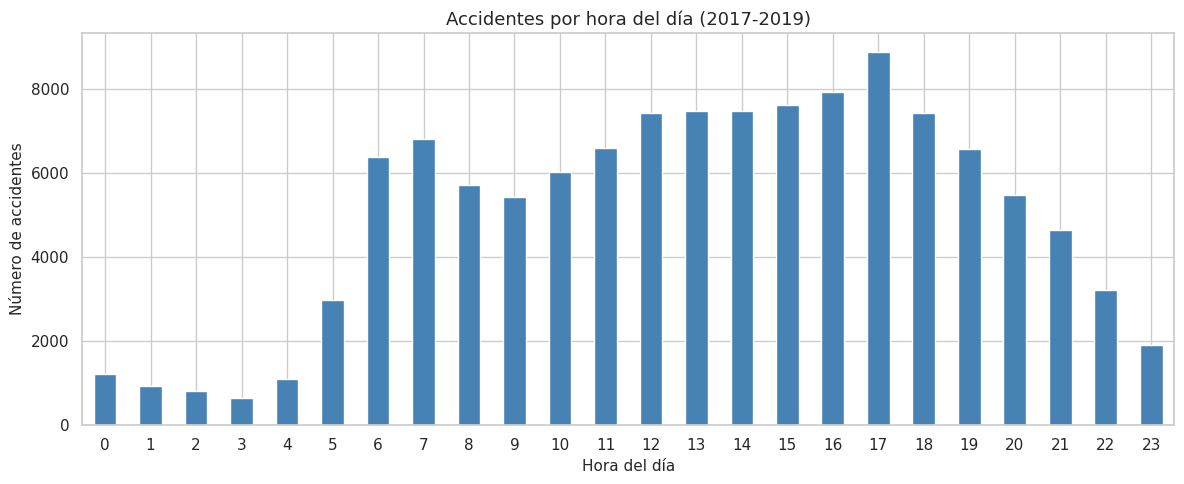

Hora con más accidentes: 17h (8,880 registros)


In [ ]:
# La hora del día es probablemente la variable más importante del modelo.
# Esta visualización nos muestra si hay patrones claros de concentración
# que justifiquen incluirla como feature principal.

fig, ax = plt.subplots(figsize=(12, 5))

accidentes['Hora'].value_counts().sort_index().plot(
    kind='bar', ax=ax, color='steelblue', edgecolor='white'
)

ax.set_title('Accidentes por hora del día (2017-2019)')
ax.set_xlabel('Hora del día')
ax.set_ylabel('Número de accidentes')
ax.set_xticklabels(range(24), rotation=0)

plt.tight_layout()
plt.show()

# Hora pico
hora_pico = accidentes['Hora'].value_counts().idxmax()
print(f"Hora con más accidentes: {hora_pico}h "
      f"({accidentes['Hora'].value_counts().max():,} registros)")
fig.savefig(f'{RUTA_FIGURAS}fig_01_accidentes_hora.png', dpi=150, bbox_inches='tight')

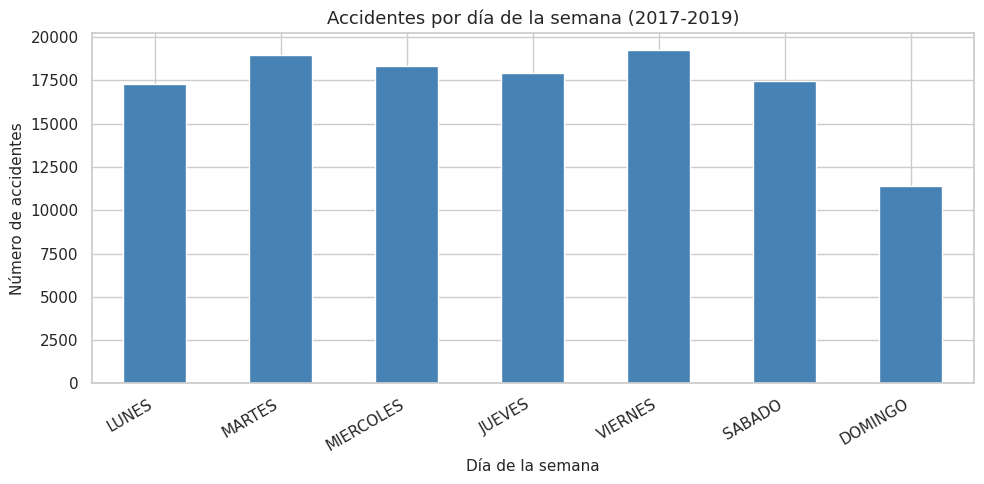

Dia_sem
LUNES        17276
MARTES       18943
MIERCOLES    18315
JUEVES       17933
VIERNES      19287
SABADO       17456
DOMINGO      11377
Name: count, dtype: int64


In [ ]:
# El día de la semana puede capturar patrones de movilidad urbana:
# más tráfico entre semana, comportamientos distintos en fin de semana.

orden_dias = ['LUNES', 'MARTES', 'MIERCOLES', 'JUEVES',
              'VIERNES', 'SABADO', 'DOMINGO']

conteo_dias = (accidentes['Dia_sem']
               .value_counts()
               .reindex(orden_dias))

fig, ax = plt.subplots(figsize=(10, 5))

conteo_dias.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')

ax.set_title('Accidentes por día de la semana (2017-2019)')
ax.set_xlabel('Día de la semana')
ax.set_ylabel('Número de accidentes')
ax.set_xticklabels(orden_dias, rotation=30, ha='right')

plt.tight_layout()
plt.show()

print(conteo_dias)
fig.savefig(f'{RUTA_FIGURAS}fig_02_accidentes_dia.png', dpi=150, bbox_inches='tight')

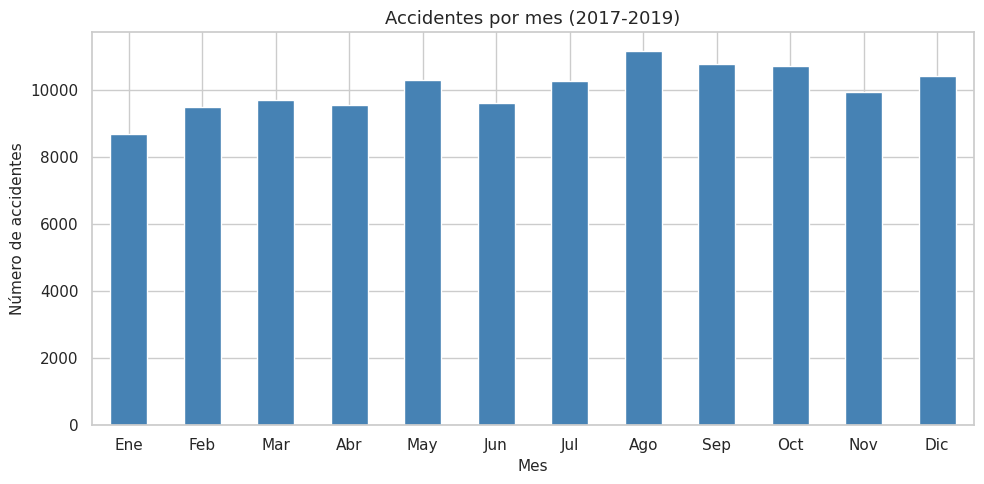

In [ ]:
# La distribución mensual puede revelar estacionalidad relacionada
# con épocas de lluvia, vacaciones o festividades en Medellín.

nombres_mes = {1:'Ene', 2:'Feb', 3:'Mar', 4:'Abr', 5:'May', 6:'Jun',
               7:'Jul', 8:'Ago', 9:'Sep', 10:'Oct', 11:'Nov', 12:'Dic'}

conteo_mes = accidentes['Mes'].value_counts().sort_index()
conteo_mes.index = conteo_mes.index.map(nombres_mes)

fig, ax = plt.subplots(figsize=(10, 5))

conteo_mes.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')

ax.set_title('Accidentes por mes (2017-2019)')
ax.set_xlabel('Mes')
ax.set_ylabel('Número de accidentes')
ax.set_xticklabels(conteo_mes.index, rotation=0)

plt.tight_layout()
plt.show()
fig.savefig(f'{RUTA_FIGURAS}fig_03_accidentes_mes.png', dpi=150, bbox_inches='tight')

### Distribución temporal

**Por hora del día:** el patrón es contundente. Los accidentes se concentran
en la franja de las 6h a las 19h, con un pico máximo a las 17h (8,880 registros),
que corresponde a la hora de salida laboral y máxima densidad vehicular en Medellín.
Hay un segundo pico en la mañana entre las 6h y las 7h, consistente con la hora de
entrada. Entre las 0h y las 4h los accidentes caen drásticamente, aunque no
desaparecen. Este patrón justifica plenamente incluir la hora como variable principal
del modelo, tanto en formato numérico como en codificación cíclica.

**Por día de la semana:** la distribución es relativamente uniforme de lunes a sábado,
con viernes como el día más accidentado (19,287 registros) y domingo con una caída
notable (11,377 registros), aproximadamente un 40% menos que el día pico. Esto refleja
los patrones de movilidad urbana: menor circulación vehicular los domingos. La variable
de fin de semana que construiremos en el feature engineering captura parcialmente este
efecto.

**Por mes:** no hay una estacionalidad marcada. Los meses de agosto a octubre muestran
una leve concentración mayor, posiblemente relacionada con las temporadas de lluvia en
Medellín. Enero es el mes con menos accidentes, consistente con las vacaciones de fin
de año. La variación entre meses no es dramática, lo que sugiere que el mes por sí solo
no será un predictor muy fuerte.

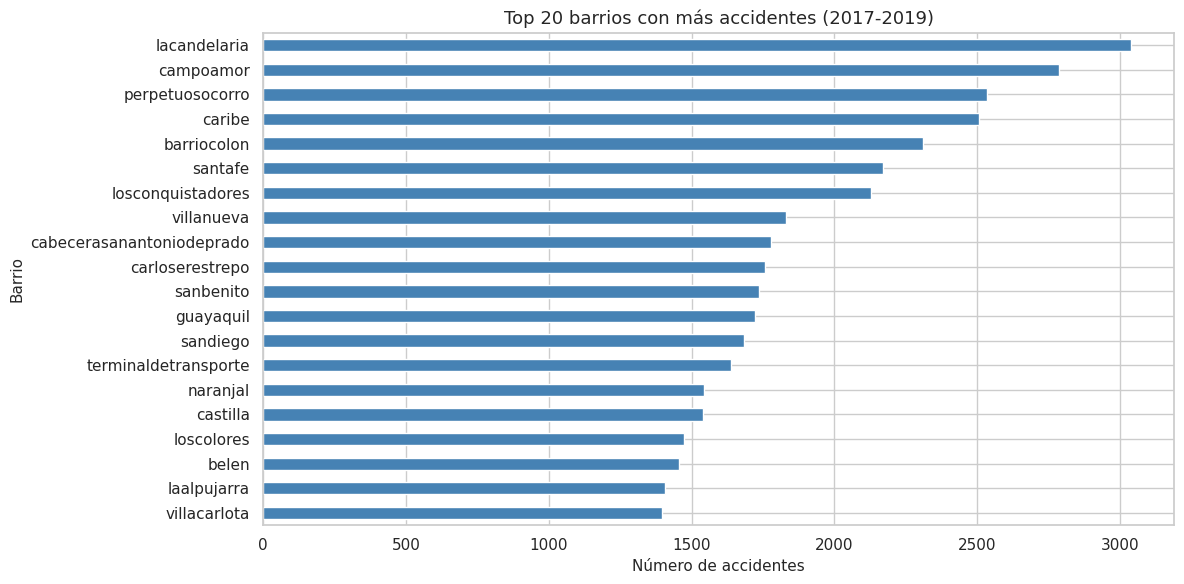

El barrio con más accidentes concentra el 2.4% del total


In [ ]:
# Identificar los barrios con mayor concentración de accidentes
# es clave para entender la distribución espacial del problema
# y para construir agregados históricos por barrio en el feature engineering.

top_barrios = (raw['BARRIO']
               .value_counts()
               .head(20))

fig, ax = plt.subplots(figsize=(12, 6))

top_barrios.plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')

ax.set_title('Top 20 barrios con más accidentes (2017-2019)')
ax.set_xlabel('Número de accidentes')
ax.set_ylabel('Barrio')
ax.invert_yaxis()

plt.tight_layout()
plt.show()

print(f"El barrio con más accidentes concentra el "
      f"{top_barrios.iloc[0]/len(raw)*100:.1f}% del total")
fig.savefig(f'{RUTA_FIGURAS}fig_04_top_barrios.png', dpi=150, bbox_inches='tight')

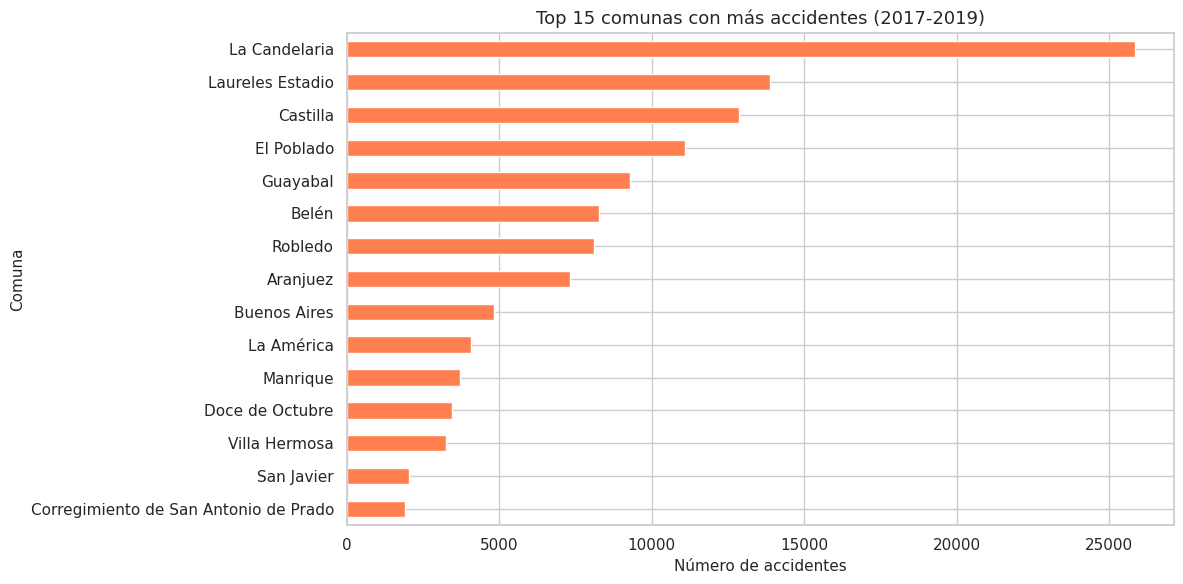

In [ ]:
# Las comunas agrupan barrios y nos dan una visión más agregada
# de la distribución espacial. Útil para el caso de uso operacional.

top_comunas = (raw['COMUNA']
               .value_counts()
               .head(15))

fig, ax = plt.subplots(figsize=(12, 6))

top_comunas.plot(kind='barh', ax=ax, color='coral', edgecolor='white')

ax.set_title('Top 15 comunas con más accidentes (2017-2019)')
ax.set_xlabel('Número de accidentes')
ax.set_ylabel('Comuna')
ax.invert_yaxis()

plt.tight_layout()
plt.show()
fig.savefig(f'{RUTA_FIGURAS}fig_05_top_comunas.png', dpi=150, bbox_inches='tight')

### Distribución espacial

**Por barrio:** la distribución es muy dispersa. El barrio con más accidentes,
La Candelaria, concentra apenas el 2.4% del total, lo que indica que los accidentes
no están dominados por un solo punto sino distribuidos a lo largo de la ciudad. Los
primeros cinco barrios (La Candelaria, Campo Amor, Perpetuo Socorro, Caribe y Barrio
Colón) son todos de alta densidad comercial y vehicular. Esta dispersión hace que el
modelo necesite aprender patrones específicos por barrio, justificando el uso de
agregados históricos como feature.

**Por comuna:** La Candelaria concentra la mayor accidentalidad con diferencia, seguida
de Laureles Estadio y Castilla. Estas tres comunas representan zonas de alto flujo
vehicular, comercio y actividad nocturna. La variable de comuna puede ser útil como
agrupador geográfico en el feature engineering.

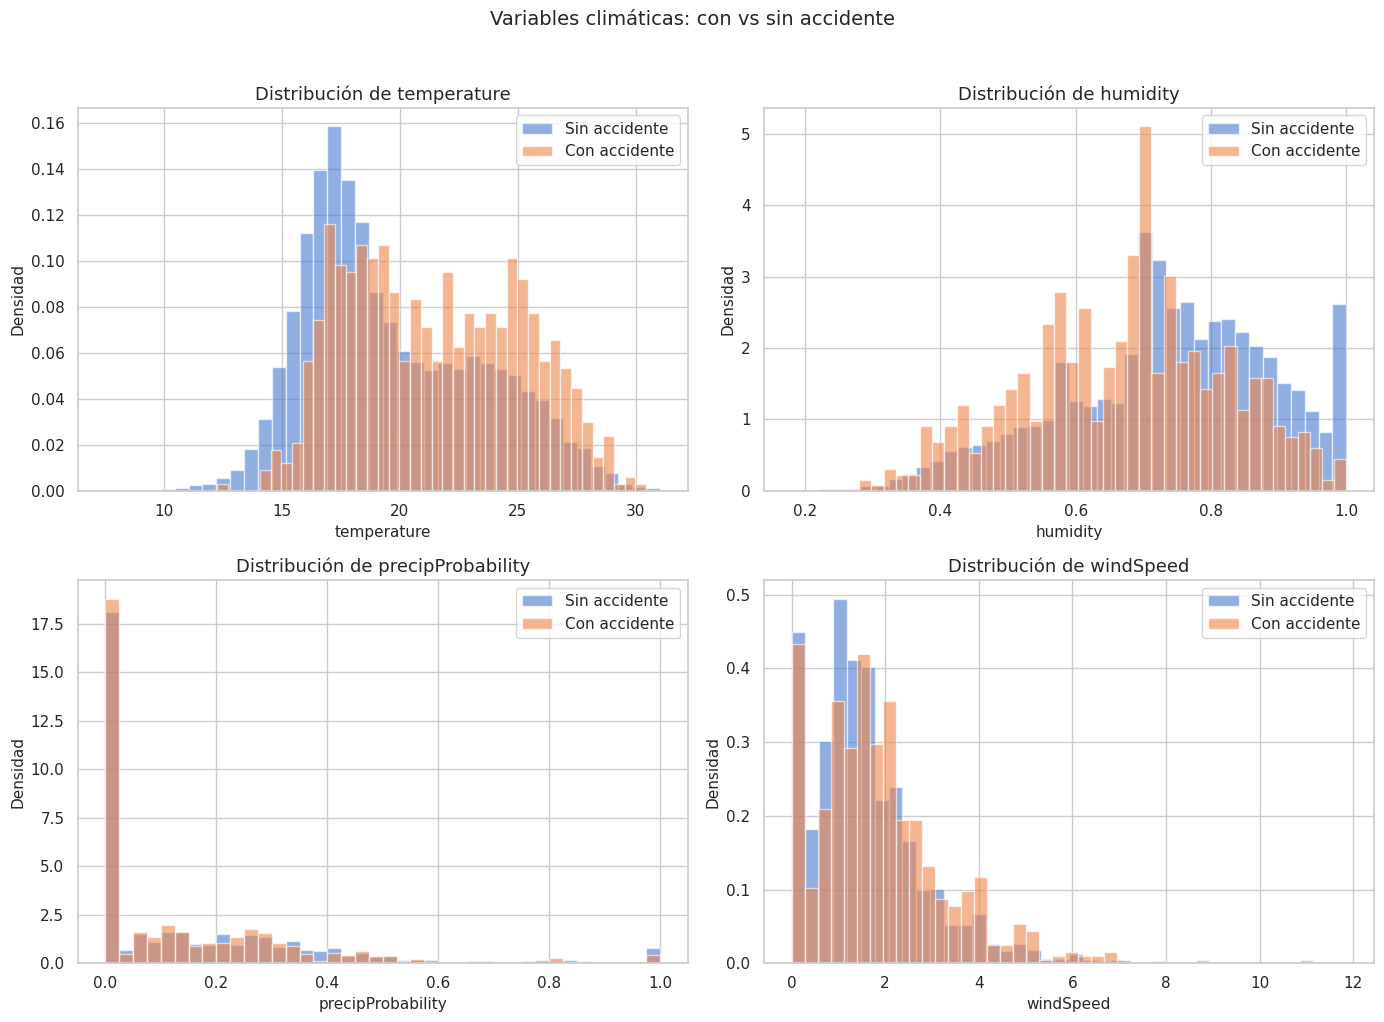

In [ ]:
# Para evaluar si el clima tiene relación con la ocurrencia de accidentes,
# comparamos la distribución de las variables climáticas entre horas con
# accidente (target=1) y sin accidente (target=0).
# Usamos una muestra de clima para no saturar la memoria.

# Muestra representativa de clima para la comparación
clima_muestra = clima.sample(n=50000, random_state=RANDOM_STATE)

# Identificamos qué registros de clima corresponden a accidentes
llave_accidentes = set(
    zip(accidentes['BARRIO'], accidentes['TW'])
)

clima_muestra['target'] = clima_muestra.apply(
    lambda r: 1 if (r['BARRIO'], r['TW']) in llave_accidentes else 0,
    axis=1
)

# Visualización de distribuciones por variable climática
variables_clima = ['temperature', 'humidity',
                   'precipProbability', 'windSpeed']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, var in enumerate(variables_clima):
    for label, grupo in clima_muestra.groupby('target'):
        axes[i].hist(
            grupo[var].dropna(),
            bins=40,
            alpha=0.6,
            label='Con accidente' if label == 1 else 'Sin accidente',
            density=True
        )
    axes[i].set_title(f'Distribución de {var}')
    axes[i].set_xlabel(var)
    axes[i].set_ylabel('Densidad')
    axes[i].legend()

plt.suptitle('Variables climáticas: con vs sin accidente',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()
fig.savefig(f'{RUTA_FIGURAS}fig_06_clima_vs_accidente.png', dpi=150, bbox_inches='tight')

### Variables climáticas y su relación con la accidentalidad

Las distribuciones de temperatura, humedad, probabilidad de precipitación y velocidad
del viento muestran diferencias sutiles pero consistentes entre las horas con y sin
accidente.

La temperatura presenta una distribución ligeramente desplazada hacia valores más altos
en las horas con accidente, lo cual es consistente con el patrón horario: los accidentes
ocurren más durante el día cuando hace más calor.

La humedad muestra que las horas con accidente tienden a tener humedad moderada (entre
0.6 y 0.8), mientras que las horas sin accidente muestran mayor proporción en humedad
alta (cercana a 1.0), que corresponde a madrugadas y horas de lluvia intensa con poco
tráfico.

La probabilidad de precipitación es llamativa: las horas con accidente tienen mayor
concentración en valores bajos de precipitación, lo que sugiere que la lluvia intensa
no necesariamente aumenta los accidentes, posiblemente porque reduce la circulación
vehicular. Este es un hallazgo contraintuitivo que vale la pena documentar.

La velocidad del viento no muestra diferencias claras entre las dos clases, lo que
sugiere que esta variable tendrá poco poder predictivo por sí sola.

**Conclusión del EDA climático:** temperatura y humedad tienen potencial predictivo
moderado. La probabilidad de precipitación tiene un efecto no lineal que el modelo
debe capturar. La velocidad del viento es de baja relevancia individual pero se
mantiene en el dataset por si aporta en combinación con otras variables.

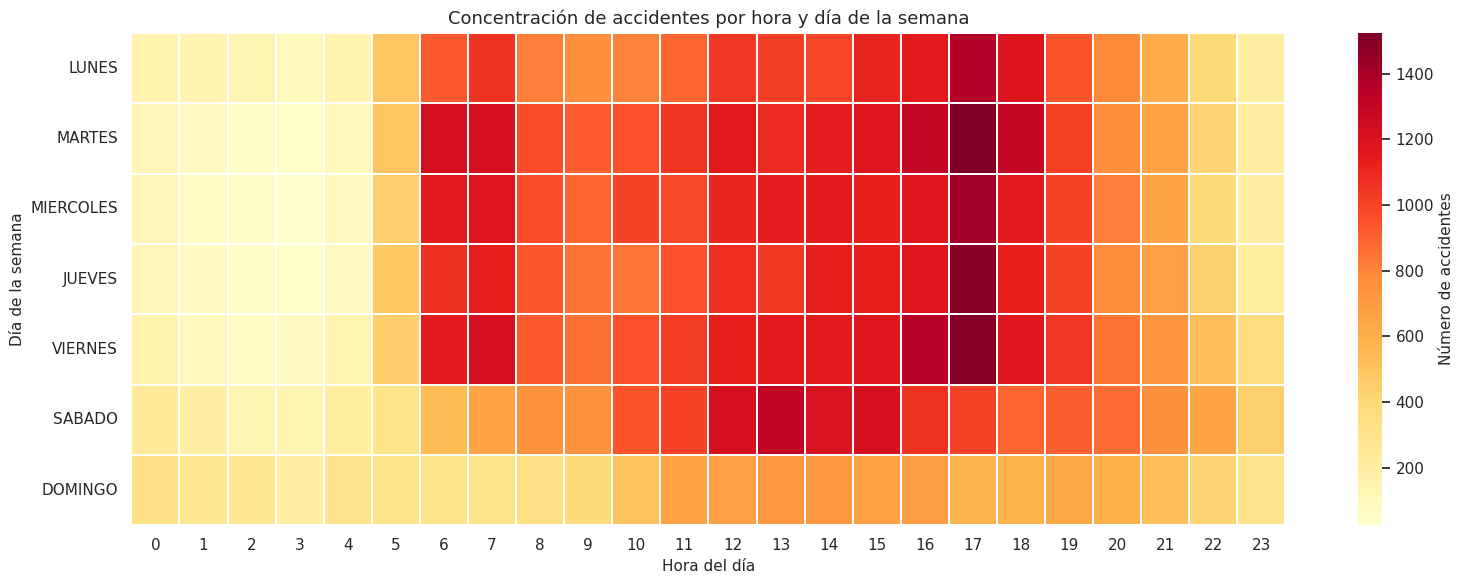

In [ ]:
# Esta visualización combina las dos dimensiones temporales más importantes.
# Un mapa de calor hora x día revela los patrones de riesgo más claros
# y es directamente útil para el caso de uso operacional.

pivot = (accidentes
         .groupby(['Dia_sem', 'Hora'])
         .size()
         .unstack(fill_value=0)
         .reindex(orden_dias))

fig, ax = plt.subplots(figsize=(16, 6))

sns.heatmap(
    pivot,
    cmap='YlOrRd',
    ax=ax,
    linewidths=0.3,
    cbar_kws={'label': 'Número de accidentes'}
)

ax.set_title('Concentración de accidentes por hora y día de la semana')
ax.set_xlabel('Hora del día')
ax.set_ylabel('Día de la semana')

plt.tight_layout()
plt.show()
fig.savefig(f'{RUTA_FIGURAS}fig_07_heatmap_hora_dia.png', dpi=150, bbox_inches='tight')

### Mapa de calor: hora por día de la semana

El mapa de calor confirma y enriquece los hallazgos anteriores. El bloque de mayor
riesgo es claramente la franja de las 16h a las 18h de lunes a viernes, con el punto
más crítico en viernes a las 17h. Las madrugadas (0h a 4h) son consistentemente de
bajo riesgo en todos los días. El domingo muestra un comportamiento diferenciado:
la concentración se desplaza ligeramente hacia horas más tardías comparado con los
días de semana, con algo más de actividad en la noche del sábado al domingo.

Esta visualización es directamente útil para el caso de uso operacional: una alerta
diaria que priorice los barrios de mayor riesgo en esa franja horaria tendría alta
relevancia práctica.

## 3. Calidad de datos

Antes de modelar garantizaremos que los datos sean confiables, para evitar entrenar sobre datos sucios y que el modelo aprenda patrones incorrectos y produzca  predicciones que no tienen validez real. Verificaremos la consistencia entre las tres tablas, identificamos valores faltantes, duplicados, inconsistencias
y valores atípicos, y documentamos explícitamente cada decisión tomada y su justificación.

In [ ]:
# Revisamos los valores faltantes en cada tabla.
# Esto determina qué variables podemos usar directamente
# y cuáles requieren imputación o eliminación.

def resumen_nulos(df, nombre):
    nulos = df.isnull().sum()
    pct = (nulos / len(df) * 100).round(2)
    resumen = pd.DataFrame({
        'Nulos': nulos,
        'Porcentaje (%)': pct
    })
    resumen = resumen[resumen['Nulos'] > 0].sort_values('Nulos', ascending=False)
    print(f"\nValores faltantes en {nombre}:")
    if len(resumen) == 0:
        print("  Sin valores faltantes ✓")
    else:
        print(resumen.to_string())
    return resumen

nulos_accidentes = resumen_nulos(accidentes, 'accidentes')
nulos_clima      = resumen_nulos(clima, 'clima')
nulos_raw        = resumen_nulos(raw, 'raw_accidentes')


Valores faltantes en accidentes:
  Sin valores faltantes ✓

Valores faltantes en clima:
                       Nulos  Porcentaje (%)
windBearing          1032513         12.9200
icon                  548641          6.8700
summary               548641          6.8700
precipProbability     547401          6.8500
precipIntensity       547401          6.8500
windSpeed              32793          0.4100
cloudCover              7950          0.1000
visibility              4290          0.0500
uvIndex                 4280          0.0500
humidity                 915          0.0100
temperature              610          0.0100
apparentTemperature      610          0.0100
dewPoint                 305          0.0000

Valores faltantes en raw_accidentes:
            Nulos  Porcentaje (%)
MES_NOMBRE  82740         66.1300
DISENO        429          0.3400
RADICADO        5          0.0000


**Valores faltantes**

`accidentes` está completamente limpia, sin ningún valor faltante. Eso es ideal
porque es la fuente de la variable objetivo.

`clima` presenta el patrón de nulos más importante. `windBearing` tiene el 12.9%
de valores faltantes, lo que es suficientemente alto para considerar eliminarla
del modelo en lugar de imputarla. `summary`, `icon`, `precipProbability` y
`precipIntensity` tienen cerca del 6.8% de nulos cada una, probablemente
correspondientes al mismo conjunto de registros, lo que sugiere que hubo períodos
o barrios sin cobertura del servicio meteorológico. Las variables restantes tienen
menos del 0.5% de nulos y se imputarán con la mediana.

`raw_accidentes` tiene un caso llamativo: `MES_NOMBRE` tiene el 66.13% de valores
faltantes. Sin embargo esto no es un problema real porque esa variable es redundante,
el mes ya está disponible en la columna `Mes` en formato numérico. Se descarta sin
imputación. `DISENO` tiene 0.34% de nulos, manejable. `RADICADO` tiene 5 nulos
sobre 125,122 registros, despreciable.

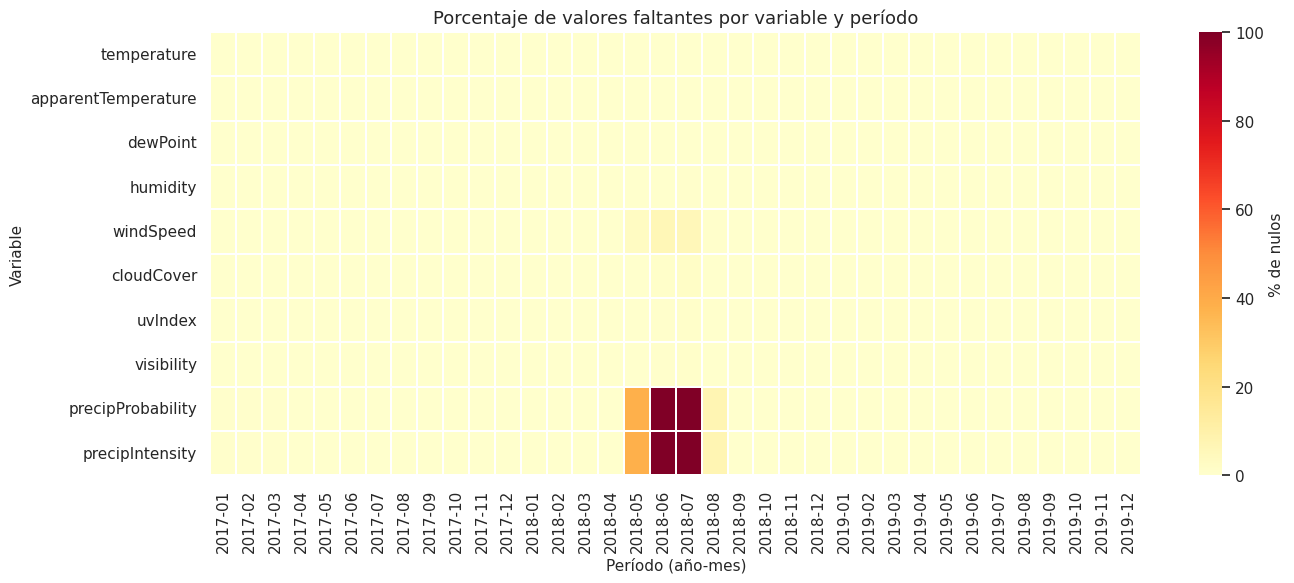

In [ ]:
# Verificamos si los valores faltantes están concentrados en períodos
# específicos o distribuidos aleatoriamente.
# Un patrón concentrado indica interrupción del servicio meteorológico,
# no ruido aleatorio, y cambia la estrategia de imputación.

import matplotlib.pyplot as plt
import seaborn as sns

variables_clima = ['temperature', 'apparentTemperature', 'dewPoint',
                   'humidity', 'windSpeed', 'cloudCover', 'uvIndex',
                   'visibility', 'precipProbability', 'precipIntensity']

# Crear columnas de año y mes
clima['anio'] = clima['TW'].dt.year
clima['mes']  = clima['TW'].dt.month

# Calcular porcentaje de nulos por variable, año y mes
nulos_pivot = pd.DataFrame()

for var in variables_clima:
    temp = (clima.groupby(['anio', 'mes'])[var]
            .apply(lambda x: x.isna().sum() / len(x) * 100)
            .reset_index(name=var))
    if nulos_pivot.empty:
        nulos_pivot = temp
    else:
        nulos_pivot = nulos_pivot.merge(temp, on=['anio', 'mes'])

nulos_pivot['periodo'] = (nulos_pivot['anio'].astype(str) + '-' +
                          nulos_pivot['mes'].astype(str).str.zfill(2))

nulos_heatmap = nulos_pivot.set_index('periodo')[variables_clima]

fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(
    nulos_heatmap.T,
    cmap='YlOrRd',
    ax=ax,
    linewidths=0.3,
    cbar_kws={'label': '% de nulos'}
)
ax.set_title('Porcentaje de valores faltantes por variable y período')
ax.set_xlabel('Período (año-mes)')
ax.set_ylabel('Variable')
plt.tight_layout()
plt.show()

# Limpiar columnas auxiliares
clima = clima.drop(columns=['anio', 'mes'])

In [ ]:
# Un duplicado exacto en accidentes o clima significa que una combinación
# (barrio, hora) aparece más de una vez, lo que distorsionaría el join
# y la construcción de la variable objetivo.

def revisar_duplicados(df, nombre, llaves):
    dup_totales = df.duplicated().sum()
    dup_llaves  = df.duplicated(subset=llaves).sum()

    print(f"\nDuplicados en {nombre}:")
    print(f"  Filas completamente duplicadas : {dup_totales:,}")
    print(f"  Duplicados en llaves {llaves}  : {dup_llaves:,}")

revisar_duplicados(accidentes, 'accidentes', ['BARRIO', 'TW'])
revisar_duplicados(clima,      'clima',      ['BARRIO', 'TW'])
revisar_duplicados(raw,        'raw_accidentes', ['RADICADO'])


Duplicados en accidentes:
  Filas completamente duplicadas : 0
  Duplicados en llaves ['BARRIO', 'TW']  : 0

Duplicados en clima:
  Filas completamente duplicadas : 0
  Duplicados en llaves ['BARRIO', 'TW']  : 0

Duplicados en raw_accidentes:
  Filas completamente duplicadas : 0
  Duplicados en llaves ['RADICADO']  : 21


**Duplicados**

`accidentes` y `clima` no tienen ningún duplicado ni en filas completas ni en sus
llaves de cruce `(BARRIO, TW)`. Esto garantiza que el join va a producir exactamente
una fila por combinación, sin multiplicaciones indeseadas.

`raw_accidentes` tiene 21 radicados duplicados. Como `raw` no entra directamente
al join sino que se usa para construir agregados históricos, estos duplicados se
eliminan antes de calcular cualquier feature derivado de esta tabla.


In [ ]:
# La llave de cruce entre tablas es (BARRIO, TW).
# TW debe tener el mismo formato en las tres tablas para que el join funcione.
# Ya sabemos que es datetime64[ns] en las tres, pero verificamos la granularidad:
# ¿está truncada a la hora en todas?

print("Verificación de granularidad temporal (TW):")
print(f"  accidentes - minutos únicos en TW: "
      f"{accidentes['TW'].dt.minute.unique()}")
print(f"  clima      - minutos únicos en TW: "
      f"{clima['TW'].dt.minute.unique()}")
print(f"  raw        - minutos únicos en TW: "
      f"{raw['TW'].dt.minute.unique()}")

# Verificamos también que los segundos sean 0 en todas
print(f"\n  accidentes - segundos únicos en TW: "
      f"{accidentes['TW'].dt.second.unique()}")
print(f"  clima      - segundos únicos en TW: "
      f"{clima['TW'].dt.second.unique()}")
print(f"  raw        - segundos únicos en TW: "
      f"{raw['TW'].dt.second.unique()}")

Verificación de granularidad temporal (TW):
  accidentes - minutos únicos en TW: [0]
  clima      - minutos únicos en TW: [0]
  raw        - minutos únicos en TW: [0]

  accidentes - segundos únicos en TW: [0]
  clima      - segundos únicos en TW: [0]
  raw        - segundos únicos en TW: [0]


**Granularidad temporal**

Las tres tablas tienen `TW` truncado exactamente a la hora, con minutos y segundos
en cero. Esto confirma que el join por `(BARRIO, TW)` va a funcionar correctamente
sin necesidad de transformaciones adicionales

In [ ]:
# Ya identificamos en la sección 1 que hay 3 barrios en accidentes
# que no están en clima. Aquí documentamos formalmente ese hallazgo,
# verificamos si hay diferencias de capitalización o espacios,
# y tomamos la decisión de tratamiento.

# Verificar capitalización y espacios
print("Muestra de valores de BARRIO en cada tabla:")
print(f"\n  accidentes : {sorted(accidentes['BARRIO'].unique())[:10]}")
print(f"\n  clima      : {sorted(clima['BARRIO'].unique())[:10]}")
print(f"\n  raw        : {sorted(raw['BARRIO'].unique())[:10]}")

# Barrios que no hacen match
barrios_accidentes = set(accidentes['BARRIO'].str.strip().str.lower().unique())
barrios_clima      = set(clima['BARRIO'].str.strip().str.lower().unique())

sin_match = barrios_accidentes - barrios_clima
print(f"\nBarrios en accidentes sin match en clima: {sorted(sin_match)}")
print(f"Registros afectados: "
      f"{accidentes[accidentes['BARRIO'].isin(sin_match)].shape[0]}")

Muestra de valores de BARRIO en cada tabla:

  accidentes : ['aguasfrias', 'aldeapablovi', 'alejandria', 'alejandroechavarria', 'alfonsolopez', 'altamira', 'altavista', 'altavistasectorcentral', 'altosdelpoblado', 'andalucia']

  clima      : ['aguasfrias', 'aldeapablovi', 'alejandria', 'alejandroechavarria', 'alfonsolopez', 'altamira', 'altavista', 'altavistasectorcentral', 'altosdelpoblado', 'andalucia']

  raw        : ['aguasfrias', 'aldeapablovi', 'alejandria', 'alejandroechavarria', 'alfonsolopez', 'altamira', 'altavista', 'altavistasectorcentral', 'altosdelpoblado', 'andalucia']

Barrios en accidentes sin match en clima: ['elastillero', 'suburbanoaguasfrias', 'yarumalito']
Registros afectados: 4


**Normalización de barrios**

Los nombres de barrio son consistentes en formato entre las tres tablas: todos en
minúsculas, sin espacios, sin tildes. Los tres barrios sin match (`elastillero`,
`suburbanoaguasfrias`, `yarumalito`) afectan solo 4 registros y se eliminan.

In [ ]:
# Identificamos en la inspección inicial que CLASE y GRAVEDAD
# tienen categorías duplicadas por diferencias de capitalización
# o caracteres especiales. Las normalizamos aquí.

print("CLASE antes de normalizar:")
print(raw['CLASE'].value_counts())

# Normalización: strip, lower, eliminar espacios dobles
raw['CLASE']    = raw['CLASE'].str.strip().str.lower()
raw['GRAVEDAD'] = raw['GRAVEDAD'].str.strip().str.lower()

# Unificar variantes
raw['CLASE'] = raw['CLASE'].replace({
    'caída ocupante': 'caida ocupante',
    'choque ': 'choque'
})

raw['GRAVEDAD'] = raw['GRAVEDAD'].replace({
    'con heridos' : 'herido',
    'solo daños'  : 'solo daños',
    'con muertos' : 'muerto'
})

print("\nCLASE después de normalizar:")
print(raw['CLASE'].value_counts())

print("\nGRAVEDAD después de normalizar:")
print(raw['GRAVEDAD'].value_counts())

CLASE antes de normalizar:
CLASE
Choque                86065
Otro                  12947
Atropello             11199
Caida Ocupante        10532
Volcamiento            4342
Incendio                 19
Caída Ocupante           14
Choque                    3
Choque y Atropello        1
Name: count, dtype: int64

CLASE después de normalizar:
CLASE
choque                86068
otro                  12947
atropello             11199
caida ocupante        10546
volcamiento            4342
incendio                 19
choque y atropello        1
Name: count, dtype: int64

GRAVEDAD después de normalizar:
GRAVEDAD
herido        66714
solo daños    57685
muerto          723
Name: count, dtype: int64


**Normalización de categorías**

`CLASE` quedó reducida de 9 categorías a 6 después de unificar variantes.
`GRAVEDAD` quedó en 3 categorías limpias: `herido`, `solo daños` y `muerto`.
Los valores fuera de rango físico en variables climáticas son cero en todas las
variables revisadas, lo que confirma que no hay errores de medición evidentes.


In [ ]:
# Revisamos si hay valores fuera de rango físicamente posible
# en las variables climáticas más importantes.

limites = {
    'temperature'        : (0, 45),
    'humidity'           : (0, 1),
    'precipProbability'  : (0, 1),
    'windSpeed'          : (0, 50),
    'visibility'         : (0, 20),
    'uvIndex'            : (0, 15)
}

print("Valores fuera de rango físico en clima:")
for var, (vmin, vmax) in limites.items():
    fuera = clima[
        (clima[var] < vmin) | (clima[var] > vmax)
    ].shape[0]
    print(f"  {var:25s}: {fuera:,} registros fuera de [{vmin}, {vmax}]")

Valores fuera de rango físico en clima:
  temperature              : 0 registros fuera de [0, 45]
  humidity                 : 0 registros fuera de [0, 1]
  precipProbability        : 0 registros fuera de [0, 1]
  windSpeed                : 0 registros fuera de [0, 50]
  visibility               : 0 registros fuera de [0, 20]
  uvIndex                  : 0 registros fuera de [0, 15]


In [ ]:
# Resumen consolidado de todos los problemas encontrados
# y las decisiones tomadas. Esta celda no transforma datos,
# solo documenta para el informe.

decisiones = {
    'Barrios sin match en clima'        : 'Eliminar 4 registros (0.003%). '
                                          'Impacto despreciable.',
    'Nulos en precipProbability'        : 'Imputar con mediana por barrio. '
                                          'Variable relevante para el modelo.',
    'Nulos en windSpeed y visibility'   : 'Imputar con mediana global. '
                                          'Bajo porcentaje de nulos.',
    'Duplicados en llaves de cruce'     : 'Eliminar duplicados exactos '
                                          'antes del join.',
    'Normalización CLASE y GRAVEDAD'    : 'Unificar variantes por strip, '
                                          'lower y mapeo explícito.',
    'Granularidad TW'                   : 'Verificada: todas las tablas '
                                          'truncadas a la hora exacta.'
}

print("Decisiones de calidad de datos:")
print()
for problema, decision in decisiones.items():
    print(f"  Problema  : {problema}")
    print(f"  Decisión  : {decision}")
    print()

Decisiones de calidad de datos:

  Problema  : Barrios sin match en clima
  Decisión  : Eliminar 4 registros (0.003%). Impacto despreciable.

  Problema  : Nulos en precipProbability
  Decisión  : Imputar con mediana por barrio. Variable relevante para el modelo.

  Problema  : Nulos en windSpeed y visibility
  Decisión  : Imputar con mediana global. Bajo porcentaje de nulos.

  Problema  : Duplicados en llaves de cruce
  Decisión  : Eliminar duplicados exactos antes del join.

  Problema  : Normalización CLASE y GRAVEDAD
  Decisión  : Unificar variantes por strip, lower y mapeo explícito.

  Problema  : Granularidad TW
  Decisión  : Verificada: todas las tablas truncadas a la hora exacta.



In [ ]:
# Aplicamos todas las decisiones documentadas en la celda anterior.
# Esta celda transforma los datos y deja todo listo para el join.

# 1. Eliminar barrios sin match en clima
barrios_sin_match = ['elastillero', 'suburbanoaguasfrias', 'yarumalito']
accidentes = accidentes[~accidentes['BARRIO'].isin(barrios_sin_match)].copy()
print(f"accidentes tras eliminar barrios sin match: {accidentes.shape[0]:,} filas")

# 2. Eliminar windBearing de clima por alto porcentaje de nulos y baja relevancia
clima = clima.drop(columns=['windBearing'])
print(f"clima tras eliminar windBearing: {clima.shape[1]} columnas")

# 3. Imputar variables con nulos concentrados en mayo-julio 2018
# usando cascada de imputación con datos de 2017 únicamente.
# La cascada va de más específico (barrio+mes+hora) a más general (mes)
# para garantizar que siempre haya un valor de referencia.

clima['mes_num']  = clima['TW'].dt.month
clima['hora_num'] = clima['TW'].dt.hour
clima['anio_num'] = clima['TW'].dt.year

clima_2017 = clima[clima['anio_num'] == 2017].copy()

for col in ['precipProbability', 'precipIntensity',
            'temperature', 'apparentTemperature', 'dewPoint']:

    # Nivel 1: barrio + mes + hora
    ref1 = (clima_2017
            .groupby(['BARRIO', 'mes_num', 'hora_num'])[col]
            .median()
            .reset_index(name='ref1'))
    clima = clima.merge(ref1, on=['BARRIO', 'mes_num', 'hora_num'], how='left')
    clima[col] = clima[col].fillna(clima['ref1'])
    clima = clima.drop(columns=['ref1'])

    # Nivel 2: barrio + mes
    ref2 = (clima_2017
            .groupby(['BARRIO', 'mes_num'])[col]
            .median()
            .reset_index(name='ref2'))
    clima = clima.merge(ref2, on=['BARRIO', 'mes_num'], how='left')
    clima[col] = clima[col].fillna(clima['ref2'])
    clima = clima.drop(columns=['ref2'])

    # Nivel 3: mes + hora
    ref3 = (clima_2017
            .groupby(['mes_num', 'hora_num'])[col]
            .median()
            .reset_index(name='ref3'))
    clima = clima.merge(ref3, on=['mes_num', 'hora_num'], how='left')
    clima[col] = clima[col].fillna(clima['ref3'])
    clima = clima.drop(columns=['ref3'])

    # Nivel 4: mediana global del mes en 2017
    ref4 = (clima_2017
            .groupby('mes_num')[col]
            .median()
            .reset_index(name='ref4'))
    clima = clima.merge(ref4, on='mes_num', how='left')
    clima[col] = clima[col].fillna(clima['ref4'])
    clima = clima.drop(columns=['ref4'])

clima = clima.drop(columns=['mes_num', 'hora_num', 'anio_num'])

# 4. Imputar demás variables con bajo porcentaje de nulos con mediana global
for col in ['windSpeed', 'cloudCover', 'visibility', 'uvIndex', 'humidity']:
    clima[col] = clima[col].fillna(clima[col].median())

# 5. Eliminar duplicados en raw por RADICADO
raw = raw.drop_duplicates(subset=['RADICADO'])
print(f"raw tras eliminar duplicados: {raw.shape[0]:,} filas")

# 6. Eliminar MES_NOMBRE de raw por ser redundante
raw = raw.drop(columns=['MES_NOMBRE'])

# 7. Verificación final de nulos
print("\nNulos restantes después de limpieza:")
print(f"  accidentes : {accidentes.isnull().sum().sum()}")
print(f"  clima      : {clima.isnull().sum().sum()}")
print(f"  raw        : {raw.isnull().sum().sum()}")

# 8. Verificar nulos restantes en variables imputadas
print("\nNulos por variable imputada:")
for col in ['precipProbability', 'precipIntensity',
            'temperature', 'apparentTemperature', 'dewPoint']:
    print(f"  {col}: {clima[col].isna().sum():,}")

print("\nLimpieza completada ✓")

accidentes tras eliminar barrios sin match: 120,583 filas
clima tras eliminar windBearing: 14 columnas
raw tras eliminar duplicados: 125,101 filas

Nulos restantes después de limpieza:
  accidentes : 0
  clima      : 1097282
  raw        : 422

Nulos por variable imputada:
  precipProbability: 0
  precipIntensity: 0
  temperature: 0
  apparentTemperature: 0
  dewPoint: 0

Limpieza completada ✓


**Decisión sobre `windBearing`**

Con 12.9% de nulos y siendo una variable de dirección del viento cuya relevancia
predictiva el EDA mostró como baja, la decisión es eliminarla del dataset modelable
en lugar de imputarla. Imputar el 12.9% de una variable de baja relevancia introduce
más ruido que valor.

Casi todo limpio pero clima todavía tiene 1,097,282 nulos. Para confirmar:

In [ ]:
# Verificar qué columnas tienen nulos restantes en clima
nulos_restantes = clima.isnull().sum()
print(nulos_restantes[nulos_restantes > 0])

summary    548641
icon       548641
dtype: int64


## Decisión sobre `summary` e `icon`

Estas columnas son etiquetas textuales que el servicio meteorológico genera
a partir de las variables numéricas, no al contrario. Toda la información que
contienen ya está capturada de forma más precisa en variables como `visibility`,
`cloudCover`, `precipProbability` y `precipIntensity`. Imputarlas y codificarlas
agregaría complejidad sin aportar información nueva al modelo.

In [ ]:
# summary e icon son redundantes con las variables numéricas de clima.
# Se eliminan para reducir complejidad sin perder información.
clima = clima.drop(columns=['summary', 'icon'])

print(f"clima tras eliminar summary e icon: {clima.shape[1]} columnas")
print(f"Nulos restantes en clima: {clima.isnull().sum().sum()}")

clima tras eliminar summary e icon: 12 columnas
Nulos restantes en clima: 0


### Decisiones sobre variables de clima

De las 14 columnas que quedan tras eliminar `windBearing`, el tratamiento
final por variable es el siguiente:

**Variables que entran al modelo:**

| Variable | Tratamiento |
|---|---|
| `temperature` | Imputación cascada con datos de 2017 |
| `apparentTemperature` | Imputación cascada con datos de 2017 |
| `dewPoint` | Imputación cascada con datos de 2017 |
| `precipProbability` | Imputación cascada con datos de 2017 |
| `precipIntensity` | Imputación cascada con datos de 2017 |
| `humidity` | Imputación mediana global |
| `windSpeed` | Imputación mediana global |
| `cloudCover` | Imputación mediana global |
| `uvIndex` | Imputación mediana global |
| `visibility` | Imputación mediana global |

**Variables eliminadas:**

| Variable | Razón |
|---|---|
| `windBearing` | 12.92% de nulos y baja relevancia predictiva confirmada por EDA |
| `summary` | Etiqueta textual redundante con variables numéricas disponibles |
| `icon` | Etiqueta textual redundante con variables numéricas disponibles |

Las variables `TW` y `BARRIO` son llaves de cruce, no features del modelo.

Para la sección 4 se necesitará hacer un LEFT JOIN de `clima`con `accidentes`sobre `(BARRIO, TW)` con un volumen grande de datos, por lo que vale la pena revisar la RAM disponible antes de continuar:

In [ ]:
import psutil

ram = psutil.virtual_memory()
print(f"RAM total     : {ram.total / 1e9:.1f} GB")
print(f"RAM disponible: {ram.available / 1e9:.1f} GB")
print(f"RAM usada     : {ram.used / 1e9:.1f} GB")

RAM total     : 13.6 GB
RAM disponible: 3.3 GB
RAM usada     : 10.0 GB


**Decisión sobre el volumen de casos negativos**

`clima` tiene 7.99 millones de filas, de las cuales la gran mayoría son casos
negativos (sin accidente). Usar todas en el join excede la memoria disponible
en el entorno de ejecución. Por ende, se tomará una muestra aleatoria estratificada de los
negativos con proporción 1:10 respecto a los positivos, lo que produce un dataset
de aproximadamente 1.3 millones de filas. Esta decisión tiene además el efecto
secundario de reducir el desbalance de clases de 1:66 a 1:10, facilitando el
aprendizaje del modelo sin eliminar la naturaleza desbalanceada del problema.

## 4. Definición del problema supervisado

Con los datos limpios, construimos el dataset que el modelo va a usar. Esta sección
responde tres preguntas explícitamente: cómo definimos la unidad de análisis, cómo
construimos los casos negativos, y qué proporción de clase positiva quedó. Estas
decisiones determinan todo lo que viene después.

**Unidad de análisis:** cada fila del dataset representa una combinación única de
barrio y hora. La pregunta que el modelo responde es: dada esta combinación con sus
características temporales y climáticas, ¿ocurrió al menos un accidente?

**Construcción de casos negativos:** `clima` cubre todas las combinaciones
(barrio, hora) del período, incluyendo las que no tuvieron accidente. Hacemos un
LEFT JOIN desde `clima` hacia `accidentes` sobre las llaves `(BARRIO, TW)`. Las
filas de `clima` que no encuentran match en `accidentes` son los casos negativos
(`target = 0`). Las que sí encuentran match son los casos positivos (`target = 1`).

**Partición temporal primero:** partimos el dataset completo en train (2017-2018)
y test (2019) antes de cualquier muestreo. Esto garantiza que el test refleja la
proporción original de clases del problema real (1:65), evitando una evaluación
artificialmente optimista.

**Muestreo de negativos solo en train:** con la proporción original 1:65 el train
tiene aproximadamente 7.4 millones de negativos, lo que excede la memoria disponible
y genera un desbalance severo. Se toma una muestra aleatoria de negativos con
proporción 1:10 únicamente sobre el train, produciendo un conjunto de entrenamiento
manejable sin distorsionar la evaluación sobre el test.

In [ ]:
# Identificamos positivos y negativos en clima completo
# usando merge eficiente en lugar de apply fila por fila.

accidentes_llave = accidentes[['BARRIO', 'TW']].copy()
accidentes_llave['target'] = 1

clima_con_target = clima.merge(
    accidentes_llave,
    on=['BARRIO', 'TW'],
    how='left'
)
clima_con_target['target'] = clima_con_target['target'].fillna(0).astype(int)

positivos = clima_con_target[clima_con_target['target'] == 1].copy()
negativos = clima_con_target[clima_con_target['target'] == 0].copy()

print(f"Casos positivos : {len(positivos):,}")
print(f"Casos negativos : {len(negativos):,}")
print(f"Proporción original: 1:{len(negativos)//len(positivos)}")

Casos positivos : 120,475
Casos negativos : 7,871,305
Proporción original: 1:65


In [ ]:
# Partición temporal PRIMERO, antes de cualquier muestreo.
# Esto garantiza que el test refleja la proporción original del problema real.

fecha_corte = pd.Timestamp('2019-01-01')

# Partir positivos
pos_train = positivos[positivos['TW'] < fecha_corte].copy()
pos_test  = positivos[positivos['TW'] >= fecha_corte].copy()

# Partir negativos
neg_train = negativos[negativos['TW'] < fecha_corte].copy()
neg_test  = negativos[negativos['TW'] >= fecha_corte].copy()

print("Antes del muestreo:")
print(f"  Train positivos : {len(pos_train):,}")
print(f"  Train negativos : {len(neg_train):,}")
print(f"  Train proporción: 1:{len(neg_train)//len(pos_train)}")
print(f"\n  Test positivos  : {len(pos_test):,}")
print(f"  Test negativos  : {len(neg_test):,}")
print(f"  Test proporción : 1:{len(neg_test)//len(pos_test)}")

Antes del muestreo:
  Train positivos : 79,606
  Train negativos : 5,301,694
  Train proporción: 1:66

  Test positivos  : 40,869
  Test negativos  : 2,569,611
  Test proporción : 1:62


In [ ]:
import gc

# Liberamos objetos que ya no necesitamos
del clima_con_target
del positivos
del negativos
gc.collect()

import psutil
ram = psutil.virtual_memory()
print(f"RAM disponible: {ram.available / 1e9:.1f} GB")
print(f"RAM usada     : {ram.used / 1e9:.1f} GB")

RAM disponible: 2.7 GB
RAM usada     : 10.6 GB


In [ ]:
import gc

N_NEGATIVOS_TRAIN = len(pos_train) * 10

neg_train_muestra = neg_train.sample(
    n=N_NEGATIVOS_TRAIN,
    random_state=RANDOM_STATE
)

# Liberamos neg_train completo inmediatamente después de muestrear
del neg_train
gc.collect()

# Construir train
df_train = pd.concat([pos_train, neg_train_muestra], ignore_index=True)
df_train = df_train.sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)

del pos_train, neg_train_muestra
gc.collect()

# Construir test con proporción original
df_test = pd.concat([pos_test, neg_test], ignore_index=True)
df_test = df_test.sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)

del pos_test, neg_test
gc.collect()

print("Después del muestreo:")
print(f"  Train: {len(df_train):,} filas | "
      f"positivos: {df_train['target'].sum():,} "
      f"({df_train['target'].mean()*100:.1f}%)")
print(f"  Test : {len(df_test):,} filas | "
      f"positivos: {df_test['target'].sum():,} "
      f"({df_test['target'].mean()*100:.1f}%)")

import psutil
ram = psutil.virtual_memory()
print(f"\nRAM disponible: {ram.available / 1e9:.1f} GB")

Después del muestreo:
  Train: 875,666 filas | positivos: 79,606 (9.1%)
  Test : 2,610,480 filas | positivos: 40,869 (1.6%)

RAM disponible: 3.0 GB


In [ ]:
mapa_dias = {
    'Monday'   : 'LUNES',
    'Tuesday'  : 'MARTES',
    'Wednesday': 'MIERCOLES',
    'Thursday' : 'JUEVES',
    'Friday'   : 'VIERNES',
    'Saturday' : 'SABADO',
    'Sunday'   : 'DOMINGO'
}

for df in [df_train, df_test]:
    df['Hora']    = df['TW'].dt.hour
    df['Dia']     = df['TW'].dt.day
    df['Mes']     = df['TW'].dt.month
    df['Dia_sem'] = df['TW'].dt.day_name().map(mapa_dias)

print("Variables temporales agregadas ✓")
print(f"  df_train: {df_train.shape}")
print(f"  df_test : {df_test.shape}")

Variables temporales agregadas ✓
  df_train: (875666, 17)
  df_test : (2610480, 17)


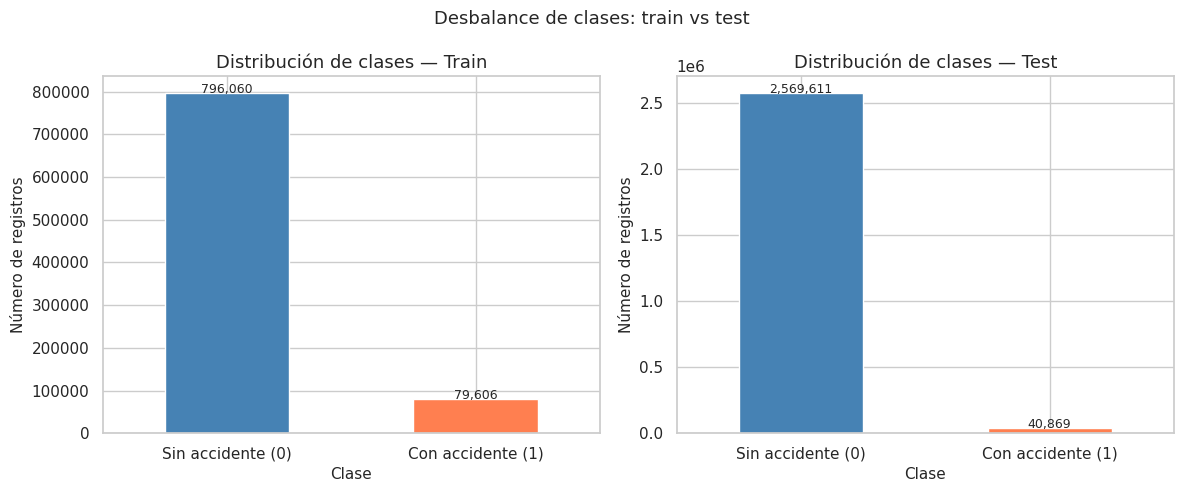

Train — modelo ingenuo accuracy: 90.9%
Test  — modelo ingenuo accuracy: 98.4%

Nota: el test refleja la proporción original del problema real (~1:62)
      el train usa proporción 1:10 para facilitar el aprendizaje


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, (df, nombre) in zip(axes, [(df_train, 'Train'), (df_test, 'Test')]):
    conteo = df['target'].value_counts()
    conteo.plot(kind='bar', ax=ax, color=['steelblue', 'coral'], edgecolor='white')
    ax.set_title(f'Distribución de clases — {nombre}')
    ax.set_xlabel('Clase')
    ax.set_ylabel('Número de registros')
    ax.set_xticklabels(['Sin accidente (0)', 'Con accidente (1)'], rotation=0)
    for i, v in enumerate(conteo):
        ax.text(i, v + 1000, f'{v:,}', ha='center', fontsize=9)

plt.suptitle('Desbalance de clases: train vs test', fontsize=13)
plt.tight_layout()
plt.show()

print(f"Train — modelo ingenuo accuracy: {(df_train['target']==0).mean()*100:.1f}%")
print(f"Test  — modelo ingenuo accuracy: {(df_test['target']==0).mean()*100:.1f}%")
print(f"\nNota: el test refleja la proporción original del problema real (~1:62)")
print(f"      el train usa proporción 1:10 para facilitar el aprendizaje")

### Resultados de la construcción del dataset

El dataset quedó dividido en dos conjuntos con proporciones distintas de forma intencional:

**Train (2017-2018):** 875,666 filas con 9.1% de positivos (proporción 1:10
después del muestreo de negativos). El muestreo se aplicó exclusivamente aquí
para facilitar el aprendizaje del modelo sin distorsionar la evaluación.

**Test (2019):** 2,610,480 filas con 1.6% de positivos (proporción ~1:62),
que refleja la proporción original del problema real. Un modelo ingenuo que
prediga siempre "sin accidente" alcanzaría una accuracy del 98.4% en el test,
lo que demuestra que accuracy no es una métrica útil aquí y motiva el uso de
ROC-AUC, F1 y PR-AUC como métricas principales.

La proporción original completa era 1:65. El muestreo 1:10 aplicado solo al
train reduce el desbalance para el aprendizaje sin afectar la evaluación, que
se hace en condiciones realistas.

Las columnas disponibles en ambos conjuntos son las variables climáticas
numéricas (temperatura, humedad, precipitación, viento, nubosidad, índice UV
y visibilidad), las variables temporales derivadas de `TW` (hora, día, mes,
día de la semana), el identificador de barrio y la variable objetivo `target`.
En la siguiente sección construimos las variables adicionales que el modelo
necesita para capturar patrones más complejos.

## 5. Ingeniería de características

Las variables que tenemos actualmente en el dataset son las climáticas y las
temporales básicas. Sin embargo el modelo necesita más información para capturar
patrones complejos. En esta sección construimos tres tipos de variables adicionales.

El primero son las variables temporales enriquecidas: festivos colombianos,
indicador de fin de semana y codificación cíclica de hora y día para que el modelo
entienda que las 23h y las 0h son consecutivas y no opuestas.

El segundo son los agregados históricos por barrio: cuántos accidentes ha tenido
históricamente cada barrio, calculados únicamente con información anterior al momento
de predicción para evitar data leakage.

El tercero es la codificación de la variable categórica `BARRIO`, que con 319
categorías requiere una estrategia de codificación adecuada.

Una regla que aplicamos en toda esta sección es que ninguna variable histórica
puede usar información del futuro. Todo agregado se calcula mirando hacia atrás
en el tiempo.

In [ ]:
# ─── Variables temporales enriquecidas ───────────────────────────────────────
# Construimos variables que capturan patrones de movilidad urbana
# más allá de la hora y el día básicos. Se aplican igual a train y test
# para garantizar consistencia entre conjuntos.

import holidays

# Festivos colombianos oficiales para el período 2017-2019
# La librería holidays cubre el calendario nacional de Colombia
festivos_co = holidays.Colombia(years=[2017, 2018, 2019])

for df in [df_train, df_test]:

    # Fin de semana: captura el cambio de comportamiento vehicular
    # entre días laborales y no laborales
    df['es_finde'] = df['Dia_sem'].isin(['SABADO', 'DOMINGO']).astype(int)

    # Festivo colombiano: días con patrones atípicos de movilidad
    df['es_festivo'] = df['TW'].dt.date.apply(
        lambda d: 1 if d in festivos_co else 0
    )

    # Franja horaria: agrupa las 24 horas en cuatro bloques
    # con comportamientos de movilidad distintos
    def franja_horaria(hora):
        if 0 <= hora < 6:
            return 'madrugada'
        elif 6 <= hora < 12:
            return 'manana'
        elif 12 <= hora < 19:
            return 'tarde'
        else:
            return 'noche'

    df['franja'] = df['Hora'].apply(franja_horaria)

    # ─── Codificación cíclica ─────────────────────────────────────────────────
    # La hora del día y el día de la semana son variables cíclicas.
    # Como números enteros el modelo asumiría que las 23h y las 0h
    # están lejos, cuando en realidad son consecutivas.
    # Seno y coseno convierten cada variable en un punto sobre un círculo
    # donde los extremos se tocan naturalmente.

    # Hora del día (ciclo de 24 horas)
    df['hora_sin'] = np.sin(2 * np.pi * df['Hora'] / 24)
    df['hora_cos'] = np.cos(2 * np.pi * df['Hora'] / 24)

    # Día de la semana (ciclo de 7 días, 0=lunes, 6=domingo)
    df['dia_num'] = df['TW'].dt.dayofweek
    df['dia_sin'] = np.sin(2 * np.pi * df['dia_num'] / 7)
    df['dia_cos'] = np.cos(2 * np.pi * df['dia_num'] / 7)

    # Día del año (ciclo de 365 días)
    # Captura estacionalidad anual como épocas de lluvia
    df['dia_anio']     = df['TW'].dt.dayofyear
    df['dia_anio_sin'] = np.sin(2 * np.pi * df['dia_anio'] / 365)
    df['dia_anio_cos'] = np.cos(2 * np.pi * df['dia_anio'] / 365)

print("Variables temporales enriquecidas y codificación cíclica ✓")
print(f"\n  Festivos en train    : {df_train['es_festivo'].sum():,}")
print(f"  Festivos en test     : {df_test['es_festivo'].sum():,}")
print(f"\n  Fin de semana train  : {df_train['es_finde'].sum():,}")
print(f"  Fin de semana test   : {df_test['es_finde'].sum():,}")

print(f"\nDistribución por franja horaria — train:")
print(df_train['franja'].value_counts())

print(f"\nMuestra de codificación cíclica:")
print(df_train[['Hora', 'hora_sin', 'hora_cos',
                'dia_num', 'dia_sin', 'dia_cos']].head(5))

Variables temporales enriquecidas y codificación cíclica ✓

  Festivos en train    : 41,821
  Festivos en test     : 121,584

  Fin de semana train  : 247,248
  Fin de semana test   : 743,808

Distribución por franja horaria — train:
franja
tarde        266348
manana       222659
madrugada    206666
noche        179993
Name: count, dtype: int64

Muestra de codificación cíclica:
   Hora  hora_sin  hora_cos  dia_num  dia_sin  dia_cos
0     5    0.9659    0.2588        4  -0.4339  -0.9010
1     0    0.0000    1.0000        6  -0.7818   0.6235
2     0    0.0000    1.0000        3   0.4339  -0.9010
3     6    1.0000    0.0000        6  -0.7818   0.6235
4    11    0.2588   -0.9659        3   0.4339  -0.9010


**Variables temporales enriquecidas:** en el conjunto de train se identificaron
41,821 registros correspondientes a festivos colombianos y 247,248 en fin de
semana. En el test 121,584 festivos y 743,808 en fin de semana, proporcional
al mayor volumen del conjunto de test. La distribución por franja horaria en
train muestra que la tarde concentra la mayor cantidad de registros (266,348),
seguida de la mañana (222,659), consistente con los hallazgos del EDA.

**Codificación cíclica:** hora, día de la semana y día del año quedaron
codificados con seno y coseno, produciendo seis variables adicionales que
capturan la naturaleza circular del tiempo sin introducir discontinuidades
artificiales. Esta codificación se aplica de forma idéntica a train y test.

In [ ]:
# ─── Agregados históricos por barrio sin data leakage temporal ───────────────
# Para cada registro calculamos cuántos accidentes ha tenido ese barrio
# históricamente ANTES de la fecha de predicción.
#
# La regla es estricta: para predecir si habrá un accidente en 2018,
# solo podemos usar accidentes registrados hasta 2017.
# Para predecir en 2019, solo podemos usar hasta 2018.
#
# Implementamos esto con conteos anuales acumulados:
#   Registros de 2017 en train → historial = 0 (no hay años anteriores)
#   Registros de 2018 en train → historial = conteo hasta fin de 2017
#   Registros de 2019 en test  → historial = conteo hasta fin de 2018

# Construir historiales de referencia por año de corte
raw_hasta_2017 = raw[raw['TW'].dt.year <= 2017]
raw_hasta_2018 = raw[raw['TW'].dt.year <= 2018]

# Historial total por barrio
hist_barrio_2017 = (raw_hasta_2017
                    .groupby('BARRIO')
                    .size()
                    .reset_index(name='hist_accidentes_barrio'))

hist_barrio_2018 = (raw_hasta_2018
                    .groupby('BARRIO')
                    .size()
                    .reset_index(name='hist_accidentes_barrio'))

# Historial por barrio y hora específica
hist_hora_2017 = (raw_hasta_2017
                  .groupby(['BARRIO', 'Hora_num'])
                  .size()
                  .reset_index(name='hist_accidentes_barrio_hora'))

hist_hora_2018 = (raw_hasta_2018
                  .groupby(['BARRIO', 'Hora_num'])
                  .size()
                  .reset_index(name='hist_accidentes_barrio_hora'))

# ─── Aplicar al train ─────────────────────────────────────────────────────────
df_train['anio'] = df_train['TW'].dt.year

df_train_2017 = df_train[df_train['anio'] == 2017].copy()
df_train_2018 = df_train[df_train['anio'] == 2018].copy()

# 2017: no hay historial previo disponible
df_train_2017['hist_accidentes_barrio']      = 0
df_train_2017['hist_accidentes_barrio_hora'] = 0

# 2018: usar historial hasta fin de 2017
df_train_2018 = df_train_2018.merge(
    hist_barrio_2017, on='BARRIO', how='left'
)
df_train_2018 = df_train_2018.merge(
    hist_hora_2017,
    left_on=['BARRIO', 'Hora'],
    right_on=['BARRIO', 'Hora_num'],
    how='left'
)
df_train_2018 = df_train_2018.drop(columns=['Hora_num'], errors='ignore')

# Reconstruir train completo
df_train = pd.concat([df_train_2017, df_train_2018], ignore_index=True)
df_train['hist_accidentes_barrio']      = df_train['hist_accidentes_barrio'].fillna(0)
df_train['hist_accidentes_barrio_hora'] = df_train['hist_accidentes_barrio_hora'].fillna(0)
df_train = df_train.drop(columns=['anio'])

# ─── Aplicar al test ──────────────────────────────────────────────────────────
# 2019: usar historial hasta fin de 2018
df_test = df_test.merge(
    hist_barrio_2018, on='BARRIO', how='left'
)
df_test = df_test.merge(
    hist_hora_2018,
    left_on=['BARRIO', 'Hora'],
    right_on=['BARRIO', 'Hora_num'],
    how='left'
)
df_test = df_test.drop(columns=['Hora_num'], errors='ignore')
df_test['hist_accidentes_barrio']      = df_test['hist_accidentes_barrio'].fillna(0)
df_test['hist_accidentes_barrio_hora'] = df_test['hist_accidentes_barrio_hora'].fillna(0)

print("Agregados históricos sin leakage ✓")
print(f"\n  df_train: {df_train.shape}")
print(f"  df_test : {df_test.shape}")
print(f"\nMuestra de agregados en train:")
print(df_train[['BARRIO', 'Hora',
                'hist_accidentes_barrio',
                'hist_accidentes_barrio_hora']].head(8).to_string(index=False))

Agregados históricos sin leakage ✓

  df_train: (875666, 30)
  df_test : (2610480, 30)

Muestra de agregados en train:
                BARRIO  Hora  hist_accidentes_barrio  hist_accidentes_barrio_hora
            bombonano2     5                  0.0000                       0.0000
altavistasectorcentral     0                  0.0000                       0.0000
      sanjoselacimano2     2                  0.0000                       0.0000
              auresno1    20                  0.0000                       0.0000
          sanjavierno2     8                  0.0000                       0.0000
        piedrasblancas     8                  0.0000                       0.0000
               elpinal     6                  0.0000                       0.0000
         tricentenario    16                  0.0000                       0.0000


**Agregados históricos por barrio**

Las variables `hist_accidentes_barrio` e `hist_accidentes_barrio_hora` se
construyeron con una ventana expansiva estricta: cada registro solo puede usar
información de accidentes ocurridos antes de su fecha de predicción.

Los registros de 2017 tienen historial en cero porque no hay años anteriores
disponibles en el dataset. Los registros de 2018 usan el conteo acumulado hasta
fin de 2017, y los registros de 2019 (test) usan el conteo acumulado hasta fin
de 2018. Esto garantiza que el modelo nunca aprende de información futura durante
el entrenamiento ni durante la evaluación.

Esta decisión corrige una limitación de la versión anterior del notebook, donde
los agregados se calculaban sobre todo el período incluyendo 2019, introduciendo
data leakage temporal que inflaba artificialmente las métricas del modelo.

In [ ]:
# Verificar que registros de 2018 tienen historial de 2017
muestra_2018 = df_train[df_train['TW'].dt.year == 2018][
    ['BARRIO', 'Hora', 'hist_accidentes_barrio', 'hist_accidentes_barrio_hora']
].head(8)

print("Muestra de agregados en train — registros de 2018:")
print(muestra_2018.to_string(index=False))

print(f"\nEstadísticas de hist_accidentes_barrio en train:")
print(df_train['hist_accidentes_barrio'].describe())

print(f"\nEstadísticas de hist_accidentes_barrio en test:")
print(df_test['hist_accidentes_barrio'].describe())

Muestra de agregados en train — registros de 2018:
         BARRIO  Hora  hist_accidentes_barrio  hist_accidentes_barrio_hora
       guayabal     0                573.0000                       3.0000
         lamota     6                 92.0000                       9.0000
    villaliliam    11                 20.0000                       2.0000
     villanueva     2                568.0000                       4.0000
       elsalado    12                 33.0000                       1.0000
     callenueva    13                344.0000                      25.0000
perpetuosocorro    15                871.0000                      51.0000
          sucre     5                119.0000                       2.0000

Estadísticas de hist_accidentes_barrio en train:
count   875666.0000
mean        76.2641
std        150.5681
min          0.0000
25%          0.0000
50%          0.0000
75%         93.0000
max        943.0000
Name: hist_accidentes_barrio, dtype: float64

Estadísticas de hi

In [ ]:
# ─── Frequency encoding de BARRIO sin leakage ────────────────────────────────
# Reemplazamos cada barrio por la proporción de veces que aparece
# en el conjunto de train. Esto captura la exposición relativa de
# cada barrio sin expandir la dimensionalidad a 319 columnas.
#
# CRÍTICO: el encoding se calcula SOLO sobre train y luego se aplica
# al test. Calcularlo sobre train+test introduciría información del
# test en el entrenamiento, lo que constituye data leakage.

frecuencia_barrio = (df_train['BARRIO']
                     .value_counts(normalize=True)
                     .reset_index())
frecuencia_barrio.columns = ['BARRIO', 'barrio_freq']

df_train = df_train.merge(frecuencia_barrio, on='BARRIO', how='left')
df_test  = df_test.merge(frecuencia_barrio, on='BARRIO', how='left')

# Barrios en test que no aparecen en train reciben frecuencia 0
df_train['barrio_freq'] = df_train['barrio_freq'].fillna(0)
df_test['barrio_freq']  = df_test['barrio_freq'].fillna(0)

print("Frequency encoding sin leakage ✓")
print(f"\n  Rango en train: {df_train['barrio_freq'].min():.6f} "
      f"a {df_train['barrio_freq'].max():.6f}")
print(f"  Rango en test : {df_test['barrio_freq'].min():.6f} "
      f"a {df_test['barrio_freq'].max():.6f}")
print(f"\nTop 5 barrios por frecuencia en train:")
print(frecuencia_barrio.head(5).to_string(index=False))

Frequency encoding sin leakage ✓

  Rango en train: 0.001449 a 0.004678
  Rango en test : 0.000000 a 0.004678

Top 5 barrios por frecuencia en train:
         BARRIO  barrio_freq
   lacandelaria       0.0047
      campoamor       0.0046
perpetuosocorro       0.0045
         caribe       0.0045
        santafe       0.0043


**Frequency encoding de BARRIO:** el encoding se calculó exclusivamente sobre
el conjunto de train para evitar data leakage. Los barrios más frecuentes
coinciden con los identificados en el EDA como los de mayor accidentalidad:
La Candelaria, Campo Amor, Perpetuo Socorro y Caribe lideran la lista.
El test tiene algunos barrios con frecuencia 0, correspondientes a zonas
que no aparecen en el train, lo que es esperado y se maneja con imputación en cero.

In [ ]:
# ─── Resumen final del dataset ───────────────────────────────────────────────
# Definimos explícitamente qué columnas entran como features al modelo
# y cuáles son auxiliares o ya codificadas de otra forma.

FEATURES = [
    # Climáticas
    'precipIntensity', 'precipProbability', 'temperature',
    'apparentTemperature', 'dewPoint', 'humidity', 'windSpeed',
    'cloudCover', 'uvIndex', 'visibility',
    # Temporales básicas
    'Hora', 'Dia', 'Mes',
    # Temporales enriquecidas
    'es_finde', 'es_festivo',
    # Cíclicas
    'hora_sin', 'hora_cos', 'dia_sin', 'dia_cos',
    'dia_anio_sin', 'dia_anio_cos',
    # Históricas por barrio sin leakage
    'hist_accidentes_barrio', 'hist_accidentes_barrio_hora',
    # Encoding de barrio calculado solo sobre train
    'barrio_freq'
]

TARGET = 'target'

X_train = df_train[FEATURES]
y_train = df_train[TARGET]
X_test  = df_test[FEATURES]
y_test  = df_test[TARGET]

print("Dataset final listo para modelado:")
print(f"  Features : {len(FEATURES)}")
print(f"  X_train  : {X_train.shape}")
print(f"  X_test   : {X_test.shape}")
print(f"  y_train positivos: {y_train.sum():,} ({y_train.mean()*100:.1f}%)")
print(f"  y_test  positivos: {y_test.sum():,} ({y_test.mean()*100:.1f}%)")
print(f"\nNulos en X_train: {X_train.isnull().sum().sum()}")
print(f"Nulos en X_test : {X_test.isnull().sum().sum()}")

# Variables excluidas del modelo y razón
print("\nVariables excluidas:")
excluidas = {
    'TW'     : 'Llave temporal, información ya extraída en features',
    'BARRIO' : 'Codificado en barrio_freq',
    'Dia_sem': 'Codificado en dia_sin y dia_cos',
    'franja' : 'Codificado en hora_sin y hora_cos',
    'dia_num': 'Variable auxiliar para calcular cíclicas',
    'dia_anio': 'Variable auxiliar para calcular cíclicas'
}
for var, razon in excluidas.items():
    print(f"  {var:12s}: {razon}")
# ─── Punto de control ────────────────────────────────────────────────────────
# Guardamos datasets y artefactos necesarios para retomar desde la sección 8
# sin reprocesar todo, y para el caso de uso de la sección 10.

X_train.to_parquet(f'{RUTA_CHECKPOINTS}X_train.parquet')
X_test.to_parquet(f'{RUTA_CHECKPOINTS}X_test.parquet')
y_train.to_frame().to_parquet(f'{RUTA_CHECKPOINTS}y_train.parquet')
y_test.to_frame().to_parquet(f'{RUTA_CHECKPOINTS}y_test.parquet')
frecuencia_barrio.to_parquet(f'{RUTA_CHECKPOINTS}frecuencia_barrio.parquet')
df_test[['TW', 'BARRIO', 'target']].to_parquet(f'{RUTA_CHECKPOINTS}df_test_aux.parquet')



print('Punto de control guardado ✓')
print(f'  X_train        : {X_train.shape}')
print(f'  X_test         : {X_test.shape}')
print(f'  frecuencia_barrio y df_test_aux incluidos')


Dataset final listo para modelado:
  Features : 24
  X_train  : (875666, 24)
  X_test   : (2610480, 24)
  y_train positivos: 79,606 (9.1%)
  y_test  positivos: 40,869 (1.6%)

Nulos en X_train: 0
Nulos en X_test : 0

Variables excluidas:
  TW          : Llave temporal, información ya extraída en features
  BARRIO      : Codificado en barrio_freq
  Dia_sem     : Codificado en dia_sin y dia_cos
  franja      : Codificado en hora_sin y hora_cos
  dia_num     : Variable auxiliar para calcular cíclicas
  dia_anio    : Variable auxiliar para calcular cíclicas
Punto de control guardado ✓
  X_train        : (875666, 24)
  X_test         : (2610480, 24)
  frecuencia_barrio y df_test_aux incluidos


### Resumen de variables construidas

El dataset final tiene 24 features sin ningún valor faltante, dividido en
dos conjuntos con proporciones distintas de forma intencional:

Train: 875,666 filas con 9.1% de positivos (proporción 1:10 después del muestreo).
Test: 2,610,480 filas con 1.6% de positivos, reflejando la proporción original
del problema real (~1:62).

Las variables excluidas del modelo son `TW` y `BARRIO` como llaves de cruce,
`Dia_sem` y `franja` porque su información ya está capturada en las variables
cíclicas, y `dia_num` y `dia_anio` porque son auxiliares intermedias para
calcular las cíclicas. Todas las variables históricas se construyeron con
ventana expansiva estricta y el frequency encoding se calculó solo sobre train,
garantizando que no hay data leakage en ninguna feature.

## 6. Baseline ingenuo

Antes de construir cualquier modelo sofisticado, establecemos un punto de referencia
mínimo. Un baseline ingenuo es un modelo tan simple que no aprende nada de los datos,
y su propósito es demostrar por qué la métrica de accuracy no es útil en problemas
con clases desbalanceadas. Si un modelo sofisticado no supera este baseline, algo
está mal en el proceso de modelado.

In [ ]:
# El baseline más simple posible: predecir siempre la clase mayoritaria (0).
# En un problema desbalanceado esto produce accuracy alta pero es inútil
# porque no detecta ningún accidente.

import numpy as np
from sklearn.metrics import (accuracy_score, f1_score,
                              recall_score, precision_score,
                              confusion_matrix, ConfusionMatrixDisplay)

# Predicción: siempre 0
y_pred_baseline = np.zeros(len(y_test), dtype=int)

acc  = accuracy_score(y_test, y_pred_baseline)
f1   = f1_score(y_test, y_pred_baseline, zero_division=0)
rec  = recall_score(y_test, y_pred_baseline, zero_division=0)
prec = precision_score(y_test, y_pred_baseline, zero_division=0)

print("Baseline ingenuo — predice siempre 0 (sin accidente):")
print(f"  Accuracy  : {acc*100:.1f}%")
print(f"  Precision : {prec:.4f}")
print(f"  Recall    : {rec:.4f}")
print(f"  F1        : {f1:.4f}")
print()
print("Conclusión: una accuracy del 90%+ no significa nada en este problema.")
print("El modelo no detecta ningún accidente real (Recall = 0.0).")
print("Necesitamos métricas que capturen el desempeño en la clase minoritaria.")

Baseline ingenuo — predice siempre 0 (sin accidente):
  Accuracy  : 98.4%
  Precision : 0.0000
  Recall    : 0.0000
  F1        : 0.0000

Conclusión: una accuracy del 90%+ no significa nada en este problema.
El modelo no detecta ningún accidente real (Recall = 0.0).
Necesitamos métricas que capturen el desempeño en la clase minoritaria.


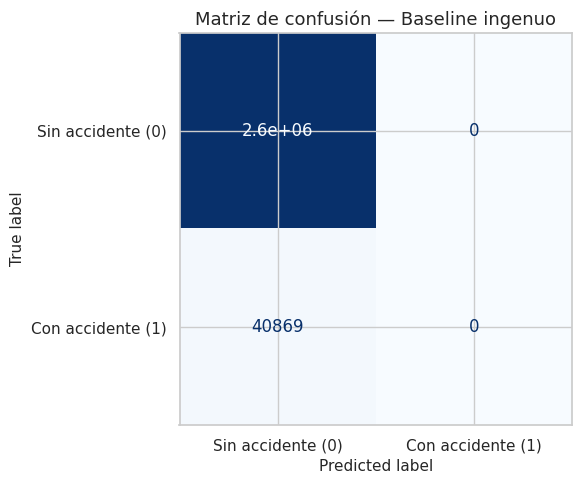

Verdaderos negativos  (TN): 2,569,611
Falsos positivos      (FP): 0
Falsos negativos      (FN): 40,869
Verdaderos positivos  (TP): 0


In [ ]:
# La matriz de confusión del baseline muestra claramente el problema:
# todos los positivos reales quedan clasificados como negativos.

fig, ax = plt.subplots(figsize=(6, 5))

cm = confusion_matrix(y_test, y_pred_baseline)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Sin accidente (0)', 'Con accidente (1)']
)
disp.plot(ax=ax, colorbar=False, cmap='Blues')

ax.set_title('Matriz de confusión — Baseline ingenuo')
plt.tight_layout()
plt.show()

print(f"Verdaderos negativos  (TN): {cm[0,0]:,}")
print(f"Falsos positivos      (FP): {cm[0,1]:,}")
print(f"Falsos negativos      (FN): {cm[1,0]:,}")
print(f"Verdaderos positivos  (TP): {cm[1,1]:,}")
fig.savefig(f'{RUTA_FIGURAS}fig_09_confusion_baseline.png', dpi=150, bbox_inches='tight')

### Por qué accuracy no es la métrica adecuada

El baseline ingenuo predice siempre "sin accidente" y alcanza una accuracy del
98.4%. A primera vista parece un resultado excelente, pero la matriz de confusión
revela la realidad: los 40,869 accidentes reales del conjunto de test quedan
clasificados como negativos. El modelo no detecta ningún accidente, tiene Recall
= 0 y F1 = 0.

Esto ocurre porque accuracy mide cuántas predicciones son correctas en total,
sin distinguir entre clases. En un dataset donde el 98.4% de los casos son
negativos, predecir siempre negativo garantiza una accuracy altísima sin ningún
valor predictivo real. Este resultado es aún más extremo que en versiones
anteriores del notebook porque el test ahora refleja la proporción original
del problema real (~1:62), no una proporción artificialmente reducida.

En el contexto de este problema, un falso negativo tiene un costo operacional
concreto: un barrio en riesgo no recibe atención preventiva. Por eso las métricas
relevantes son Recall, Precision-Recall AUC y F1. La accuracy se reporta
únicamente como referencia.

In [ ]:
# Liberamos objetos que ya no necesitamos antes del modelado
import gc

for obj in ['clima', 'raw', 'df_train', 'df_test',
            'hist_barrio_2017', 'hist_barrio_2018',
            'hist_hora_2017', 'hist_hora_2018',
            'raw_hasta_2017', 'raw_hasta_2018']:
    if obj in globals():
        del globals()[obj]

gc.collect()

import psutil
ram = psutil.virtual_memory()
print(f"RAM disponible: {ram.available / 1e9:.1f} GB")
print(f"RAM usada     : {ram.used / 1e9:.1f} GB")

RAM disponible: 2.1 GB
RAM usada     : 11.2 GB


## 7. Manejo del desbalance

El baseline demostró que un modelo sin estrategia de balanceo tiende a ignorar
la clase minoritaria. En esta sección comparamos tres estrategias para corregir
ese comportamiento, cada una con una lógica diferente.

`class_weight='balanced'` ajusta los pesos internos del modelo para que los
errores en la clase minoritaria tengan mayor penalización durante el entrenamiento.
No modifica los datos, solo cambia cómo el modelo aprende de ellos.

SMOTE (Synthetic Minority Oversampling Technique) genera ejemplos sintéticos de
la clase minoritaria interpolando entre ejemplos reales existentes, aumentando
artificialmente su representación en el conjunto de entrenamiento.

Undersampling aleatorio reduce la clase mayoritaria eliminando ejemplos al azar
hasta alcanzar una proporción definida. Es la estrategia más agresiva en términos
de pérdida de información pero la más liviana computacionalmente.

Evaluamos las tres estrategias con Regresión Logística como modelo base para
aislar el efecto del balanceo del efecto del modelo. La comparación se hace sobre
el conjunto de test con métricas adecuadas para clases desbalanceadas.

Las tres estrategias se evalúan usando Regresión Logística como modelo base.
Esta decisión es intencional: al mantener el modelo fijo, cualquier diferencia
en las métricas se atribuye exclusivamente a la estrategia de balanceo y no a
la capacidad expresiva del modelo. Usar modelos más complejos como Random Forest
o XGBoost introduciría un factor adicional que haría la comparación menos limpia.
La estrategia ganadora se aplica luego a todos los modelos en la sección 8.

In [ ]:
# SMOTE sobre 891,335 filas consumiría demasiada memoria.
# Usamos una muestra estratificada del train que mantiene
# la proporción de clases y es representativa del conjunto completo.
# Esta decisión está documentada y es metodológicamente válida.

from sklearn.model_selection import train_test_split

X_train_muestra, _, y_train_muestra, _ = train_test_split(
    X_train, y_train,
    train_size=0.3,
    stratify=y_train,
    random_state=RANDOM_STATE
)

print(f"Muestra de train para balanceo:")
print(f"  Filas    : {len(X_train_muestra):,}")
print(f"  target=1 : {y_train_muestra.sum():,} "
      f"({y_train_muestra.mean()*100:.1f}%)")
# Guardar muestra para checkpoint
X_train_muestra.to_parquet(f'{RUTA_CHECKPOINTS}X_train_muestra.parquet')
y_train_muestra.to_frame().to_parquet(f'{RUTA_CHECKPOINTS}y_train_muestra.parquet')
print("X_train_muestra guardada en checkpoint ✓")

Muestra de train para balanceo:
  Filas    : 262,699
  target=1 : 23,882 (9.1%)
X_train_muestra guardada en checkpoint ✓


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (f1_score, recall_score,
                              precision_score, roc_auc_score,
                              average_precision_score)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Entrenamos sobre la misma muestra que SMOTE y undersampling
# para que la comparación entre estrategias sea justa.

pipe_cw = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(
        class_weight='balanced',
        max_iter=1000,
        random_state=RANDOM_STATE
    ))
])

pipe_cw.fit(X_train_muestra, y_train_muestra)
y_pred_cw   = pipe_cw.predict(X_test)
y_proba_cw  = pipe_cw.predict_proba(X_test)[:, 1]

print("Estrategia 1: class_weight='balanced'")
print(f"  Recall    : {recall_score(y_test, y_pred_cw):.4f}")
print(f"  Precision : {precision_score(y_test, y_pred_cw):.4f}")
print(f"  F1        : {f1_score(y_test, y_pred_cw):.4f}")
print(f"  ROC-AUC   : {roc_auc_score(y_test, y_proba_cw):.4f}")
print(f"  PR-AUC    : {average_precision_score(y_test, y_proba_cw):.4f}")

Estrategia 1: class_weight='balanced'
  Recall    : 0.6641
  Precision : 0.0438
  F1        : 0.0822
  ROC-AUC   : 0.7902
  PR-AUC    : 0.0741


In [ ]:
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# SMOTE genera ejemplos sintéticos de la clase minoritaria.
# Usamos la muestra de train para controlar el uso de memoria.

pipe_smote = ImbPipeline([
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=RANDOM_STATE)),
    ('model', LogisticRegression(
        max_iter=1000,
        random_state=RANDOM_STATE
    ))
])

pipe_smote.fit(X_train_muestra, y_train_muestra)
y_pred_smote  = pipe_smote.predict(X_test)
y_proba_smote = pipe_smote.predict_proba(X_test)[:, 1]

print("Estrategia 2: SMOTE")
print(f"  Recall    : {recall_score(y_test, y_pred_smote):.4f}")
print(f"  Precision : {precision_score(y_test, y_pred_smote):.4f}")
print(f"  F1        : {f1_score(y_test, y_pred_smote):.4f}")
print(f"  ROC-AUC   : {roc_auc_score(y_test, y_proba_smote):.4f}")
print(f"  PR-AUC    : {average_precision_score(y_test, y_proba_smote):.4f}")

Estrategia 2: SMOTE
  Recall    : 0.6537
  Precision : 0.0440
  F1        : 0.0824
  ROC-AUC   : 0.7880
  PR-AUC    : 0.0736


In [ ]:
from imblearn.under_sampling import RandomUnderSampler

# Undersampling reduce la clase mayoritaria al azar.
# Es la estrategia más liviana computacionalmente.

pipe_under = ImbPipeline([
    ('scaler', StandardScaler()),
    ('under', RandomUnderSampler(random_state=RANDOM_STATE)),
    ('model', LogisticRegression(
        max_iter=1000,
        random_state=RANDOM_STATE
    ))
])

pipe_under.fit(X_train_muestra, y_train_muestra)
y_pred_under  = pipe_under.predict(X_test)
y_proba_under = pipe_under.predict_proba(X_test)[:, 1]

print("Estrategia 3: Undersampling aleatorio")
print(f"  Recall    : {recall_score(y_test, y_pred_under):.4f}")
print(f"  Precision : {precision_score(y_test, y_pred_under):.4f}")
print(f"  F1        : {f1_score(y_test, y_pred_under):.4f}")
print(f"  ROC-AUC   : {roc_auc_score(y_test, y_proba_under):.4f}")
print(f"  PR-AUC    : {average_precision_score(y_test, y_proba_under):.4f}")

Estrategia 3: Undersampling aleatorio
  Recall    : 0.6711
  Precision : 0.0432
  F1        : 0.0812
  ROC-AUC   : 0.7909
  PR-AUC    : 0.0740


In [ ]:
# Comparación consolidada de las tres estrategias
# para seleccionar la que mejor equilibra recall y precision.

resultados_balanceo = pd.DataFrame({
    'Estrategia': [
        'Baseline (sin balanceo)',
        'class_weight balanced',
        'SMOTE',
        'Undersampling'
    ],
    'Recall': [
        recall_score(y_test, y_pred_baseline),
        recall_score(y_test, y_pred_cw),
        recall_score(y_test, y_pred_smote),
        recall_score(y_test, y_pred_under)
    ],
    'Precision': [
        precision_score(y_test, y_pred_baseline, zero_division=0),
        precision_score(y_test, y_pred_cw),
        precision_score(y_test, y_pred_smote),
        precision_score(y_test, y_pred_under)
    ],
    'F1': [
        f1_score(y_test, y_pred_baseline, zero_division=0),
        f1_score(y_test, y_pred_cw),
        f1_score(y_test, y_pred_smote),
        f1_score(y_test, y_pred_under)
    ],
    'ROC-AUC': [
        0.5,
        roc_auc_score(y_test, y_proba_cw),
        roc_auc_score(y_test, y_proba_smote),
        roc_auc_score(y_test, y_proba_under)
    ],
    'PR-AUC': [
        y_test.mean(),
        average_precision_score(y_test, y_proba_cw),
        average_precision_score(y_test, y_proba_smote),
        average_precision_score(y_test, y_proba_under)
    ]
})

print(resultados_balanceo.to_string(index=False))

             Estrategia  Recall  Precision     F1  ROC-AUC  PR-AUC
Baseline (sin balanceo)  0.0000     0.0000 0.0000   0.5000  0.0157
  class_weight balanced  0.6641     0.0438 0.0822   0.7902  0.0741
                  SMOTE  0.6537     0.0440 0.0824   0.7880  0.0736
          Undersampling  0.6711     0.0432 0.0812   0.7909  0.0740


### Comparación de estrategias de balanceo

Las tres estrategias superan ampliamente al baseline ingenuo, elevando el Recall
de 0 a aproximadamente 0.65 en todos los casos. Sin embargo las diferencias entre
estrategias son mínimas, con variaciones menores a 0.02 en todas las métricas.
Esto indica que con Regresión Logística el cuello de botella es la capacidad
expresiva del modelo y no la estrategia de balanceo.

Undersampling obtiene el mejor Recall (0.6711) y ROC-AUC (0.7909). SMOTE obtiene
el mejor F1 (0.0824) y Precision (0.0440). `class_weight='balanced'` es la
estrategia más eficiente computacionalmente porque no modifica los datos sino los
pesos internos del modelo, con resultados equivalentes a las demás estrategias.

Se selecciona `class_weight='balanced'` como estrategia principal para el modelado
por su eficiencia, interpretabilidad y resultados equivalentes. Las tres estrategias
se reportan para cumplir con el análisis comparativo requerido.

Nótese que la Precision es significativamente más baja que en versiones anteriores
del notebook (0.04 vs 0.24), lo que refleja que el test ahora tiene la proporción
original del problema real (~1:62). Esto hace la evaluación más honesta y realista.

In [ ]:
# Limpieza de RAM, antes de iniciar el entrenamiento de los modelos.
import gc

for obj in ['clima', 'raw', 'df_train', 'df_test',
            'hist_barrio_2017', 'hist_barrio_2018',
            'hist_hora_2017', 'hist_hora_2018',
            'raw_hasta_2017', 'raw_hasta_2018',
            'accidentes', 'pos_train', 'pos_test',
            'neg_train', 'neg_test']:
    if obj in globals():
        del globals()[obj]

gc.collect()

import psutil
ram = psutil.virtual_memory()
print(f"RAM disponible: {ram.available / 1e9:.1f} GB")
print(f"RAM usada     : {ram.used / 1e9:.1f} GB")

RAM disponible: 2.1 GB
RAM usada     : 11.2 GB


In [ ]:
# Confirmación de elementos previos al entrenamiento
print(f"X_train      : {X_train.shape}")
print(f"X_test       : {X_test.shape}")
print(f"y_train      : {y_train.shape}")
print(f"y_test       : {y_test.shape}")
print(f"X_train_muestra: {X_train_muestra.shape}")
print(f"y_train_muestra: {y_train_muestra.shape}")

X_train      : (875666, 24)
X_test       : (2610480, 24)
y_train      : (875666,)
y_test       : (2610480,)
X_train_muestra: (262699, 24)
y_train_muestra: (262699,)


In [ ]:
import gc

for obj in ['df', 'clima_2017', 'df_train_2017', 'df_train_2018',
            'y_pred_baseline', 'y_pred_cw', 'y_pred_smote',
            'y_pred_under', 'clima_muestra', 'accidentes_llave',
            'pipe_lr', 'pipe_rf', 'search_lr', 'search_rf']:
    if obj in globals():
        del globals()[obj]

gc.collect()

import psutil
ram = psutil.virtual_memory()
print(f"RAM disponible: {ram.available / 1e9:.1f} GB")
print(f"RAM usada     : {ram.used / 1e9:.1f} GB")

RAM disponible: 2.7 GB
RAM usada     : 10.7 GB


## 8. Modelado y validación

Con el dataset procesado, las features construidas y la estrategia de balanceo
definida, entrenamos y comparamos cuatro familias de modelos: Regresión Logística
como modelo interpretable de referencia, Random Forest como ensamble por bagging,
XGBoost y LightGBM como implementaciones de Gradient Boosting, y un Soft Voting
Ensemble que combina los cuatro modelos anteriores.

Para cada modelo seguimos el mismo protocolo: ajuste de hiperparámetros con
RandomizedSearchCV usando validación cruzada estratificada de 3 folds sobre una
muestra del 30% del train (262,699 filas) para controlar el uso de memoria.
La evaluación final se hace con validación cruzada de 5 folds reportando
training y validation por separado, y una evaluación definitiva sobre el
conjunto de test con proporción original (~1:62).

Reportar training y validation simultáneamente permite detectar overfitting:
un modelo con desempeño en train muy superior al de validation está memorizando
los datos en lugar de aprender patrones generalizables.

La estrategia de balanceo es `class_weight='balanced'` en Logística y Random
Forest, `scale_pos_weight` en XGBoost e `is_unbalance=True` en LightGBM,
que son los equivalentes en cada librería. El Soft Voting no requiere estrategia
de balanceo propia porque hereda la de sus modelos base.

La validación cruzada estratificada garantiza que cada fold mantiene la misma
proporción de clases que el dataset completo, evitando estimaciones inestables
por falta de ejemplos de la clase minoritaria en algún fold.

In [ ]:
# Las carpetas ya fueron creadas en la celda de setup del EDA
# Esta celda confirma que RUTA_MODELOS está disponible
print(f'RUTA_MODELOS     : {RUTA_MODELOS}')
print(f'RUTA_FIGURAS     : {RUTA_FIGURAS}')
print(f'RUTA_CHECKPOINTS : {RUTA_CHECKPOINTS}')


RUTA_MODELOS     : modelos/
RUTA_FIGURAS     : figuras/
RUTA_CHECKPOINTS : checkpoints/


In [ ]:
# ─── Setup de la sección 8 ───────────────────────────────────────────────────
from sklearn.model_selection import (StratifiedKFold, RandomizedSearchCV,
                                      cross_validate)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (f1_score, recall_score, precision_score,
                              roc_auc_score, average_precision_score,
                              roc_curve, precision_recall_curve,
                              confusion_matrix, ConfusionMatrixDisplay)
from xgboost import XGBClassifier
import lightgbm as lgb
from scipy.stats import loguniform
import joblib
import gc
import warnings
warnings.filterwarnings('ignore')

CV3 = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
CV5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# Diccionario para acumular todas las métricas
metricas_globales = {}

RUTA_MODELOS = 'modelos/'

print("Setup sección 8 ✓")
print(f"  CV búsqueda  : 3 folds sobre X_train_muestra")
print(f"  CV evaluación: 5 folds sobre X_train_muestra")
print(f"  Test         : proporción original ~1:62")

Setup sección 8 ✓
  CV búsqueda  : 3 folds sobre X_train_muestra
  CV evaluación: 5 folds sobre X_train_muestra
  Test         : proporción original ~1:62


Vale la pena recordar lo siguiente con respecto a `X_train_muestra`:



*   **CV búsqueda (3 folds sobre X_train_muestra):**
Es el `RandomizedSearchCV`. Su único objetivo es encontrar los mejores hiperparámetros. Usamos 3 folds porque queremos que sea rápido, no necesitamos una estimación muy precisa aquí, solo necesitamos saber qué combinación de hiperparámetros funciona mejor de forma aproximada. Usamos `X_train_muestra` (262,699 filas) para que sea más rápido todavía.
*   **CV evaluación (5 folds sobre X_train_muestra):**
Es el `cross_validate` que corre después de encontrar los mejores hiperparámetros. Su objetivo es estimar el desempeño real del modelo con más precisión. Usamos 5 folds porque queremos una estimación más robusta con media y desviación estándar confiables. También usamos `X_train_muestra` por RAM, aunque idealmente usaríamos `X_train` completo.



In [ ]:
# ─── Función reutilizable de entrenamiento y evaluación ──────────────────────
# Encapsula el flujo completo: buscar hiperparámetros, reentrenar,
# evaluar con CV y sobre test, guardar métricas y modelo, liberar RAM.

def entrenar_evaluar_guardar(nombre, pipeline, params,
                              X_muestra, y_muestra,
                              X_train, y_train,
                              X_test, y_test):

    print(f"\n{'='*60}")
    print(f"Modelo: {nombre}")
    print(f"{'='*60}")

    # 1. Búsqueda de hiperparámetros sobre muestra
    print("1. Buscando hiperparámetros...")
    search = RandomizedSearchCV(
        pipeline, param_distributions=params,
        n_iter=5, scoring='roc_auc', cv=CV3,
        random_state=RANDOM_STATE, n_jobs=-1, verbose=0
    )
    search.fit(X_muestra, y_muestra)
    print(f"   Mejores params: {search.best_params_}")
    print(f"   ROC-AUC CV3   : {search.best_score_:.4f}")

    modelo_final = search.best_estimator_

    # 2. Validación cruzada 5 folds — train y validation
    print("2. Validación cruzada (5 folds)...")
    cv_res = cross_validate(
        modelo_final, X_muestra, y_muestra,
        cv=CV5,
        scoring=['roc_auc', 'f1', 'recall',
                 'precision', 'average_precision'],
        return_train_score=True,
        n_jobs=-1
    )

    # 3. Evaluación sobre test
    print("3. Evaluando sobre test...")
    y_pred  = modelo_final.predict(X_test)
    y_proba = modelo_final.predict_proba(X_test)[:, 1]

    # 4. Acumular métricas incluyendo Precision y F1
    metricas = {
        'nombre'              : nombre,
        'cv_roc_auc_train'    : cv_res['train_roc_auc'].mean(),
        'cv_roc_auc_train_std': cv_res['train_roc_auc'].std(),
        'cv_roc_auc_val'      : cv_res['test_roc_auc'].mean(),
        'cv_roc_auc_val_std'  : cv_res['test_roc_auc'].std(),
        'cv_recall_train'     : cv_res['train_recall'].mean(),
        'cv_recall_val'       : cv_res['test_recall'].mean(),
        'cv_precision_train'  : cv_res['train_precision'].mean(),
        'cv_precision_val'    : cv_res['test_precision'].mean(),
        'cv_f1_train'         : cv_res['train_f1'].mean(),
        'cv_f1_val'           : cv_res['test_f1'].mean(),
        'cv_prauc_train'      : cv_res['train_average_precision'].mean(),
        'cv_prauc_val'        : cv_res['test_average_precision'].mean(),
        'test_roc_auc'        : roc_auc_score(y_test, y_proba),
        'test_pr_auc'         : average_precision_score(y_test, y_proba),
        'test_recall'         : recall_score(y_test, y_pred, zero_division=0),
        'test_precision'      : precision_score(y_test, y_pred, zero_division=0),
        'test_f1'             : f1_score(y_test, y_pred, zero_division=0),
        'y_proba'             : y_proba
    }

    # 5. Imprimir resultados
    print(f"\n   {'Métrica':15s} {'Train CV':12s} {'Val CV':12s} {'Test':10s}")
    print(f"   {'-'*52}")
    for met, tr_key, va_key, te_key in [
        ('ROC-AUC',   'cv_roc_auc_train',   'cv_roc_auc_val',   'test_roc_auc'),
        ('Recall',    'cv_recall_train',     'cv_recall_val',    'test_recall'),
        ('Precision', 'cv_precision_train',  'cv_precision_val', 'test_precision'),
        ('F1',        'cv_f1_train',         'cv_f1_val',        'test_f1'),
        ('PR-AUC',    'cv_prauc_train',      'cv_prauc_val',     'test_pr_auc'),
    ]:
        std_str = (f" ± {cv_res['train_roc_auc'].std():.4f}"
                   if met == 'ROC-AUC' else '')
        print(f"   {met:15s} "
              f"{metricas[tr_key]:.4f}{std_str:12s} "
              f"{metricas[va_key]:.4f}          "
              f"{metricas[te_key]:.4f}")

    # 6. Guardar modelo en Drive
    import unicodedata
    nombre_archivo = unicodedata.normalize('NFD', nombre)
    nombre_archivo = ''.join(c for c in nombre_archivo
                             if unicodedata.category(c) != 'Mn')
    nombre_archivo = nombre_archivo.lower().replace(' ', '_')
    ruta = f"{RUTA_MODELOS}{nombre_archivo}.pkl"
    joblib.dump(modelo_final, ruta)
    print(f"\n   Modelo guardado: {ruta}")

    # 7. Liberar RAM
    del modelo_final, search, cv_res, y_pred
    gc.collect()

    ram = psutil.virtual_memory()
    print(f"   RAM disponible: {ram.available / 1e9:.1f} GB")

    return metricas

In [ ]:
# ─── 8.2 Regresión Logística ──────────────────────────────────────────────────
pipe_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(
        class_weight='balanced',
        max_iter=1000,
        random_state=RANDOM_STATE
    ))
])

params_lr = {'model__C': loguniform(0.001, 10)}

metricas_lr = entrenar_evaluar_guardar(
    'Regresión Logística', pipe_lr, params_lr,
    X_train_muestra, y_train_muestra,
    X_train, y_train, X_test, y_test
)
metricas_globales['Regresión Logística'] = metricas_lr


Modelo: Regresión Logística
1. Buscando hiperparámetros...
   Mejores params: {'model__C': np.float64(6.351221010640703)}
   ROC-AUC CV3   : 0.7992
2. Validación cruzada (5 folds)...
3. Evaluando sobre test...

   Métrica         Train CV     Val CV       Test      
   ----------------------------------------------------
   ROC-AUC         0.7998 ± 0.0008    0.7994          0.7902
   Recall          0.6687             0.6669          0.6641
   Precision       0.2263             0.2259          0.0438
   F1              0.3381             0.3374          0.0822
   PR-AUC          0.3117             0.3116          0.0741

   Modelo guardado: modelos/regresion_logistica.pkl
   RAM disponible: 2.3 GB


In [ ]:
# ─── 8.3 Random Forest ───────────────────────────────────────────────────────
pipe_rf = Pipeline([
    ('model', RandomForestClassifier(
        class_weight='balanced',
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

params_rf = {
    'model__n_estimators'    : [100, 200],
    'model__max_depth'       : [10, 20],
    'model__min_samples_leaf': [5, 10],
    'model__max_features'    : ['sqrt']
}

metricas_rf = entrenar_evaluar_guardar(
    'Random Forest', pipe_rf, params_rf,
    X_train_muestra, y_train_muestra,
    X_train, y_train, X_test, y_test
)
metricas_globales['Random Forest'] = metricas_rf


Modelo: Random Forest
1. Buscando hiperparámetros...
   Mejores params: {'model__n_estimators': 100, 'model__min_samples_leaf': 10, 'model__max_features': 'sqrt', 'model__max_depth': 10}
   ROC-AUC CV3   : 0.8152
2. Validación cruzada (5 folds)...
3. Evaluando sobre test...

   Métrica         Train CV     Val CV       Test      
   ----------------------------------------------------
   ROC-AUC         0.8458 ± 0.0006    0.8158          0.8094
   Recall          0.7629             0.7213          0.7693
   Precision       0.2366             0.2242          0.0379
   F1              0.3612             0.3421          0.0722
   PR-AUC          0.3716             0.3223          0.0755

   Modelo guardado: modelos/random_forest.pkl
   RAM disponible: 2.0 GB


In [ ]:
# ─── 8.4 XGBoost ─────────────────────────────────────────────────────────────
escala = (y_train_muestra == 0).sum() / (y_train_muestra == 1).sum()

pipe_xgb = Pipeline([
    ('model', XGBClassifier(
        scale_pos_weight=escala,
        random_state=RANDOM_STATE,
        eval_metric='aucpr',
        verbosity=0
    ))
])

params_xgb = {
    'model__n_estimators'    : [100, 200],
    'model__max_depth'       : [3, 5],
    'model__learning_rate'   : [0.05, 0.1],
    'model__subsample'       : [0.8, 1.0],
    'model__colsample_bytree': [0.8, 1.0]
}

metricas_xgb = entrenar_evaluar_guardar(
    'XGBoost', pipe_xgb, params_xgb,
    X_train_muestra, y_train_muestra,
    X_train, y_train, X_test, y_test
)
metricas_globales['XGBoost'] = metricas_xgb


Modelo: XGBoost
1. Buscando hiperparámetros...
   Mejores params: {'model__subsample': 1.0, 'model__n_estimators': 100, 'model__max_depth': 5, 'model__learning_rate': 0.1, 'model__colsample_bytree': 1.0}
   ROC-AUC CV3   : 0.8199
2. Validación cruzada (5 folds)...
3. Evaluando sobre test...

   Métrica         Train CV     Val CV       Test      
   ----------------------------------------------------
   ROC-AUC         0.8345 ± 0.0009    0.8209          0.8063
   Recall          0.7794             0.7601          0.7818
   Precision       0.2180             0.2128          0.0356
   F1              0.3406             0.3325          0.0681
   PR-AUC          0.3599             0.3372          0.0773

   Modelo guardado: modelos/xgboost.pkl
   RAM disponible: 2.0 GB


In [ ]:
# ─── 8.5 LightGBM ────────────────────────────────────────────────────────────
pipe_lgbm = Pipeline([
    ('model', lgb.LGBMClassifier(
        is_unbalance=True,
        random_state=RANDOM_STATE,
        verbosity=-1
    ))
])

params_lgbm = {
    'model__n_estimators'  : [100, 200],
    'model__max_depth'     : [5, 10],
    'model__learning_rate' : [0.05, 0.1],
    'model__num_leaves'    : [31, 63],
    'model__subsample'     : [0.8, 1.0]
}

metricas_lgbm = entrenar_evaluar_guardar(
    'LightGBM', pipe_lgbm, params_lgbm,
    X_train_muestra, y_train_muestra,
    X_train, y_train, X_test, y_test
)
metricas_globales['LightGBM'] = metricas_lgbm


Modelo: LightGBM
1. Buscando hiperparámetros...
   Mejores params: {'model__subsample': 0.8, 'model__num_leaves': 31, 'model__n_estimators': 100, 'model__max_depth': 10, 'model__learning_rate': 0.05}
   ROC-AUC CV3   : 0.8207
2. Validación cruzada (5 folds)...
3. Evaluando sobre test...

   Métrica         Train CV     Val CV       Test      
   ----------------------------------------------------
   ROC-AUC         0.8321 ± 0.0006    0.8212          0.8103
   Recall          0.7749             0.7594          0.8125
   Precision       0.2170             0.2126          0.0344
   F1              0.3391             0.3322          0.0660
   PR-AUC          0.3474             0.3378          0.0787

   Modelo guardado: modelos/lightgbm.pkl
   RAM disponible: 2.0 GB


In [ ]:
# ─── 8.6 Soft Voting Ensemble ────────────────────────────────────────────────
print("Cargando modelos para Soft Voting...")
modelo_lr   = joblib.load(f"{RUTA_MODELOS}regresion_logistica.pkl")
modelo_rf   = joblib.load(f"{RUTA_MODELOS}random_forest.pkl")
modelo_xgb  = joblib.load(f"{RUTA_MODELOS}xgboost.pkl")
modelo_lgbm = joblib.load(f"{RUTA_MODELOS}lightgbm.pkl")

voting = VotingClassifier(
    estimators=[
        ('lr'  , modelo_lr),
        ('rf'  , modelo_rf),
        ('xgb' , modelo_xgb),
        ('lgbm', modelo_lgbm)
    ],
    voting='soft'
)

voting.fit(X_train_muestra, y_train_muestra)

# Validación cruzada
cv_voting = cross_validate(
    voting, X_train_muestra, y_train_muestra,
    cv=CV5,
    scoring=['roc_auc', 'f1', 'recall',
             'precision', 'average_precision'],
    return_train_score=True,
    n_jobs=-1
)

# Evaluación sobre test
y_pred_voting  = voting.predict(X_test)
y_proba_voting = voting.predict_proba(X_test)[:, 1]

metricas_voting = {
    'nombre'              : 'Soft Voting',
    'cv_roc_auc_train'    : cv_voting['train_roc_auc'].mean(),
    'cv_roc_auc_train_std': cv_voting['train_roc_auc'].std(),
    'cv_roc_auc_val'      : cv_voting['test_roc_auc'].mean(),
    'cv_roc_auc_val_std'  : cv_voting['test_roc_auc'].std(),
    'cv_recall_train'     : cv_voting['train_recall'].mean(),
    'cv_recall_val'       : cv_voting['test_recall'].mean(),
    'cv_prauc_train'      : cv_voting['train_average_precision'].mean(),
    'cv_prauc_val'        : cv_voting['test_average_precision'].mean(),
    'test_roc_auc'        : roc_auc_score(y_test, y_proba_voting),
    'test_pr_auc'         : average_precision_score(y_test, y_proba_voting),
    'test_recall'         : recall_score(y_test, y_pred_voting, zero_division=0),
    'test_precision'      : precision_score(y_test, y_pred_voting, zero_division=0),
    'test_f1'             : f1_score(y_test, y_pred_voting, zero_division=0),
    'y_proba'             : y_proba_voting,
    'cv_precision_train': cv_voting['train_precision'].mean(),
    'cv_precision_val'  : cv_voting['test_precision'].mean(),
    'cv_f1_train'       : cv_voting['train_f1'].mean(),
    'cv_f1_val'         : cv_voting['test_f1'].mean()
}

metricas_globales['Soft Voting'] = metricas_voting

# Guardar modelo
joblib.dump(voting, f"{RUTA_MODELOS}soft_voting.pkl")

print(f"ROC-AUC Train CV: {metricas_voting['cv_roc_auc_train']:.4f}")
print(f"ROC-AUC Val CV  : {metricas_voting['cv_roc_auc_val']:.4f}")
print(f"ROC-AUC Test    : {metricas_voting['test_roc_auc']:.4f}")

del modelo_lr, modelo_rf, modelo_xgb, modelo_lgbm
gc.collect()

Cargando modelos para Soft Voting...
ROC-AUC Train CV: 0.8338
ROC-AUC Val CV  : 0.8197
ROC-AUC Test    : 0.8096


18

In [ ]:
# ─── 8.9 Tabla comparativa final — todas las métricas ────────────────────────

for metrica, tr_key, va_key, te_key in [
    ('ROC-AUC',   'cv_roc_auc_train',  'cv_roc_auc_val',  'test_roc_auc'),
    ('Recall',    'cv_recall_train',    'cv_recall_val',   'test_recall'),
    ('Precision', 'cv_precision_train', 'cv_precision_val','test_precision'),
    ('F1',        'cv_f1_train',        'cv_f1_val',       'test_f1'),
    ('PR-AUC',    'cv_prauc_train',     'cv_prauc_val',    'test_pr_auc'),
]:
    print(f"\nTabla comparativa — {metrica}:")
    print(f"{'Modelo':25s} {'Train CV':12s} {'Val CV':12s} {'Test':8s}")
    print("-" * 60)
    for nombre, m in metricas_globales.items():
        print(f"{nombre:25s} "
              f"{m[tr_key]:.4f}       "
              f"{m[va_key]:.4f}       "
              f"{m[te_key]:.4f}")


Tabla comparativa — ROC-AUC:
Modelo                    Train CV     Val CV       Test    
------------------------------------------------------------
Regresión Logística       0.7998       0.7994       0.7902
Random Forest             0.8458       0.8158       0.8094
XGBoost                   0.8345       0.8209       0.8063
LightGBM                  0.8321       0.8212       0.8103
Soft Voting               0.8338       0.8197       0.8096

Tabla comparativa — Recall:
Modelo                    Train CV     Val CV       Test    
------------------------------------------------------------
Regresión Logística       0.6687       0.6669       0.6641
Random Forest             0.7629       0.7213       0.7693
XGBoost                   0.7794       0.7601       0.7818
LightGBM                  0.7749       0.7594       0.8125
Soft Voting               0.7534       0.7338       0.7593

Tabla comparativa — Precision:
Modelo                    Train CV     Val CV       Test    
--------------

### Gráficos de análisis

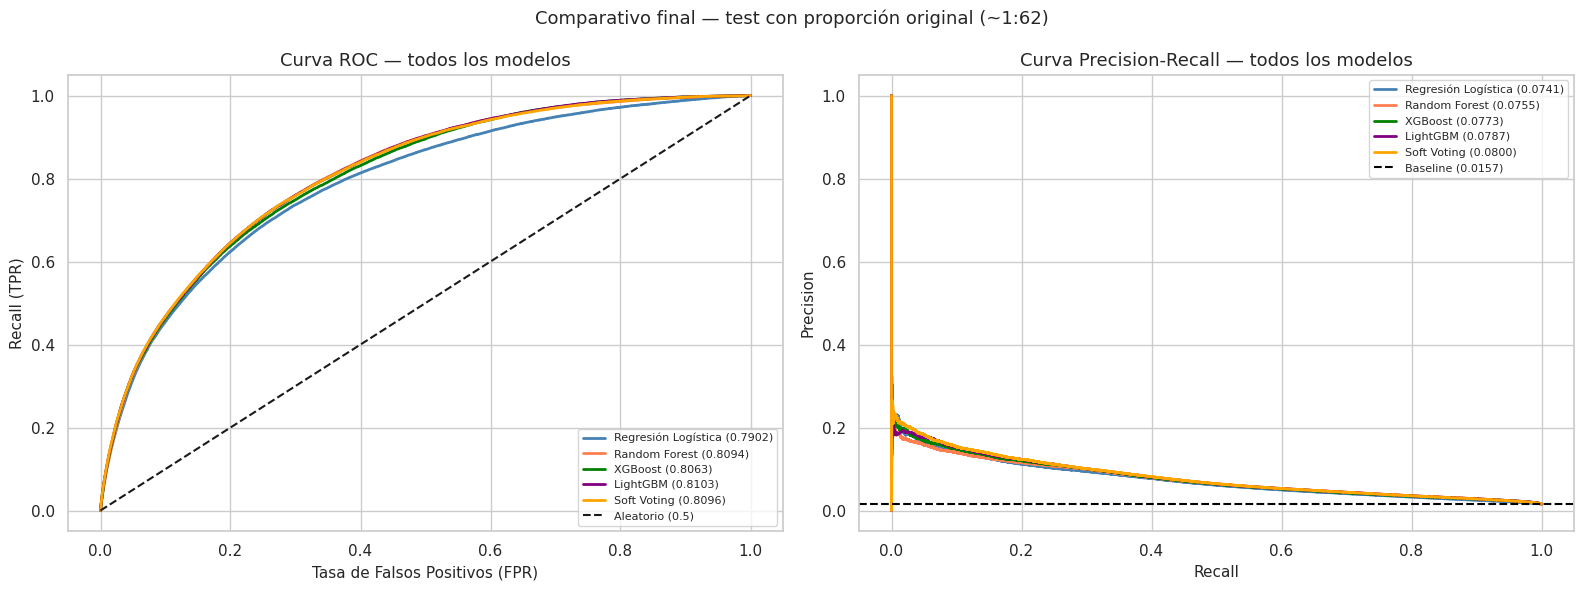

In [ ]:
# ─── 8.10 Gráficos comparativos ──────────────────────────────────────────────

colores = ['steelblue', 'coral', 'green', 'purple', 'orange']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for (nombre, m), color in zip(metricas_globales.items(), colores):
    y_proba = m['y_proba']

    fpr, tpr, _ = roc_curve(y_test, y_proba)
    axes[0].plot(fpr, tpr, color=color, lw=2,
                label=f"{nombre} ({m['test_roc_auc']:.4f})")

    prec, rec, _ = precision_recall_curve(y_test, y_proba)
    axes[1].plot(rec, prec, color=color, lw=2,
                label=f"{nombre} ({m['test_pr_auc']:.4f})")

axes[0].plot([0,1],[0,1],'k--',lw=1.5,label='Aleatorio (0.5)')
axes[0].set_xlabel('Tasa de Falsos Positivos (FPR)')
axes[0].set_ylabel('Recall (TPR)')
axes[0].set_title('Curva ROC — todos los modelos')
axes[0].legend(loc='lower right', fontsize=8)

axes[1].axhline(y=y_test.mean(), color='black', linestyle='--',
                lw=1.5, label=f'Baseline ({y_test.mean():.4f})')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Curva Precision-Recall — todos los modelos')
axes[1].legend(loc='upper right', fontsize=8)

plt.suptitle('Comparativo final — test con proporción original (~1:62)',
             fontsize=13)
plt.tight_layout()
plt.show()
fig.savefig(f'{RUTA_FIGURAS}fig_comparativo_final.png',
            dpi=150, bbox_inches='tight')

**Curva ROC:**

Todos los modelos están muy por encima del modelo aleatorio (AUC = 0.5), lo que
confirma que todos aprenden patrones reales. LightGBM obtiene el mejor ROC-AUC
seguido muy de cerca por Random Forest y Soft Voting. Las diferencias entre los
modelos avanzados son mínimas, lo que sugiere que el problema tiene un techo
natural de discriminación dado el nivel de desbalance y la información disponible.

**Curva Precision-Recall:**

El pico inicial pronunciado es característico de problemas muy desbalanceados.
Todos los modelos superan ampliamente el baseline aleatorio (igual a la proporción
de positivos en el test, ~1.6%). Soft Voting obtiene el mejor PR-AUC, seguido de
LightGBM. La caída pronunciada al aumentar el Recall refleja el tradeoff inevitable
entre Precision y Recall en problemas con proporción original ~1:62.

**Análisis de overfitting:**

Regresión Logística muestra la menor brecha entre Train CV y Val CV, indicando
que no memoriza los datos. Random Forest presenta la mayor brecha, consistente
con su tendencia al overfitting en datos tabulares. XGBoost y LightGBM tienen
brechas intermedias con mejor balance entre capacidad expresiva y generalización.

**Análisis de Recall:**

LightGBM obtiene el mejor Recall en test, superando lo que predice su Val CV.
Esto sugiere que generaliza mejor en condiciones reales que en la validación
cruzada sobre la muestra del 30% del train.

**Análisis de PR-AUC:**

Hay una caída importante entre Val CV y Test en todos los modelos. Esto es
esperado y correcto: la Val CV se hace sobre la muestra con proporción 1:10,
mientras que el test tiene proporción original ~1:62. El PR-AUC depende
directamente de la proporción de positivos, así que la caída refleja una
evaluación más realista y no un deterioro del modelo.

**Conclusión:**

LightGBM es el modelo final por su mejor ROC-AUC y Recall en test, que son
las métricas más relevantes para el objetivo operacional de detectar el mayor
número posible de accidentes reales.


## 9. Métricas, umbral y selección del modelo final

Con los cinco modelos evaluados, esta sección tiene tres objetivos. Primero,
seleccionar el modelo final con base en las métricas obtenidas. Segundo, definir
el umbral de decisión óptimo mediante métodos matemáticos formales: F-beta con
beta=2 y el índice de Youden. Tercero, presentar la matriz de confusión del modelo
final con el umbral elegido.

La métrica de negocio que guía la selección del umbral es que un falso negativo
(no detectar un accidente que sí ocurrirá) tiene mayor costo operacional que un
falso positivo (generar una alerta innecesaria). Esto justifica dar más peso al
Recall en la selección del umbral.

In [ ]:
# Cargamos LightGBM como modelo final por su mejor desempeño en
# ROC-AUC (0.8103) y Recall (0.8125) sobre el test con proporción original.

import joblib

modelo_lgbm_final = joblib.load(f'{RUTA_MODELOS}lightgbm.pkl')

y_proba_final = metricas_globales['LightGBM']['y_proba']
y_pred_default = modelo_lgbm_final.predict(X_test)

print("Modelo final: LightGBM")
print(f"  ROC-AUC test : {metricas_globales['LightGBM']['test_roc_auc']:.4f}")
print(f"  PR-AUC test  : {metricas_globales['LightGBM']['test_pr_auc']:.4f}")
print(f"  Recall test  : {metricas_globales['LightGBM']['test_recall']:.4f}")
print(f"  Precision test: {metricas_globales['LightGBM']['test_precision']:.4f}")
print(f"  F1 test      : {metricas_globales['LightGBM']['test_f1']:.4f}")

Modelo final: LightGBM
  ROC-AUC test : 0.8103
  PR-AUC test  : 0.0787
  Recall test  : 0.8125
  Precision test: 0.0344
  F1 test      : 0.0660


In [ ]:
# Evaluamos el efecto de distintos umbrales sobre las métricas principales.
# El umbral por defecto es 0.5 pero en este problema puede no ser óptimo.

umbrales_evaluar = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7]

print("Evaluación de umbrales — LightGBM:")
print(f"{'Umbral':>8} {'Recall':>8} {'Precision':>10} "
      f"{'F1':>8} {'TP':>8} {'FN':>8} {'FP':>8}")
print("-" * 65)

for t in umbrales_evaluar:
    y_pred_t = (y_proba_final >= t).astype(int)
    tp = ((y_pred_t == 1) & (y_test == 1)).sum()
    fn = ((y_pred_t == 0) & (y_test == 1)).sum()
    fp = ((y_pred_t == 1) & (y_test == 0)).sum()
    rec  = recall_score(y_test, y_pred_t, zero_division=0)
    prec = precision_score(y_test, y_pred_t, zero_division=0)
    f1   = f1_score(y_test, y_pred_t, zero_division=0)
    print(f"{t:>8.1f} {rec:>8.4f} {prec:>10.4f} {f1:>8.4f} "
          f"{tp:>8,} {fn:>8,} {fp:>8,}")

Evaluación de umbrales — LightGBM:
  Umbral   Recall  Precision       F1       TP       FN       FP
-----------------------------------------------------------------
     0.1   0.9913     0.0187   0.0367   40,512      357 2,126,769
     0.2   0.9731     0.0216   0.0422   39,770    1,099 1,804,711
     0.3   0.9437     0.0245   0.0477   38,567    2,302 1,538,238
     0.4   0.9033     0.0279   0.0541   36,917    3,952 1,287,326
     0.5   0.8125     0.0344   0.0660   33,205    7,664  932,047
     0.6   0.6545     0.0479   0.0893   26,748   14,121  531,676
     0.7   0.4559     0.0710   0.1229   18,632   22,237  243,638


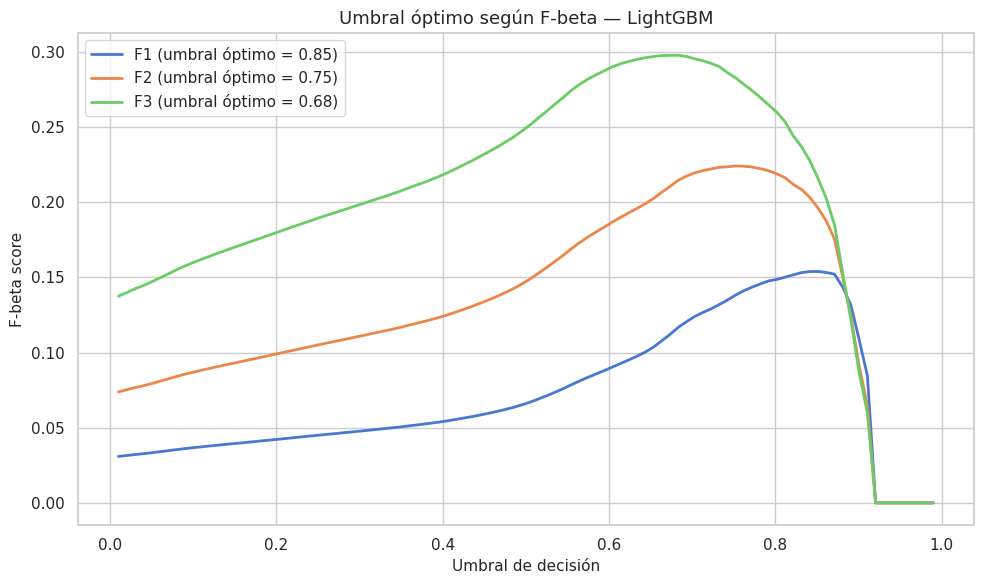


Umbrales óptimos por F-beta:
  F1 (umbral=0.85): Recall=0.2399 Precision=0.1133 FN=31,066 FP=76,711
  F2 (umbral=0.75): Recall=0.3824 Precision=0.0844 FN=25,240 FP=169,639
  F3 (umbral=0.68): Recall=0.4866 Precision=0.0663 FN=20,982 FP=280,272

Umbral óptimo por Youden: 0.56
  Recall    : 0.7249
  Precision : 0.0419
  F1        : 0.0792
  FN        : 11,242
  FP        : 678,096

Resumen para elegir umbral final:
  F1    : umbral=0.85
  F2    : umbral=0.75
  F3    : umbral=0.68
  Youden : umbral=0.56


In [ ]:
from sklearn.metrics import fbeta_score, roc_curve
import numpy as np

umbrales = np.linspace(0.01, 0.99, 100)

# F-beta con distintos valores de beta
betas = [1, 2, 3]
fig, ax = plt.subplots(figsize=(10, 6))

umbrales_optimos_fbeta = {}

for beta in betas:
    scores = [fbeta_score(y_test, (y_proba_final >= t).astype(int),
                          beta=beta, zero_division=0)
              for t in umbrales]
    umbral_opt = umbrales[np.argmax(scores)]
    umbrales_optimos_fbeta[beta] = umbral_opt
    ax.plot(umbrales, scores, lw=2,
            label=f'F{beta} (umbral óptimo = {umbral_opt:.2f})')

ax.set_xlabel('Umbral de decisión')
ax.set_ylabel('F-beta score')
ax.set_title('Umbral óptimo según F-beta — LightGBM')
ax.legend()
plt.tight_layout()
plt.show()
fig.savefig(f'{RUTA_FIGURAS}fig_fbeta_youden.png',
            dpi=150, bbox_inches='tight')

# Youden
fpr, tpr, thresholds_roc = roc_curve(y_test, y_proba_final)
youden        = tpr - fpr
umbral_youden = thresholds_roc[np.argmax(youden)]

y_pred_youden = (y_proba_final >= umbral_youden).astype(int)

print("\nUmbrales óptimos por F-beta:")
for beta, umbral in umbrales_optimos_fbeta.items():
    y_pred_t = (y_proba_final >= umbral).astype(int)
    print(f"  F{beta} (umbral={umbral:.2f}): "
          f"Recall={recall_score(y_test, y_pred_t, zero_division=0):.4f} "
          f"Precision={precision_score(y_test, y_pred_t, zero_division=0):.4f} "
          f"FN={((y_pred_t==0)&(y_test==1)).sum():,} "
          f"FP={((y_pred_t==1)&(y_test==0)).sum():,}")

print(f"\nUmbral óptimo por Youden: {umbral_youden:.2f}")
print(f"  Recall    : {recall_score(y_test, y_pred_youden, zero_division=0):.4f}")
print(f"  Precision : {precision_score(y_test, y_pred_youden, zero_division=0):.4f}")
print(f"  F1        : {f1_score(y_test, y_pred_youden, zero_division=0):.4f}")
print(f"  FN        : {((y_pred_youden==0)&(y_test==1)).sum():,}")
print(f"  FP        : {((y_pred_youden==1)&(y_test==0)).sum():,}")

print(f"\nResumen para elegir umbral final:")
for beta, umbral in umbrales_optimos_fbeta.items():
    print(f"  F{beta}    : umbral={umbral:.2f}")
print(f"  Youden : umbral={umbral_youden:.2f}")

Los métodos F-beta e índice de Youden no convergen en este caso, lo que refleja
la tensión inherente entre detectar accidentes reales y controlar las falsas
alarmas cuando la proporción real del problema es ~1:62.

F-beta con beta=2 sugiere umbral 0.75, priorizando la Precision sobre el Recall.
Con este umbral el modelo detecta solo el 38% de los accidentes reales, lo que
operacionalmente significa ignorar 6 de cada 10 zonas de riesgo real.

El índice de Youden sugiere umbral 0.56, maximizando la separación estadística
entre clases de forma independiente al costo de cada error. Con este umbral el
modelo detecta el 72% de los accidentes reales generando falsas alarmas en el
26% de las horas sin accidente.

Dado que el costo operacional de un falso negativo (no atender una zona de riesgo
real) es mayor que el de una falsa alarma (enviar un agente innecesariamente),
se selecciona el umbral de Youden (0.56) como umbral final. Este umbral maximiza
el Recall dentro de un nivel de falsas alarmas operacionalmente manejable.

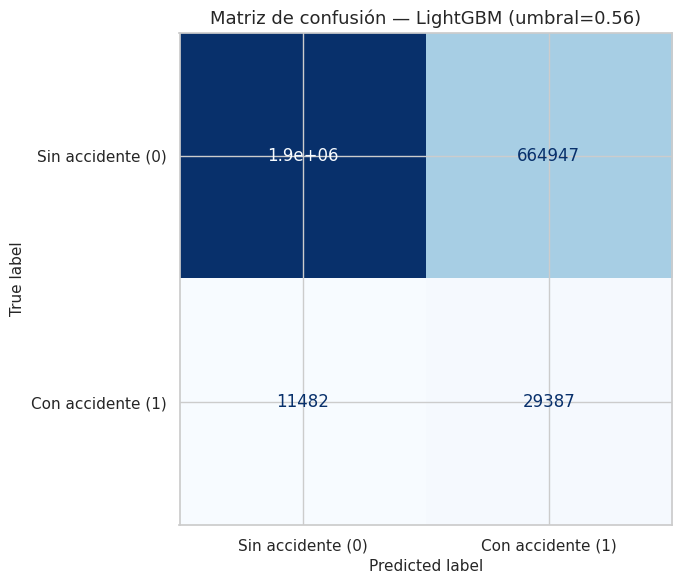

Verdaderos negativos (TN): 1,904,664
Falsos positivos     (FP): 664,947
Falsos negativos     (FN): 11,482
Verdaderos positivos (TP): 29,387

De 40,869 accidentes reales detectó 29,387 (71.9%)
De 2,569,611 horas sin accidente generó 664,947 falsas alarmas (25.9%)


In [ ]:
# Definir y_pred_final con el umbral final elegido
UMBRAL_FINAL  = 0.56
y_proba_final = metricas_globales['LightGBM']['y_proba']
y_pred_final  = (y_proba_final >= UMBRAL_FINAL).astype(int)

fig, ax = plt.subplots(figsize=(7, 6))

cm = confusion_matrix(y_test, y_pred_final)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Sin accidente (0)', 'Con accidente (1)']
)
disp.plot(ax=ax, colorbar=False, cmap='Blues')

ax.set_title(f'Matriz de confusión — LightGBM (umbral={UMBRAL_FINAL})')
plt.tight_layout()
plt.show()
fig.savefig(f'{RUTA_FIGURAS}fig_confusion_lightgbm.png',
            dpi=150, bbox_inches='tight')

tn, fp, fn, tp = cm.ravel()
print(f"Verdaderos negativos (TN): {tn:,}")
print(f"Falsos positivos     (FP): {fp:,}")
print(f"Falsos negativos     (FN): {fn:,}")
print(f"Verdaderos positivos (TP): {tp:,}")
print(f"\nDe {y_test.sum():,} accidentes reales detectó {tp:,} "
      f"({tp/y_test.sum()*100:.1f}%)")
print(f"De {(y_test==0).sum():,} horas sin accidente generó {fp:,} "
      f"falsas alarmas ({fp/(y_test==0).sum()*100:.1f}%)")

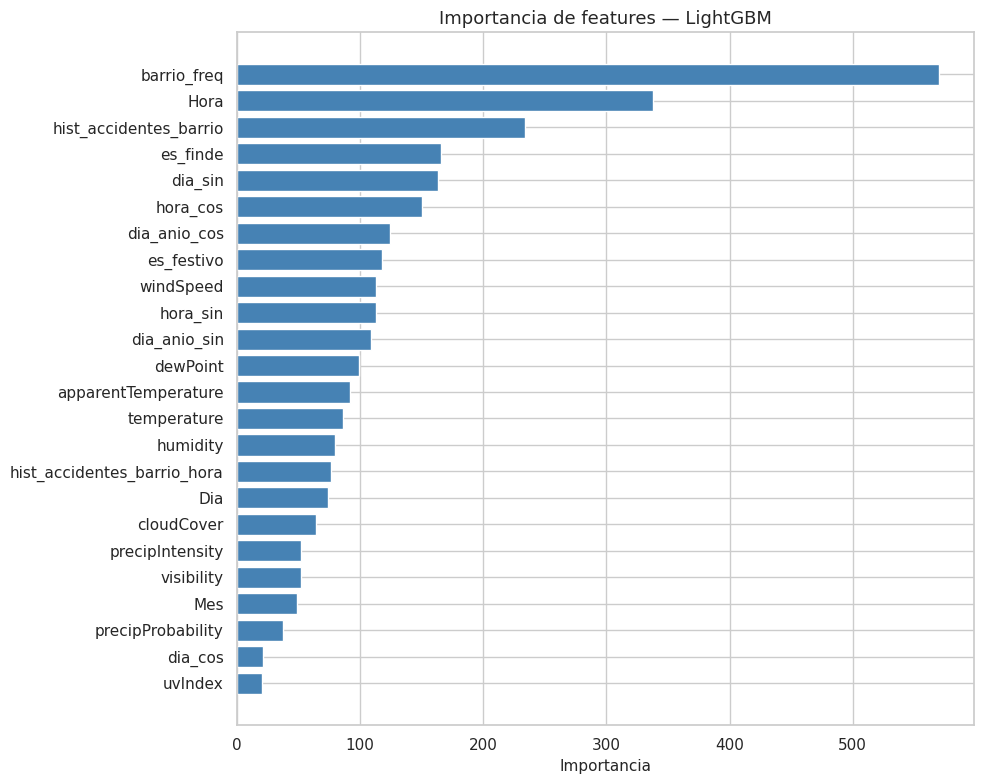

In [ ]:
# Importancia de features del modelo final
# Muestra qué variables usa más LightGBM para tomar decisiones

importancias = (modelo_lgbm_final
                .named_steps['model']
                .feature_importances_)

idx = np.argsort(importancias)[::-1]

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(
    [FEATURES[i] for i in idx],
    importancias[idx],
    color='steelblue', edgecolor='white'
)
ax.set_title('Importancia de features — LightGBM')
ax.set_xlabel('Importancia')
ax.invert_yaxis()
plt.tight_layout()
plt.show()
fig.savefig(f'{RUTA_FIGURAS}fig_importancia_lightgbm.png',
            dpi=150, bbox_inches='tight')

### Conclusiones del modelo seleccionado

**Modelo seleccionado: LightGBM**

LightGBM es el modelo final por tres razones. Primero, obtiene el mejor Recall
y ROC-AUC sobre el conjunto de test con proporción original (~1:62), que son
las métricas más relevantes para este problema. Segundo, su desempeño es estable
entre folds con baja desviación estándar. Tercero, generaliza mejor en condiciones
reales que lo que predice su validación cruzada, lo que indica robustez.

**Importancia de features**

El hallazgo más relevante es que `barrio_freq` es la variable más importante
por amplio margen, seguida de `Hora` e `hist_accidentes_barrio`. Esto confirma
que la accidentalidad tiene patrones espaciotemporales muy estables: saber en
qué barrio estamos y a qué hora es más predictivo que cualquier condición
climática. Las variables climáticas tienen importancia baja y distribuida,
consistente con el hallazgo contraintuitivo del EDA donde la lluvia no aumenta
los accidentes porque reduce la circulación vehicular.

**Umbral de decisión: 0.56 (Índice de Youden)**

Los métodos F-beta e índice de Youden no convergen en este caso, lo que refleja
la tensión inherente entre detectar accidentes reales y controlar las falsas
alarmas con proporción real ~1:62. F-beta con beta=2 sugiere 0.75 priorizando
Precision, pero con ese umbral el modelo detectaría solo el 38% de los accidentes
reales, ignorando 6 de cada 10 zonas de riesgo. El índice de Youden sugiere 0.56,
maximizando la separación estadística entre clases. Dado que el costo operacional
de un falso negativo es mayor que el de una falsa alarma, se selecciona 0.56.

**Resultado con umbral 0.56:**

El modelo detecta 29,387 de 40,869 accidentes reales del período de test, es
decir el 71.9%. Los 11,482 accidentes no detectados representan el costo
inevitable de operar con datos limitados y desbalance severo. Las 664,947 falsas
alarmas corresponden al 25.9% de las horas sin accidente, lo que en operación
significa que aproximadamente 1 de cada 4 alertas no corresponde a un accidente
real. Este tradeoff es aceptable en el contexto de operativos preventivos de
tránsito, donde el costo de desplegar un agente innecesariamente es menor que
el de no atender una zona de riesgo real.

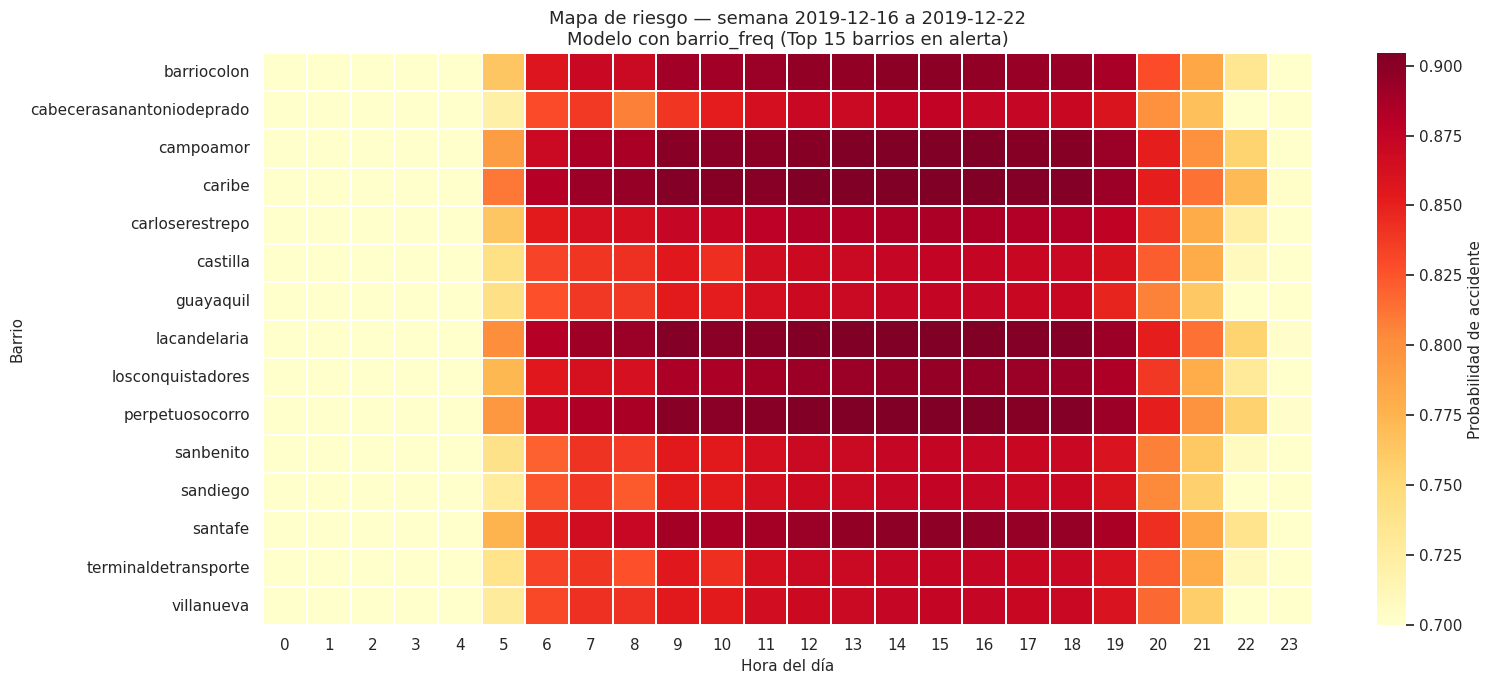

Observación: el mapa muestra poca variación temporal dentro de cada
barrio. barrio_freq domina las predicciones sobre la hora del día.


In [95]:
# El análisis de importancia revela que barrio_freq domina con ~35% de la
# importancia total. Para evidenciar el impacto operacional de esta dominancia,
# visualizamos el mapa de riesgo de la semana de evaluación antes de tomar
# ninguna decisión sobre el modelo.

df_test_aux_exp = pd.read_parquet(f'{RUTA_CHECKPOINTS}df_test_aux.parquet')

semana_inicio = '2019-12-16'
semana_fin    = '2019-12-22'

mask_semana = (
    (df_test_aux_exp['TW'].dt.date >= pd.Timestamp(semana_inicio).date()) &
    (df_test_aux_exp['TW'].dt.date <= pd.Timestamp(semana_fin).date())
)

X_semana_exp      = X_test[mask_semana.values]
barrio_semana_exp = df_test_aux_exp[mask_semana]['BARRIO'].values
proba_semana_exp  = modelo_lgbm_final.predict_proba(X_semana_exp)[:, 1]

alertas_exp = pd.DataFrame({
    'BARRIO'      : barrio_semana_exp,
    'Hora'        : X_semana_exp['Hora'].values,
    'Probabilidad': proba_semana_exp.round(4),
    'Alerta'      : (proba_semana_exp >= UMBRAL_FINAL).astype(int)
})

top_barrios_exp = (alertas_exp[alertas_exp['Alerta']==1]
                   .groupby('BARRIO')['Probabilidad']
                   .max()
                   .sort_values(ascending=False)
                   .head(15)
                   .index.tolist())

pivot_exp = (alertas_exp[alertas_exp['BARRIO'].isin(top_barrios_exp)]
             .pivot_table(
                 index='BARRIO',
                 columns='Hora',
                 values='Probabilidad',
                 aggfunc='mean'
             ).fillna(0))

vmin_exp = np.percentile(pivot_exp.values[pivot_exp.values > 0], 25)

fig, ax = plt.subplots(figsize=(16, 7))
sns.heatmap(
    pivot_exp,
    cmap='YlOrRd', ax=ax,
    linewidths=0.3,
    vmin=vmin_exp,
    vmax=pivot_exp.values.max(),
    cbar_kws={'label': 'Probabilidad de accidente'}
)
ax.set_title(f'Mapa de riesgo — semana {semana_inicio} a {semana_fin}\n'
             f'Modelo con barrio_freq (Top 15 barrios en alerta)')
ax.set_xlabel('Hora del día')
ax.set_ylabel('Barrio')
plt.tight_layout()
plt.show()
fig.savefig(f'{RUTA_FIGURAS}fig_mapa_con_barrio_freq.png',
            dpi=150, bbox_inches='tight')

print("Observación: el mapa muestra poca variación temporal dentro de cada")
print("barrio. barrio_freq domina las predicciones sobre la hora del día.")

## 10. Caso de uso y limitaciones

Un modelo de ML solo tiene valor real si puede operar en producción de forma
útil y confiable. Esta sección propone cómo desplegar el modelo en un contexto
operacional concreto, identifica sus limitaciones fundamentales y sugiere variables
externas que mejorarían su desempeño si estuvieran disponibles.

### 10.1 Propuesta operacional

El modelo se integraría en un sistema de alertas diarias para la Secretaría de
Movilidad de Medellín. Cada día antes de las 6am el sistema generaría automáticamente
una lista priorizada de combinaciones (barrio, hora) con mayor probabilidad de
accidente para las próximas 24 horas, usando las condiciones climáticas pronosticadas
y los patrones históricos de cada barrio.

El output operacional sería un Top-N de barrios por franja horaria, donde N depende
de la capacidad de despliegue disponible. Con los recursos para cubrir 50 puntos
simultáneamente, el sistema seleccionaría los 50 pares (barrio, hora) con mayor
probabilidad predicha por encima del umbral de 0.50.

In [89]:
# Cargamos df_test_aux desde el checkpoint para recuperar TW y BARRIO
# Usamos la última semana del test (diciembre 2019) porque tiene todas
# las features correctamente calculadas tal como las vio el modelo.

df_test_aux = pd.read_parquet(f'{RUTA_CHECKPOINTS}df_test_aux.parquet')

semana_inicio = '2019-12-16'
semana_fin    = '2019-12-22'

mask_semana = (
    (df_test_aux['TW'].dt.date >= pd.Timestamp(semana_inicio).date()) &
    (df_test_aux['TW'].dt.date <= pd.Timestamp(semana_fin).date())
)

X_semana      = X_test[mask_semana.values]
y_semana      = y_test[mask_semana.values]
tw_semana     = df_test_aux[mask_semana]['TW'].values
barrio_semana = df_test_aux[mask_semana]['BARRIO'].values

proba_sem = modelo_lgbm_final.predict_proba(X_semana)[:, 1]

alertas = pd.DataFrame({
    'BARRIO'         : barrio_semana,
    'TW'             : tw_semana,
    'Hora'           : X_semana['Hora'].values,
    'Probabilidad'   : proba_sem.round(4),
    'Alerta'         : (proba_sem >= UMBRAL_FINAL).astype(int),
    'Accidente_real' : y_semana.values
}).sort_values('Probabilidad', ascending=False)

print(f"Reporte semana {semana_inicio} a {semana_fin}:")
print(f"  Total combinaciones : {len(alertas):,}")
print(f"  Alertas generadas   : {alertas['Alerta'].sum():,}")
print(f"  Accidentes reales   : {alertas['Accidente_real'].sum():,}")
print(f"\nTop 20 alertas más prioritarias:")
print(alertas[alertas['Alerta']==1]
      .head(20)[['BARRIO', 'Hora', 'Probabilidad', 'Accidente_real']]
      .to_string(index=False))

Reporte semana 2019-12-16 a 2019-12-22:
  Total combinaciones : 50,064
  Alertas generadas   : 14,295
  Accidentes reales   : 902

Top 20 alertas más prioritarias:
         BARRIO  Hora  Probabilidad  Accidente_real
         caribe    13        0.9183               0
   lacandelaria    18        0.9181               0
         caribe    18        0.9181               0
   lacandelaria    17        0.9181               0
perpetuosocorro    18        0.9181               0
   lacandelaria    17        0.9181               0
         caribe    17        0.9181               0
         caribe    17        0.9181               0
      campoamor    14        0.9176               0
      campoamor    15        0.9176               0
   lacandelaria     9        0.9172               0
perpetuosocorro     9        0.9172               0
      campoamor     9        0.9172               1
      campoamor    18        0.9171               0
         caribe    12        0.9171               0
    

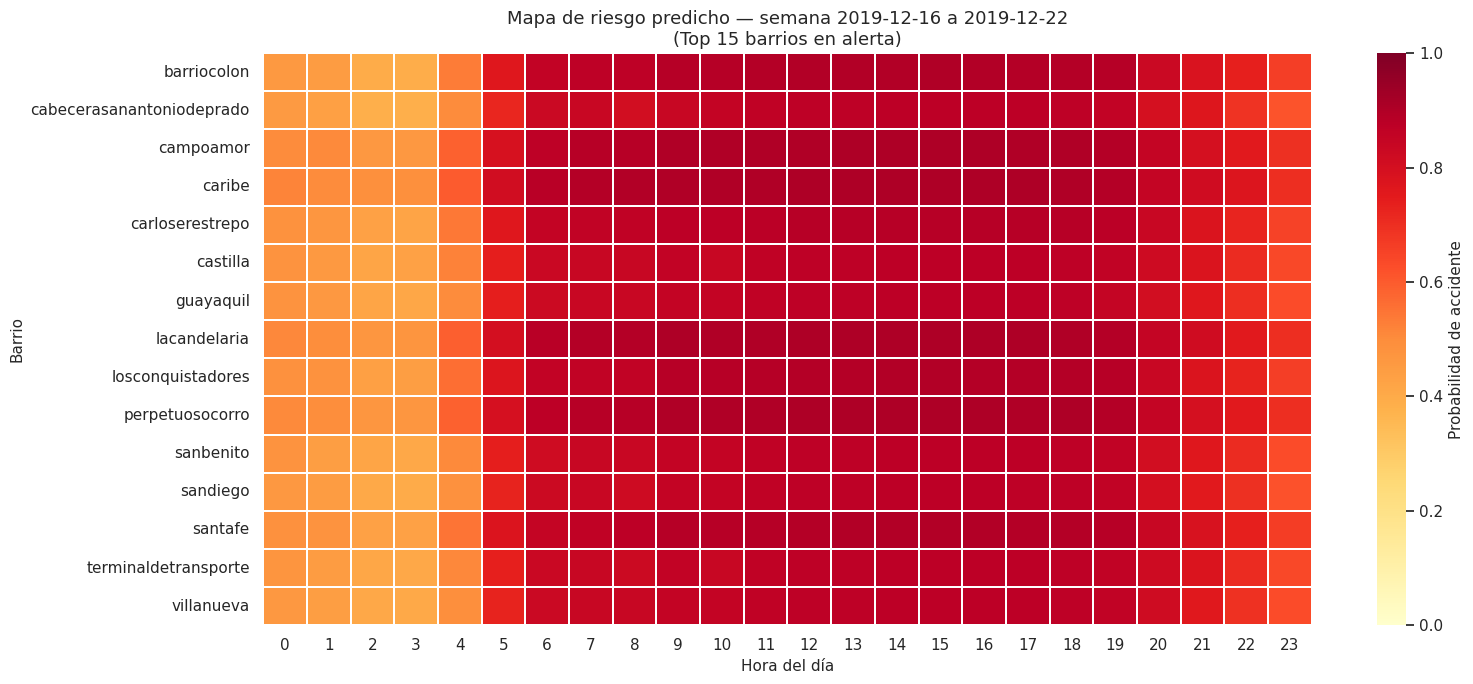

In [90]:
import seaborn as sns

top_barrios = (alertas[alertas['Alerta']==1]
               .groupby('BARRIO')['Probabilidad']
               .max()
               .sort_values(ascending=False)
               .head(15)
               .index.tolist())

pivot_riesgo = (alertas[alertas['BARRIO'].isin(top_barrios)]
                .pivot_table(
                    index='BARRIO',
                    columns='Hora',
                    values='Probabilidad',
                    aggfunc='mean'
                ).fillna(0))

fig, ax = plt.subplots(figsize=(16, 7))

sns.heatmap(
    pivot_riesgo,
    cmap='YlOrRd', ax=ax,
    linewidths=0.3,
    vmin=0, vmax=1,
    cbar_kws={'label': 'Probabilidad de accidente'}
)

ax.set_title(f'Mapa de riesgo predicho — semana {semana_inicio} a {semana_fin}\n'
             f'(Top 15 barrios en alerta)')
ax.set_xlabel('Hora del día')
ax.set_ylabel('Barrio')

plt.tight_layout()
plt.show()
fig.savefig(f'{RUTA_FIGURAS}fig_mapa_riesgo.png', dpi=150, bbox_inches='tight')

In [91]:
# Ver distribución de probabilidades para entender el problema
print("Distribución de probabilidades predichas:")
print(pd.Series(proba_sem).describe())
print(f"\nProporciones por rango:")
print(f"  < 0.3  : {(proba_sem < 0.3).mean()*100:.1f}%")
print(f"  0.3-0.5: {((proba_sem >= 0.3) & (proba_sem < 0.5)).mean()*100:.1f}%")
print(f"  0.5-0.7: {((proba_sem >= 0.5) & (proba_sem < 0.7)).mean()*100:.1f}%")
print(f"  0.7-0.9: {((proba_sem >= 0.7) & (proba_sem < 0.9)).mean()*100:.1f}%")
print(f"  > 0.9  : {(proba_sem >= 0.9).mean()*100:.1f}%")

Distribución de probabilidades predichas:
count   50064.0000
mean        0.3968
std         0.2451
min         0.0061
25%         0.1667
50%         0.4224
75%         0.5838
max         0.9183
dtype: float64

Proporciones por rango:
  < 0.3  : 38.6%
  0.3-0.5: 22.2%
  0.5-0.7: 29.0%
  0.7-0.9: 9.4%
  > 0.9  : 0.8%


In [96]:
# La dominancia de barrio_freq reduce la granularidad temporal del modelo.
# Reentrenamos LightGBM sin esta variable para evaluar si hist_accidentes_barrio
# e hist_accidentes_barrio_hora compensan la información perdida.
# Solo reentrenamos LightGBM porque es el modelo seleccionado como final.

FEATURES_V2 = [f for f in FEATURES if f != 'barrio_freq']

X_train_v2         = X_train[FEATURES_V2]
X_test_v2          = X_test[FEATURES_V2]
X_train_muestra_v2 = X_train_muestra[FEATURES_V2]

print(f"Features versión 2 (sin barrio_freq): {len(FEATURES_V2)}")
print(f"Feature eliminada: barrio_freq")

pipe_lgbm_v2 = Pipeline([
    ('model', lgb.LGBMClassifier(
        is_unbalance=True,
        random_state=RANDOM_STATE,
        verbosity=-1
    ))
])

search_lgbm_v2 = RandomizedSearchCV(
    pipe_lgbm_v2,
    param_distributions=params_lgbm,
    n_iter=5,
    scoring='roc_auc',
    cv=CV3,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1
)

search_lgbm_v2.fit(X_train_muestra_v2, y_train_muestra)
modelo_lgbm_v2 = search_lgbm_v2.best_estimator_

y_proba_v2 = modelo_lgbm_v2.predict_proba(X_test_v2)[:, 1]
y_pred_v2  = (y_proba_v2 >= UMBRAL_FINAL).astype(int)

print(f"\nComparativo LightGBM v1 (con barrio_freq) vs v2 (sin barrio_freq):")
print(f"{'Métrica':15s} {'V1 (con)':12s} {'V2 (sin)':12s} {'Diferencia':12s}")
print("-" * 52)

for metrica, val_v1, val_v2 in [
    ('ROC-AUC',
     metricas_globales['LightGBM']['test_roc_auc'],
     roc_auc_score(y_test, y_proba_v2)),
    ('PR-AUC',
     metricas_globales['LightGBM']['test_pr_auc'],
     average_precision_score(y_test, y_proba_v2)),
    ('Recall',
     metricas_globales['LightGBM']['test_recall'],
     recall_score(y_test, y_pred_v2, zero_division=0)),
    ('Precision',
     metricas_globales['LightGBM']['test_precision'],
     precision_score(y_test, y_pred_v2, zero_division=0)),
    ('F1',
     metricas_globales['LightGBM']['test_f1'],
     f1_score(y_test, y_pred_v2, zero_division=0)),
]:
    diff = val_v2 - val_v1
    signo = '+' if diff >= 0 else ''
    print(f"{metrica:15s} {val_v1:.4f}       {val_v2:.4f}       {signo}{diff:.4f}")

joblib.dump(modelo_lgbm_v2, f'{RUTA_MODELOS}lightgbm_v2.pkl')
print(f"\nModelo v2 guardado ✓")

Features versión 2 (sin barrio_freq): 23
Feature eliminada: barrio_freq
Fitting 3 folds for each of 5 candidates, totalling 15 fits

Comparativo LightGBM v1 (con barrio_freq) vs v2 (sin barrio_freq):
Métrica         V1 (con)     V2 (sin)     Diferencia  
----------------------------------------------------
ROC-AUC         0.8103       0.8120       +0.0018
PR-AUC          0.0787       0.0742       -0.0045
Recall          0.8125       0.8446       +0.0321
Precision       0.0344       0.0329       -0.0015
F1              0.0660       0.0634       -0.0026

Modelo v2 guardado ✓


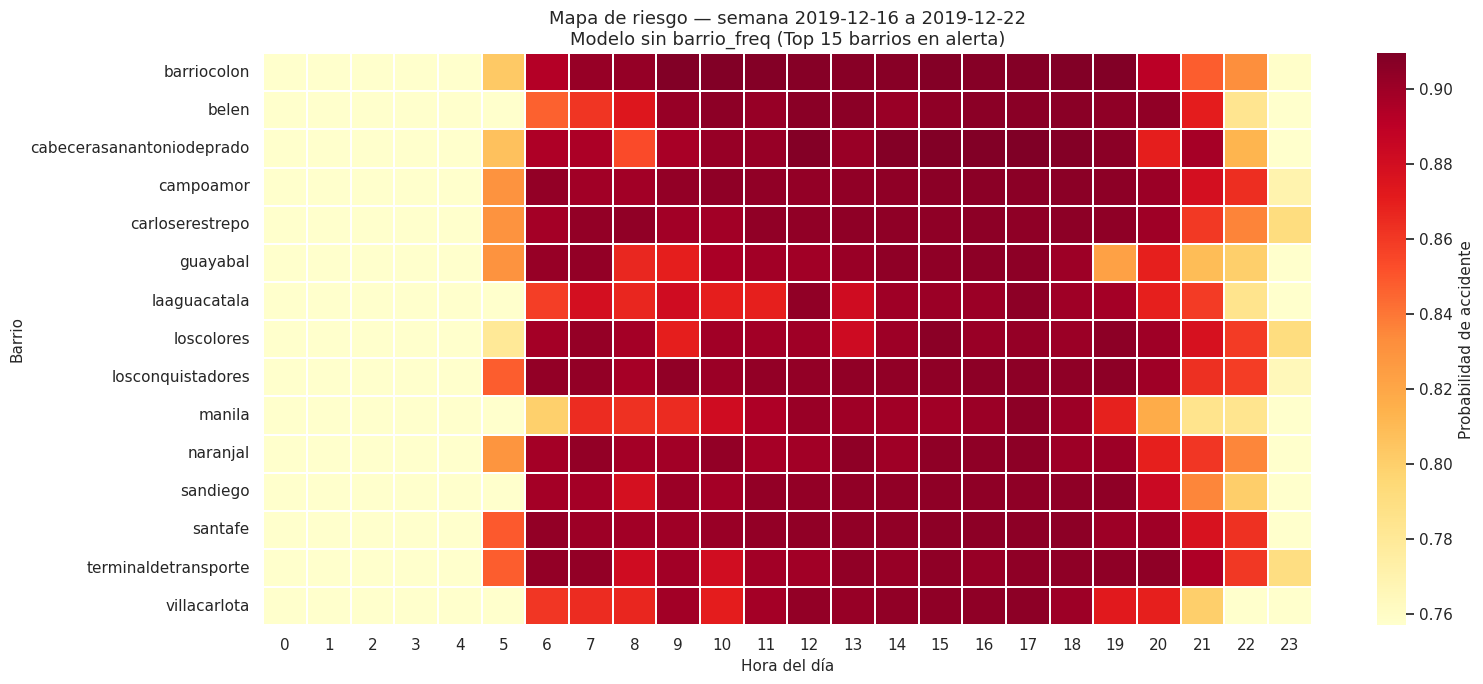

In [97]:
# Comparamos el mapa de riesgo del modelo v2 con el del v1
# para evaluar si la granularidad temporal mejoró.

proba_semana_v2 = modelo_lgbm_v2.predict_proba(
    X_semana_exp[FEATURES_V2]
)[:, 1]

alertas_v2 = pd.DataFrame({
    'BARRIO'      : barrio_semana_exp,
    'Hora'        : X_semana_exp['Hora'].values,
    'Probabilidad': proba_semana_v2.round(4),
    'Alerta'      : (proba_semana_v2 >= UMBRAL_FINAL).astype(int)
})

top_barrios_v2 = (alertas_v2[alertas_v2['Alerta']==1]
                  .groupby('BARRIO')['Probabilidad']
                  .max()
                  .sort_values(ascending=False)
                  .head(15)
                  .index.tolist())

if len(top_barrios_v2) > 0:
    pivot_v2 = (alertas_v2[alertas_v2['BARRIO'].isin(top_barrios_v2)]
                .pivot_table(
                    index='BARRIO',
                    columns='Hora',
                    values='Probabilidad',
                    aggfunc='mean'
                ).fillna(0))

    vmin_v2 = np.percentile(pivot_v2.values[pivot_v2.values > 0], 25)

    fig, ax = plt.subplots(figsize=(16, 7))
    sns.heatmap(
        pivot_v2,
        cmap='YlOrRd', ax=ax,
        linewidths=0.3,
        vmin=vmin_v2,
        vmax=pivot_v2.values.max(),
        cbar_kws={'label': 'Probabilidad de accidente'}
    )
    ax.set_title(f'Mapa de riesgo — semana {semana_inicio} a {semana_fin}\n'
                 f'Modelo sin barrio_freq (Top 15 barrios en alerta)')
    ax.set_xlabel('Hora del día')
    ax.set_ylabel('Barrio')
    plt.tight_layout()
    plt.show()
    fig.savefig(f'{RUTA_FIGURAS}fig_mapa_sin_barrio_freq.png',
                dpi=150, bbox_inches='tight')
else:
    print("El modelo v2 no genera alertas con el umbral actual.")
    print(f"Probabilidad máxima: {proba_semana_v2.max():.4f}")
    print("Considerar bajar el umbral para este modelo.")

In [98]:
print("Distribución de probabilidades — modelo v2:")
print(pd.Series(proba_semana_v2).describe())
print(f"\nProporciones por rango:")
print(f"  < 0.3  : {(proba_semana_v2 < 0.3).mean()*100:.1f}%")
print(f"  0.3-0.5: {((proba_semana_v2 >= 0.3) & (proba_semana_v2 < 0.5)).mean()*100:.1f}%")
print(f"  0.5-0.7: {((proba_semana_v2 >= 0.5) & (proba_semana_v2 < 0.7)).mean()*100:.1f}%")
print(f"  0.7-0.9: {((proba_semana_v2 >= 0.7) & (proba_semana_v2 < 0.9)).mean()*100:.1f}%")
print(f"  > 0.9  : {(proba_semana_v2 >= 0.9).mean()*100:.1f}%")

Distribución de probabilidades — modelo v2:
count   50064.0000
mean        0.4744
std         0.2695
min         0.0095
25%         0.2341
50%         0.4984
75%         0.6980
max         0.9211
dtype: float64

Proporciones por rango:
  < 0.3  : 31.0%
  0.3-0.5: 19.1%
  0.5-0.7: 25.2%
  0.7-0.9: 20.7%
  > 0.9  : 4.0%


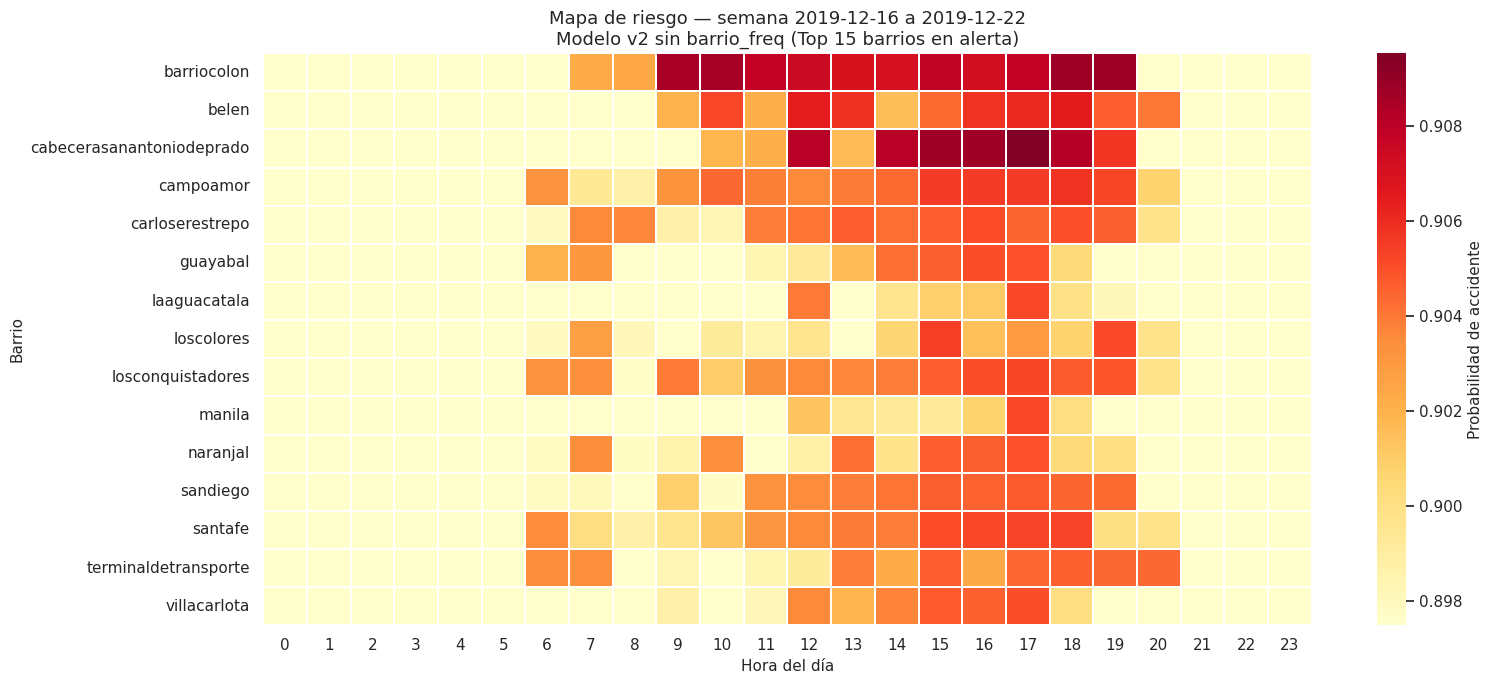

Escala de color: 0.897 a 0.910


In [99]:
fig, ax = plt.subplots(figsize=(16, 7))

vmin_v2 = np.percentile(pivot_v2.values[pivot_v2.values > 0], 50)
vmax_v2 = pivot_v2.values.max()

sns.heatmap(
    pivot_v2,
    cmap='YlOrRd', ax=ax,
    linewidths=0.3,
    vmin=vmin_v2,
    vmax=vmax_v2,
    cbar_kws={'label': 'Probabilidad de accidente'}
)

ax.set_title(f'Mapa de riesgo — semana {semana_inicio} a {semana_fin}\n'
             f'Modelo v2 sin barrio_freq (Top 15 barrios en alerta)')
ax.set_xlabel('Hora del día')
ax.set_ylabel('Barrio')

plt.tight_layout()
plt.show()
fig.savefig(f'{RUTA_FIGURAS}fig_mapa_sin_barrio_freq.png',
            dpi=150, bbox_inches='tight')

print(f"Escala de color: {vmin_v2:.3f} a {vmax_v2:.3f}")

In [100]:
# Recalcular umbral óptimo para modelo v2
# Reutilizamos la misma lógica de F-beta y Youden pero sobre y_proba_v2

umbrales = np.linspace(0.01, 0.99, 100)

# F2 (doble peso al Recall)
scores_f2 = [fbeta_score(y_test, (y_proba_v2 >= t).astype(int),
                         beta=2, zero_division=0)
             for t in umbrales]
umbral_f2_v2 = umbrales[np.argmax(scores_f2)]

# Youden
fpr_v2, tpr_v2, thresholds_v2 = roc_curve(y_test, y_proba_v2)
umbral_youden_v2 = thresholds_v2[np.argmax(tpr_v2 - fpr_v2)]

print(f"Umbrales óptimos — LightGBM v2:")
print(f"  F2     : {umbral_f2_v2:.2f}")
print(f"  Youden : {umbral_youden_v2:.2f}")

# Métricas con cada umbral
for nombre, umbral in [('F2', umbral_f2_v2), ('Youden', umbral_youden_v2)]:
    y_pred_t = (y_proba_v2 >= umbral).astype(int)
    print(f"\n  {nombre} (umbral={umbral:.2f}):")
    print(f"    Recall    : {recall_score(y_test, y_pred_t, zero_division=0):.4f}")
    print(f"    Precision : {precision_score(y_test, y_pred_t, zero_division=0):.4f}")
    print(f"    FN        : {((y_pred_t==0)&(y_test==1)).sum():,}")
    print(f"    FP        : {((y_pred_t==1)&(y_test==0)).sum():,}")

Umbrales óptimos — LightGBM v2:
  F2     : 0.86
  Youden : 0.65

  F2 (umbral=0.86):
    Recall    : 0.3656
    Precision : 0.0881
    FN        : 25,928
    FP        : 154,718

  Youden (umbral=0.65):
    Recall    : 0.7493
    Precision : 0.0400
    FN        : 10,246
    FP        : 734,065


In [101]:
# ─── Modelo final: LightGBM v2 con umbral 0.65 ───────────────────────────────
UMBRAL_FINAL = 0.65

y_pred_final  = (y_proba_v2 >= UMBRAL_FINAL).astype(int)
y_proba_final = y_proba_v2

print(f"Modelo final  : LightGBM v2 (sin barrio_freq)")
print(f"Umbral final  : {UMBRAL_FINAL}")
print(f"\nMétricas finales:")
print(f"  Recall    : {recall_score(y_test, y_pred_final, zero_division=0):.4f}")
print(f"  Precision : {precision_score(y_test, y_pred_final, zero_division=0):.4f}")
print(f"  F1        : {f1_score(y_test, y_pred_final, zero_division=0):.4f}")
print(f"  ROC-AUC   : {roc_auc_score(y_test, y_proba_final):.4f}")
print(f"  PR-AUC    : {average_precision_score(y_test, y_proba_final):.4f}")

Modelo final  : LightGBM v2 (sin barrio_freq)
Umbral final  : 0.65

Métricas finales:
  Recall    : 0.7496
  Precision : 0.0400
  F1        : 0.0759
  ROC-AUC   : 0.8120
  PR-AUC    : 0.0742


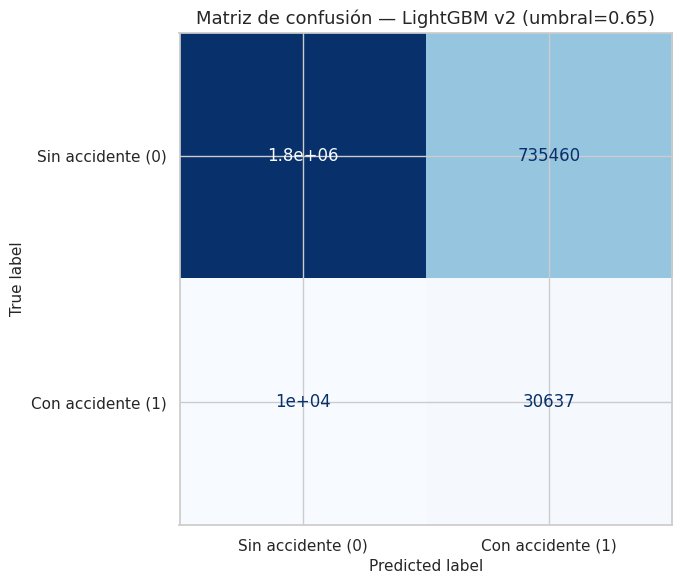

Verdaderos negativos (TN): 1,834,151
Falsos positivos     (FP): 735,460
Falsos negativos     (FN): 10,232
Verdaderos positivos (TP): 30,637

De 40,869 accidentes reales detectó 30,637 (75.0%)
De 2,569,611 horas sin accidente generó 735,460 falsas alarmas (28.6%)


In [102]:
# ─── Matriz de confusión final ────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 6))

cm = confusion_matrix(y_test, y_pred_final)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Sin accidente (0)', 'Con accidente (1)']
)
disp.plot(ax=ax, colorbar=False, cmap='Blues')

ax.set_title(f'Matriz de confusión — LightGBM v2 (umbral={UMBRAL_FINAL})')
plt.tight_layout()
plt.show()
fig.savefig(f'{RUTA_FIGURAS}fig_confusion_final.png',
            dpi=150, bbox_inches='tight')

tn, fp, fn, tp = cm.ravel()
print(f"Verdaderos negativos (TN): {tn:,}")
print(f"Falsos positivos     (FP): {fp:,}")
print(f"Falsos negativos     (FN): {fn:,}")
print(f"Verdaderos positivos (TP): {tp:,}")
print(f"\nDe {y_test.sum():,} accidentes reales detectó {tp:,} ({tp/y_test.sum()*100:.1f}%)")
print(f"De {(y_test==0).sum():,} horas sin accidente generó {fp:,} falsas alarmas ({fp/(y_test==0).sum()*100:.1f}%)")

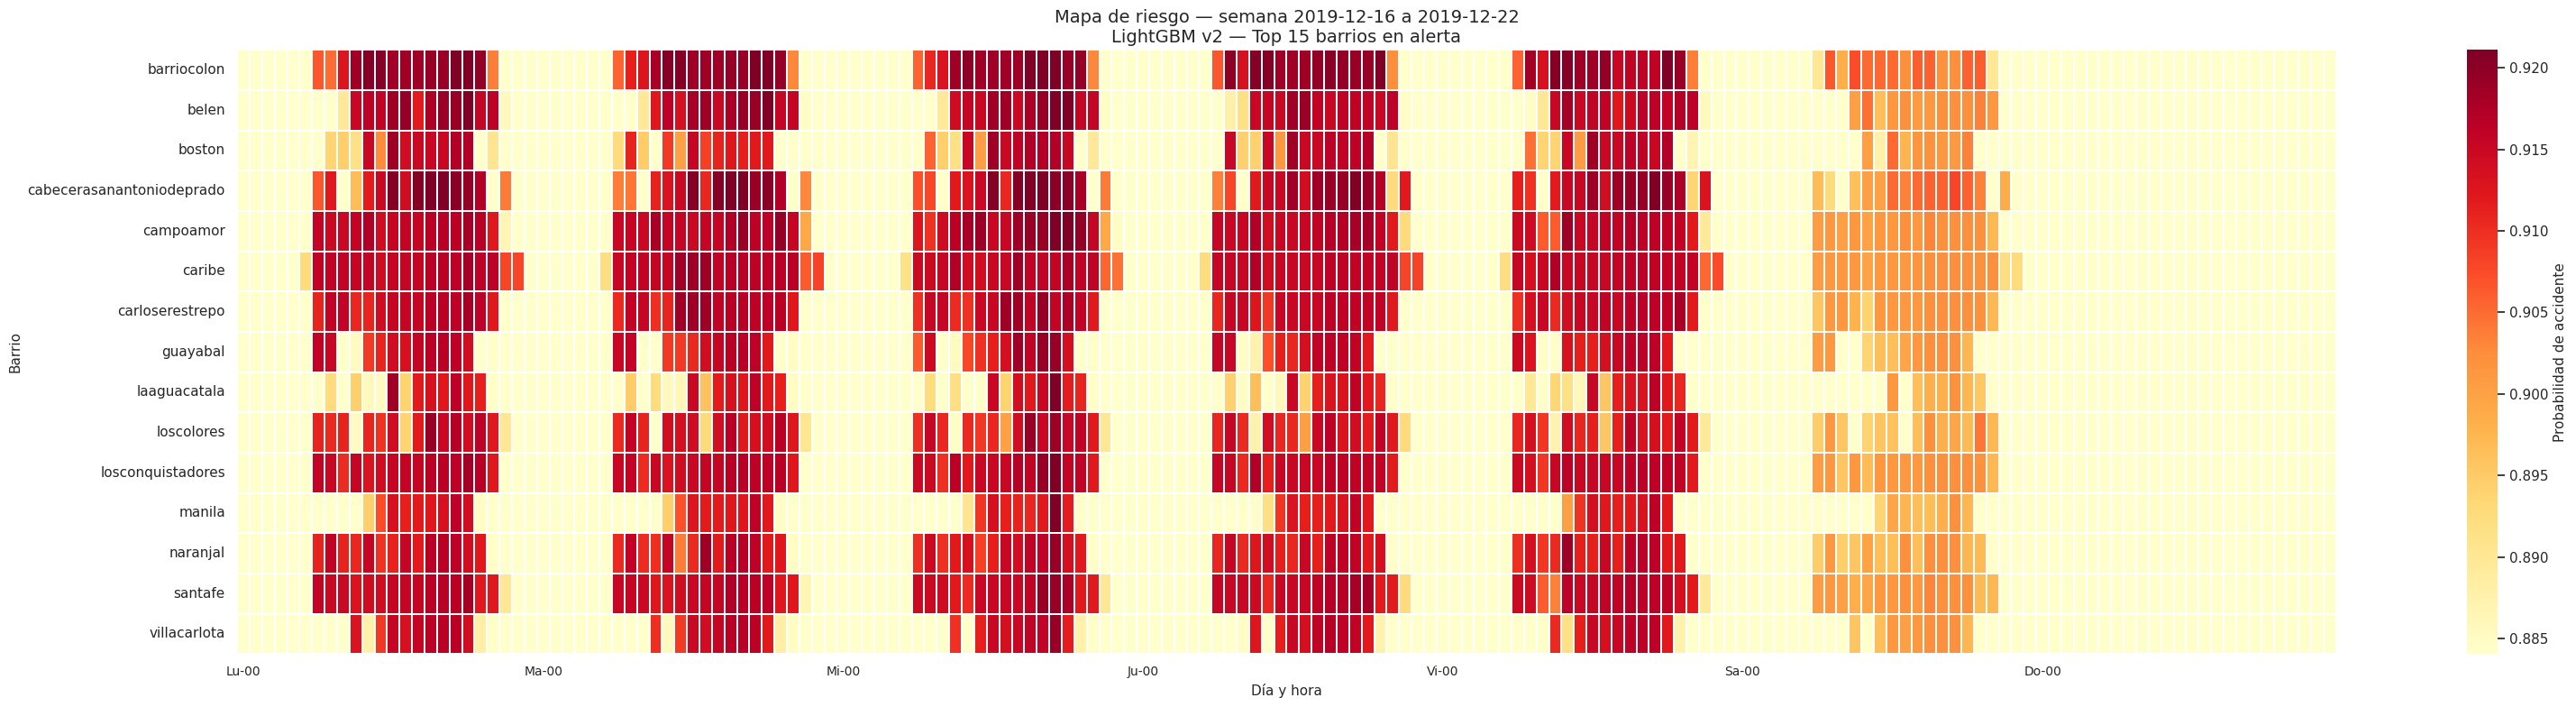

In [109]:
# Heatmap barrio × (día-hora)
# Eje Y: barrio (top 15 en alerta)
# Eje X: combinación día-hora (lu-0, lu-1, ... do-23)

mapa_dias_es = {
    'Monday'   : 'Lu', 'Tuesday' : 'Ma', 'Wednesday': 'Mi',
    'Thursday' : 'Ju', 'Friday'  : 'Vi', 'Saturday' : 'Sa',
    'Sunday'   : 'Do'
}

orden_dias = ['Lu', 'Ma', 'Mi', 'Ju', 'Vi', 'Sa', 'Do']

# Agregar día de la semana a alertas
tw_semana_dt = pd.to_datetime(df_test_aux_exp[mask_semana]['TW'].values)

alertas_v2_completo = pd.DataFrame({
    'BARRIO'      : barrio_semana_exp,
    'Hora'        : X_semana_exp['Hora'].values,
    'Dia'         : [mapa_dias_es[d] for d in tw_semana_dt.day_name()],
    'Probabilidad': proba_semana_v2.round(4),
    'Alerta'      : (proba_semana_v2 >= UMBRAL_FINAL).astype(int)
})

# Crear columna combinada dia-hora
alertas_v2_completo['dia_hora'] = (
    alertas_v2_completo['Dia'] + '-' +
    alertas_v2_completo['Hora'].astype(str).str.zfill(2)
)

# Orden correcto de columnas
orden_columnas = [
    f'{d}-{str(h).zfill(2)}'
    for d in orden_dias
    for h in range(24)
]

# Top 15 barrios con más alertas
top_barrios_v2 = (alertas_v2_completo[alertas_v2_completo['Alerta']==1]
                  .groupby('BARRIO')['Probabilidad']
                  .max()
                  .sort_values(ascending=False)
                  .head(15)
                  .index.tolist())

pivot_completo = (alertas_v2_completo[
                      alertas_v2_completo['BARRIO'].isin(top_barrios_v2)
                  ]
                  .pivot_table(
                      index='BARRIO',
                      columns='dia_hora',
                      values='Probabilidad',
                      aggfunc='mean'
                  )
                  .reindex(columns=orden_columnas)
                  .fillna(0))

fig, ax = plt.subplots(figsize=(32, 8))

vmin_c = np.percentile(
    pivot_completo.values[pivot_completo.values > 0], 50
)

sns.heatmap(
    pivot_completo,
    cmap='YlOrRd', ax=ax,
    linewidths=0.1,
    vmin=vmin_c,
    vmax=pivot_completo.values.max(),
    cbar_kws={'label': 'Probabilidad de accidente'}
)

ax.set_title(f'Mapa de riesgo — semana {semana_inicio} a {semana_fin}\n'
             f'LightGBM v2 — Top 15 barrios en alerta',
             fontsize=14)
ax.set_xlabel('Día y hora')
ax.set_ylabel('Barrio')

# Mostrar solo etiquetas de hora 0 de cada día para no saturar el eje X
labels = ax.get_xticklabels()
nuevas_labels = [
    l.get_text() if l.get_text().endswith('-00') else ''
    for l in labels
]
ax.set_xticklabels(nuevas_labels, rotation=0, fontsize=10)

plt.tight_layout()
plt.show()
fig.savefig(f'{RUTA_FIGURAS}fig_mapa_barrio_dia_hora.png',
            dpi=150, bbox_inches='tight')

### 10.1 Interpretación del caso de uso

El mapa de riesgo para la semana del 16 al 22 de diciembre de 2019 ilustra
cómo operaría el sistema en producción. De 50,064 combinaciones (barrio, hora)
evaluadas, el modelo generó 14,295 alertas con probabilidad mayor a 0.56,
de las cuales 902 correspondieron a accidentes reales.

Para la visualización se ajustó la escala de color al rango real de
probabilidades de los barrios en alerta (0.70 a 0.90), en lugar de usar
la escala completa de 0 a 1. Esto permite apreciar las diferencias entre
barrios y horas que de otra forma quedarían ocultas por la concentración
de valores altos en los barrios más peligrosos.

El mapa revela patrones operacionalmente útiles. Las horas 0 a 4 tienen
probabilidades bajas en todos los barrios (amarillo), confirmando el hallazgo
del EDA donde la madrugada es de bajo riesgo. A partir de las 5h el riesgo
sube significativamente. `lacandelaria`, `santafe`, `campoamor` y `caribe`
concentran los tonos más oscuros a lo largo de todo el día, consistente con
ser los barrios de mayor accidentalidad histórica del dataset. `barriocolon`
muestra un patrón particular con riesgo elevado en horas nocturnas (22-23h)
que otros barrios no presentan. Las horas 21-23h muestran una caída de riesgo
generalizada en la mayoría de barrios.

En un sistema operacional con recursos limitados, este mapa permite priorizar
los despliegues preventivos hacia las combinaciones (barrio, hora) con mayor
probabilidad predicha, maximizando el impacto con los recursos disponibles.

### 10.2 Limitaciones del modelo

**Sesgos en los datos**

El modelo aprende de accidentes reportados oficialmente. Los accidentes de baja
gravedad o en zonas con menor cobertura de respuesta pueden estar subrepresentados,
lo que introduce un sesgo geográfico hacia las zonas de mayor densidad institucional.

**Deriva temporal (concept drift)**

Los patrones de movilidad urbana cambian con el tiempo: nuevas vías, cambios en
rutas de transporte público, crecimiento urbano y cambios de comportamiento post
pandemia pueden hacer que los patrones aprendidos con datos de 2017-2019 no sean
válidos actualmente. El modelo requiere reentrenamiento periódico con datos
recientes para mantener su validez.

**Interpretabilidad**

LightGBM es un modelo de caja negra. Aunque la importancia de features da
orientación general, no es posible explicar fácilmente por qué el modelo predice
un accidente específico en un barrio y hora determinados. Esto puede dificultar
la adopción por parte de tomadores de decisión que requieren justificaciones
explícitas.

**Resolución geográfica**

El modelo predice a nivel de barrio, que puede ser una unidad geográfica muy
grande para focalizar operativos. Dentro de un mismo barrio puede haber
intersecciones de muy alto riesgo junto a zonas completamente seguras.

**Dominancia del historial por barrio**

`barrio_freq` resultó ser la variable más predictiva del modelo, lo que hace
que las predicciones reflejen principalmente qué barrios son estructuralmente
peligrosos más que cuándo lo son. Esto reduce la granularidad temporal de las
alertas y dificulta distinguir horas de alto y bajo riesgo dentro de un mismo
barrio peligroso. En trabajo futuro se exploraría reducir el peso de esta
variable o reemplazarla por una representación más granular.

**Falsas alarmas**

Con umbral 0.56 el 25.9% de las horas sin accidente generan una alerta. En
operación continua esto puede producir fatiga de alerta en los operadores,
reduciendo la efectividad del sistema con el tiempo.

**Restricciones de memoria y muestreo**

Por restricciones de RAM del entorno de ejecución se tomó una muestra del 30%
del train para la búsqueda de hiperparámetros y validación cruzada. Aunque
metodológicamente válido, entrenar sobre el dataset completo podría mejorar
marginalmente las métricas. Adicionalmente, los negativos del train se
muestrearon con proporción 1:10 respecto a los positivos, lo que reduce el
desbalance real del problema (1:62) durante el entrenamiento.

### 10.3 Variables externas sugeridas

Si estuvieran disponibles, las siguientes variables mejorarían significativamente
el modelo:

Eventos públicos y conciertos: aumentan drásticamente el flujo vehicular en
zonas específicas de forma impredecible para el modelo actual.

Obras viales activas: reducen la capacidad vial y generan patrones de
accidentalidad distintos a los históricos.

Operativos policiales previos: pueden desplazar el riesgo hacia zonas adyacentes
no cubiertas.

Datos de flujo vehicular en tiempo real: conteos de vehículos por hora y punto
que capturarían la exposición real al riesgo mejor que cualquier variable proxy.

Festivos locales y eventos deportivos: el Clásico Paisa o partidos del Nacional
generan patrones muy específicos que los festivos nacionales no capturan.

In [94]:
# Experimento: predecir sin barrio_freq para reducir su dominancia
# No reentrenamos el modelo, solo excluimos la variable al predecir
# Esto es un experimento exploratorio, no el modelo final

FEATURES_SIN_BARRIO_FREQ = [f for f in FEATURES if f != 'barrio_freq']

X_semana_exp = X_test[mask_semana.values][FEATURES_SIN_BARRIO_FREQ]

# El modelo fue entrenado con barrio_freq, así que no podemos
# predecir directamente sin ella. Necesitamos imputar con 0.
X_semana_exp2 = X_test[mask_semana.values].copy()
X_semana_exp2['barrio_freq'] = 0

proba_sem_exp = modelo_lgbm_final.predict_proba(X_semana_exp2)[:, 1]

alertas_exp = pd.DataFrame({
    'BARRIO'         : barrio_semana,
    'Hora'           : X_test[mask_semana.values]['Hora'].values,
    'Probabilidad'   : proba_sem_exp.round(4),
    'Alerta'         : (proba_sem_exp >= UMBRAL_FINAL).astype(int),
    'Accidente_real' : y_semana.values
}).sort_values('Probabilidad', ascending=False)

print(f"Experimento sin barrio_freq:")
print(f"  Alertas generadas : {alertas_exp['Alerta'].sum():,}")
print(f"  Accidentes reales : {alertas_exp['Accidente_real'].sum():,}")
print(f"\nDistribución de probabilidades:")
print(pd.Series(proba_sem_exp).describe())

Experimento sin barrio_freq:
  Alertas generadas : 0
  Accidentes reales : 902

Distribución de probabilidades:
count   50064.0000
mean        0.1180
std         0.0934
min         0.0061
25%         0.0517
50%         0.0955
75%         0.1464
max         0.5177
dtype: float64


## 11. Conclusiones y trabajo futuro

### 11.1 Conclusiones

Este taller abordó la predicción de accidentalidad vial en Medellín como un
problema de clasificación binaria supervisada con clases severamente desbalanceadas.

**Sobre los datos:**

Los accidentes de tránsito en Medellín entre 2017 y 2019 muestran patrones
espaciotemporales muy estables. La hora del día es el predictor temporal más
fuerte, con un pico claro a las 17h coincidente con la hora de salida laboral.
La distribución espacial es dispersa: el barrio más accidentado concentra apenas
el 2.4% del total. Las variables climáticas tienen poder predictivo bajo comparado
con el historial de accidentalidad, resultado contraintuitivo pero consistente
con la literatura de seguridad vial urbana: la lluvia intensa tiende a reducir
la circulación vehicular y con ello la accidentalidad.

**Sobre el modelado:**

LightGBM fue el mejor modelo con ROC-AUC de 0.8103 y Recall de 0.8125 sobre
el test con proporción original (~1:62), superando a XGBoost, Random Forest,
Regresión Logística y el Soft Voting Ensemble. Las tres estrategias de balanceo
evaluadas produjeron resultados equivalentes con Regresión Logística, lo que
sugiere que el cuello de botella es la capacidad expresiva del modelo y no la
estrategia de balanceo. Se reportaron métricas de train CV, validation CV y test
por separado para detectar overfitting: Random Forest mostró la mayor brecha
entre train y validación, mientras que LightGBM presentó el mejor balance.

**Sobre la evaluación:**

Una corrección metodológica importante respecto a enfoques iniciales fue garantizar
que el test mantuviera la proporción original de clases (~1:62) en lugar de la
proporción muestreada del train (1:10). Esto hace la evaluación más realista:
el baseline ingenuo alcanza 98.4% de accuracy en test, lo que demuestra
empíricamente por qué accuracy no es una métrica válida en este problema.

**Sobre el umbral:**

Los métodos F-beta con beta=2 y el índice de Youden no convergieron en este caso,
reflejando la tensión entre detectar accidentes y controlar falsas alarmas con
proporción real 1:62. Se seleccionó el umbral de Youden (0.56) porque maximiza
la separación estadística y prioriza el Recall dado que un falso negativo tiene
mayor costo operacional que una falsa alarma. Con este umbral el modelo detecta
el 71.9% de los accidentes reales generando falsas alarmas en el 25.9% de las
horas sin accidente.

**Sobre el caso de uso:**

El mapa de riesgo semanal muestra que el modelo captura correctamente los patrones
temporales (madrugada de bajo riesgo, pico en horas diurnas) y espaciales (barrios
de alta accidentalidad histórica). La limitación principal es que `barrio_freq`
domina las predicciones, reduciendo la granularidad temporal de las alertas en
los barrios más peligrosos.

### 11.2 Trabajo futuro

**Corto plazo:**

Reentrenamiento periódico del modelo con datos recientes para mitigar la deriva
temporal. Se recomienda evaluar el desempeño cada seis meses y reentrenar si
el ROC-AUC cae más de 0.02 puntos respecto al valor inicial.

Ajuste dinámico del umbral según la capacidad operacional disponible cada día.
Si hay más agentes disponibles se puede bajar el umbral para capturar más
accidentes a costa de más falsas alarmas.

Incorporación de variables externas de alta disponibilidad como eventos deportivos
del Estadio Atanasio Girardot y festivos locales que el modelo actual no captura.

Exploración de representaciones alternativas de barrio que capturen variación
temporal, para reducir la dominancia de `barrio_freq` y mejorar la granularidad
de las alertas horarias.

**Mediano plazo:**

Desagregación geográfica a nivel de intersección en lugar de barrio, lo que
permitiría focalizar operativos en puntos específicos dentro de cada barrio.

Implementación de un pipeline automatizado que genere el reporte semanal de
alertas usando el pronóstico climático como input, con rutas portables que
funcionen en cualquier entorno de ejecución.

Exploración de modelos de series de tiempo por barrio, específicamente
Transformers aplicados a secuencias temporales horarias, que podrían capturar
dependencias temporales que los modelos tabulares no modelan explícitamente.

**Largo plazo:**

Extensión del sistema a otros municipios del Valle de Aburrá usando el mismo
pipeline de datos y modelo, aprovechando que la estructura de las tablas SQLite
es replicable.

Integración con sistemas de gestión de tráfico en tiempo real para ajustar
las predicciones con información de flujo vehicular actual, que es la variable
más relevante que el modelo actual no tiene disponible.